# **Trabajo Fin de Máster**

# **Optimización de la biopsia líquida mediante Machine Learning: Detección y diagnóstico del origen tumoral a partir del transcriptoma plaquetario**


## **Fase 1: comprensión de los datos**

Objetivo del bloque: cargar el conjunto de datos GSE68086 a partir de Google Drive, obtener las etiquetas correctas desde los metadatos de GEO y hacer un primer análisis exploratorio.

*Nota:* el tipo de cáncer se toma del campo "cancer type" del fichero
series_matrix de GEO, no del nombre de las columnas de la matriz de
expresión (porque son ambiguos: Type-Unknown-N, MGH-BrCa-*,...).

### **Carga del conjunto de datos**

In [ ]:
import time
inicio_ejecucion = time.time()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
from google.colab import drive
import os

semilla = 42 # semilla fija para reproducibilidad
np.random.seed(semilla)

# Se define la paleta de colores
azul_oscuro, verde_azulado, fondo_claro = "#33415C", "#0F5C6B", "#F8F9FB"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)

Para evitar bloqueos, la descarga de datos se hace de forma manual desde el enlace: https://ftp.ncbi.nlm.nih.gov/geo/series/GSE68nnn/GSE68086 .

Los archivos se suben a Google Drive y desde allí, se conectan con Google Colab.

In [ ]:
# Se conecta Google Colab con Google Drive
drive.mount('/content/drive')

ruta_drive = "/content/drive/My Drive/archivos_tfm/"

archivo_expresion = os.path.join(ruta_drive, "GSE68086_TEP_data_matrix.txt.gz")
archivo_metadatos = os.path.join(ruta_drive, "GSE68086_series_matrix.txt.gz")

# Se comprueba que la carga se ha realizado de forma correcta
if os.path.exists(archivo_expresion) and os.path.exists(archivo_metadatos):
    print("Archivos encontrados en Google Drive.\n")
else:
    print("No se han encontrado los archivos.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivos encontrados en Google Drive.



In [ ]:
expr = pd.read_csv(archivo_expresion, sep="\t", index_col=0)
print("Dimensiones (genes × muestras):", expr.shape)
print("Ejemplo de nombres de columna:", list(expr.columns[:5]))
expr.iloc[:4, :4]

Dimensiones (genes × muestras): (57736, 285)
Ejemplo de nombres de columna: ['3-Breast-Her2-ampl', '8-Breast-WT', '10-Breast-Her2-ampl', 'Breast-100', '15-Breast-Her2-ampl']


,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100
ENSG00000000003,0,0,0,0
ENSG00000000005,0,0,0,0
ENSG00000000419,44,14,16,8
ENSG00000000457,26,1,14,0


El archivo de GEO contiene 57736 genes y 285 individuos/muestras.

### **Obtención de las etiquetas correctas desde los metadatos de GEO**

El estado de cada muestra (sano, cáncer de pulmón,...) se extrae desde el archivo series_matrix de GEO. En él, cada muestra tiene varios campos de características (age, gender, cancer type,...).

El siguiente código muestra un ejemplo de cada campo para localizar el de "cancer type".

In [ ]:
titulos = accesos = None
lista_caracteristicas = []
with gzip.open(archivo_metadatos, "rt") as f:
    for linea in f:
        if linea.startswith("!series_matrix_table_begin"):
            break
        if linea.startswith("!Sample_title"):
            titulos = [v.strip().strip('"') for v in linea.rstrip("\n").split("\t")[1:]]
        elif linea.startswith("!Sample_geo_accession"):
            accesos = [v.strip().strip('"') for v in linea.rstrip("\n").split("\t")[1:]]
        elif linea.startswith("!Sample_characteristics_ch1"):
            valores = [v.strip().strip('"') for v in linea.rstrip("\n").split("\t")[1:]]
            lista_caracteristicas.append(valores)

metadatos = pd.DataFrame({"titulo": titulos, "gsm": accesos})
caract_df = pd.DataFrame(lista_caracteristicas).T
caract_df.columns = [f"caracteristica_{i}" for i in range(caract_df.shape[1])]

print("Muestras en el series_matrix:", len(metadatos))
print("Campos de características por muestra:", caract_df.shape[1], "\n")
for c in caract_df.columns:
    print(c, "-->", caract_df[c].dropna().iloc[0])   # un ejemplo de cada campo

Muestras en el series_matrix: 285
Campos de características por muestra: 6 

caracteristica_0 --> tissue: blood
caracteristica_1 --> cell type: Thrombocytes
caracteristica_2 --> patient id: Breast-03
caracteristica_3 --> cancer type: Breast
caracteristica_4 --> batch: Batch03
caracteristica_5 --> mutational subclass: HER2+


En la salida anterior, la característica situada en la posición 3 aparece asociada a "cancer type" en la muestra tomada como ejemplo. Tomando esa misma posición para todas las muestras se obtiene la siguiente distribución.

In [ ]:
# Se limpia el texto para quitar el prefijo "cancer type: " y quedar solo el valor
tipos_cancer = caract_df["caracteristica_3"].str.split(":", n=1).str[1].str.strip()

print("Diferentes estados (HC: Healthy control):\n")
print(tipos_cancer.unique())

print("\n\nDistribución por tipo según GEO:\n")
print(tipos_cancer.value_counts())

Diferentes estados (HC: Healthy control):

['Breast' 'Hepatobiliary' 'CRC' 'GBM' 'HC' 'Lung' 'Pancreas' 'PIK3CA' 'wt'
 'HER2+' 'KRAS' 'EGFR']


Distribución por tipo según GEO:

caracteristica_3
HC               55
GBM              40
Lung             40
CRC              38
Pancreas         35
Breast           24
Hepatobiliary    13
wt               12
KRAS             11
EGFR              9
HER2+             6
PIK3CA            2
Name: count, dtype: int64


El resultado incluye 5 valores que no corresponden a ningún órgano ni al grupo de control: wt, KRAS, EGFR, HER2+ y PIK3CA. Los cuatro últimos son alteraciones moleculares y wt (wild type) indica que se analizó un gen y no se halló mutación, de modo que ninguno señala la localización del tumor.

Antes de concluir que el depósito de GEO mezcla ambos tipos de anotaciones (cánceres con alteraciones moleculares) se debe revisar el método de extracción.

Se ha tomado siempre la posición 3 para deducir el tipo de cáncer, pero nada garantiza que todas las muestras registren los mismos campos ni en el mismo orden. Si el número de características varía de una muestra a otra, esa posición contendrá información distinta según el caso. Por tanto, se comprobará localizando cada campo por su clave.

In [ ]:
def extraer_campo(fila, clave):
    """Localiza un campo por su clave, sea cual sea la posición que ocupe."""
    for valor in fila:
        if isinstance(valor, str) and valor.split(":", 1)[0].strip().lower() == clave:
            return valor.split(":", 1)[1].strip()
    return None

tipo_por_clave = caract_df.apply(lambda f: extraer_campo(f, "cancer type"), axis=1)
subclase = caract_df.apply(lambda f: extraer_campo(f, "mutational subclass"), axis=1)

print("Campo 'cancer type' localizado por su clave:")
print(tipo_por_clave.value_counts(dropna=False).to_string())
print(f"\nMuestras sin campo 'cancer type': {tipo_por_clave.isna().sum()}\n")

print("Campo 'mutational subclass':")
print(subclase.value_counts(dropna=False).to_string())

Campo 'cancer type' localizado por su clave:
Lung             60
HC               55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14

Muestras sin campo 'cancer type': 0

Campo 'mutational subclass':
wt                 175
KRAS                63
EGFR                13
HER2+               10
EGFR, MET            8
Triple Negative      6
PIK3CA               6
HER2+, PIK3CA        2
MET                  1
KRAS, MET            1


Localizando el campo por su clave, las 285 muestras registran un valor de "cancer type" que corresponde a uno de los siete grupos esperados, con la distribución Lung 60, HC 55, CRC 42, GBM 40, Breast 39, Pancreas 35 y Hepatobiliary 14. De esta forma, no aparece ninguna anotación molecular y no queda ninguna muestra sin valor.

Los 5 valores extraños detectados anteriormente proceden de un campo distinto, "mutational subclass", que también está presente en las 285 muestras y que recoge la caracterización molecular del tumor: wt en 175 casos, KRAS en 63, EGFR en 13, HER2+ en 10 y combinaciones como "EGFR, MET" o "HER2+, PIK3CA" en el resto.

Por tanto, el depósito de GEO no mezcla ambos tipos de anotación, sino que lo que ocurre es que el número de características varía de una muestra a otra, de manera que la extracción por posición tomaba el tipo de cáncer en unos casos y la subclase molecular en otros.

Para estar completamente seguros de que el procedimiento de asignación de etiquetas ha sido correcto, se puede contrastar el campo "cancer type" con una fuente independiente. El título de cada muestra en el archivo de metadatos sigue el formato Blood_Platelets_<grupo>-<codigo>, donde el primer elemento identifica el órgano afectado o, en el caso de los controles, el grupo HC. Detectando ese token por palabras clave y cruzándolo con el campo de los metadatos se comprueba si ambas fuentes coinciden.

In [ ]:
import re

# Palabras clave por órgano, buscadas en el título sin distinguir mayúsculas
patrones_organo = {
    "Lung":          [r"lung", r"nsclc"],
    "CRC":           [r"crc", r"colo", r"rectal"],
    "GBM":           [r"gbm", r"glio"],
    "Breast":        [r"breast", r"brca", r"mamm"],
    "Pancreas":      [r"panc"],
    "Hepatobiliary": [r"hepato", r"biliary", r"chol", r"liver", r"\bhb\b"],
    "HC":            [r"healthy", r"control",  r"(?<![A-Za-z])hc(?![A-Za-z])"],
}

def detectar_organo(titulo):
    encontrados = [org for org, pats in patrones_organo.items()
                   if any(re.search(p, titulo, re.IGNORECASE) for p in pats)]
    if len(encontrados) == 1:
        return encontrados[0]
    if len(encontrados) == 0:
        return "SIN_DETECTAR"
    return "AMBIGUO:" + "/".join(encontrados)

organo_titulo = metadatos["titulo"].apply(detectar_organo)

print("Órgano leído del título × campo 'cancer type' de los metadatos:\n")
print(pd.crosstab(organo_titulo, tipo_por_clave))

coinciden = (organo_titulo.values == tipo_por_clave.values).all()
print(f"\n¿Coinciden ambas fuentes en las {len(metadatos)} muestras? {coinciden}")

Órgano leído del título × campo 'cancer type' de los metadatos:

col_0          Breast  CRC  GBM  HC  Hepatobiliary  Lung  Pancreas
titulo                                                            
Breast             39    0    0   0              0     0         0
CRC                 0   42    0   0              0     0         0
GBM                 0    0   40   0              0     0         0
HC                  0    0    0  55              0     0         0
Hepatobiliary       0    0    0   0             14     0         0
Lung                0    0    0   0              0    60         0
Pancreas            0    0    0   0              0     0        35

¿Coinciden ambas fuentes en las 285 muestras? True


Con la clase de cada muestra ya establecida en los metadatos, queda asociarla a la columna que le corresponde en la matriz de expresión e insertarla como fila de variable objetivo.

Para ello es necesario comprobar antes si ambos archivos ordenan las muestras de la misma forma. De ser así, bastaría con emparejarlas por su posición.

In [ ]:
# Enlace por posición.
# Se asigna a cada columna de expr la clase que ocupa esa misma posición en los metadatos, y se contrasta con el órgano que sugiere el nombre de la columna.
etiquetas_por_posicion = pd.Series(tipo_por_clave.values,
                                   index=expr.columns, name="prueba_posicion")

organo_expr = pd.Series(expr.columns, index=expr.columns).apply(detectar_organo)

print("Órgano del nombre de columna × clase asignada por posición:\n")
print(pd.crosstab(organo_expr, etiquetas_por_posicion))

Órgano del nombre de columna × clase asignada por posición:

prueba_posicion  Breast  CRC  GBM  HC  Hepatobiliary  Lung  Pancreas
row_0                                                               
Breast               34    3    0   0              1     0         0
CRC                   1   37    0   0              1     4         1
GBM                   0    0   38   0              0     0         0
HC                    0    0    0   9              0     0         0
Hepatobiliary         0    0    0   0             12     0         0
Lung                  3    0    0   0              0    56         0
Pancreas              0    0    0   0              0     0        33
SIN_DETECTAR          1    2    2  46              0     0         1


Como se puede observar, el orden parece no ser exactamente el mismo en los dos archivos de texto, ya que hay algunas muestras de series_matrix que corresponden a un tipo de cáncer y corresponderían a otro tipo de cáncer distinto en data_matrix. Por tanto, no se puede suponer que el orden sea el mismo.

Si se analizan los nombres de las muestras en cada uno de los archivos, se tiene que:

In [ ]:
cols_expr = list(expr.columns)
titulos_meta = list(metadatos["titulo"])

print("¿Hay el mismo número de muestras?", len(cols_expr), "columnas expr /",
      len(titulos_meta), "títulos metadatos\n")

print("Columnas de expr:")
print(cols_expr, "\n")
print("Títulos de metadatos:")
print(titulos_meta, "\n")

# Coincidencias con distintos niveles de tolerancia
exactas = set(cols_expr) & set(titulos_meta)
print("Coincidencias exactas:", len(exactas), "de", len(cols_expr))

norm = lambda s: str(s).strip().lower().replace(" ", "")
map_norm = {norm(t): t for t in titulos_meta}
coinc_norm = sum(1 for c in cols_expr if norm(c) in map_norm)
print("Coincidencias ignorando mayúsculas/espacios:", coinc_norm, "de", len(cols_expr))

¿Hay el mismo número de muestras? 285 columnas expr / 285 títulos metadatos

Columnas de expr:
['3-Breast-Her2-ampl', '8-Breast-WT', '10-Breast-Her2-ampl', 'Breast-100', '15-Breast-Her2-ampl', '16-Breast-WT', '21-Breast-WT', '33-Breast-Her2-ampl', '42-Breast-Her2-ampl', 'Breast-454', '48-Breast-WT', '50-Breast-WT', '55-Breast-WT', 'Type-Unknown-6', 'Breast-564', '59-Breast-WT', 'Breast-590', 'Breast-60', 'Breast-603', 'ALK61-Breast-Her2-unknown', 'Breast-85', 'Breast-86', '97-Breast-Her2-ampl', 'Breast-ALK-82', '292-Liver-KRAS', '316-Liver-KRAS', '341-Liver-WT', '376-Liver-WT', '379-Liver-WT', 'Chol-410', 'Chol-442', 'Chol-460', 'Chol-611', 'Chol-ALK-28', 'VU256-CRC', 'VU258-CRC', 'VU272-CRC', 'VU276-CRC', 'Type-Unknown-1', '329-CRC-KRAS', '342-CRC-KRAS', 'Type-Unknown-5', '354-CRC-WT', '356-CRC-WT', 'CRC-357', '374-CRC-WT', '378-CRC-WT', '420-CRC-WT', '429-CRC-WT', 'CRC-450', '453-CRC-KRAS', 'CRC-459', '462-CRC-KRAS', 'CRC-463', '466-CRC-KRAS', '474-CRC-WT', 'CRC-487', 'CRC-496', '497

La relación entre la matriz de expresión y los metadatos no puede hacerse por el nombre, ya que ningún identificador coincide de forma literal en los dos ficheros.

La matriz utiliza nombres como 3-Breast-Her2-ampl o VU274-CRC, mientras que el archivo de metadatos utiliza el formato Blood_Platelets_Breast-03. El nombre de columna tampoco indica siempre el órgano correcto, dado que VU274-CRC se encuentra en los metadatos como Liver-274 y MGH-CRC-BRAF4 como Chol-BRAF4, ambos hepatobiliares.

Por tanto, en lugar de deducir únicamente la clase, se construye una correspondencia uno a uno entre las 285 columnas y los 285 registros GSM. Con esto, se consigue que si el emparejamiento es completo y ningún registro se utiliza dos veces, cada columna queda unida a un único registro del que se leen directamente el tipo tumoral, el lote, el identificador de paciente y la subclase molecular.

El procedimiento funciona de tal manera que, en cada comparación, solo se acepta una pareja cuando la clave es única a ambos lados. Primero se une por el código identificador depurado, es decir, el número que queda tras eliminar la envoltura del nombre. Por ejemplo, para una muestra que aparece como VU443-1-GBM-WT en la matriz y como GBM-443 en los metadatos, y al quitar VU, el sufijo -1, el GBM y el WT, ambas se reducen al código 443. Después se repite el emparejamiento ignorando el sufijo de repetición, ese -1 o -2 final que no forma parte del código, sino que señala una muestra secuenciada más de una vez, como ocurre con Lung-0020J y Lung-0020J-1. De esta forma, Lung-0020J-1 puede unirse con su registro aunque el -1 no aparezca en el otro fichero. Por último se añade el órgano como desempate para los códigos que se repiten entre tumores distintos. Con estas reglas quedan emparejadas 226 de las 285 columnas, y en las 246 primeras posiciones ambos ficheros conservan exactamente el mismo orden.

Las 59 columnas restantes se resuelven por posición, aprovechando el tramo ordenado. Se trata de los controles sanos, que en los metadatos aparecen como HC-01, y de las columnas señaladas como Type-Unknown, que no tienen código utilizable. Una de esas columnas Type-Unknown resultó ser un control sano, de modo que ambos grupos comparten una muestra y el total de columnas resueltas por posición sube a 59. El resultado es una correspondencia completa en la que cada columna queda ligada a un único registro GSM, sin ninguno repetido, y en la que la distribución de clases reproduce la de los metadatos.

Para terminar de comprobar que el emparejamiento es correcto muestra a muestra, y no solo en los totales, se aprovecha un dato adicional. El nombre de 75 columnas incluye la mutación del tumor, como en 8-Breast-WT o 327-Pancr-KRAS. Esa mutación puede contrastarse con el campo de subclase molecular que los metadatos guardan para el registro con el que se ha emparejado cada columna. Si un enlace fuera incorrecto, la mutación escrita en el nombre no coincidiría con la del metadato.

De las 75 columnas, 72 coinciden, y las 3 restantes no corresponden a un emparejamiento equivocado, sino a que el nombre de la columna simplifica una anotación que los metadatos guardan con más detalle, como una muestra señalada como WT en la matriz que los metadatos describen como PIK3CA. Esta comprobación, independiente del código y de la posición, apoya que las columnas se han asociado a su registro correcto.

La tabla con el criterio de emparejamiento de cada muestra se encuentra en el Anexo de la memoria del TFM.

In [ ]:
# Correspondencia uno a uno entre las columnas de la matriz de expresión y los registros de GEO

from collections import defaultdict

meta = pd.DataFrame({
    "gsm":      metadatos["gsm"],
    "titulo":   metadatos["titulo"],
    "paciente": caract_df.apply(lambda f: extraer_campo(f, "patient id"), axis=1),
    "clase":    caract_df.apply(lambda f: extraer_campo(f, "cancer type"), axis=1),
    "lote":     caract_df.apply(lambda f: extraer_campo(f, "batch"), axis=1),
    "subclase": caract_df.apply(lambda f: extraer_campo(f, "mutational subclass"), axis=1),
})
meta["clase"] = meta["clase"].replace({"HC": "Sano"})

columnas = list(expr.columns)
n = len(columnas)



ORGANOS = {r"BRCA|BREAST": "Breast", r"NSCLC|LUNG": "Lung", r"CRC": "CRC",
           r"GBM": "GBM", r"PANCR|PANC": "Pancreas", r"LIVER|CHOL": "Hepatobiliary"}

def organo(nombre):
    """Órgano que sugiere el nombre, o None si no es único."""
    s = str(nombre).upper()
    hallados = {v for k, v in ORGANOS.items() if re.search(k, s)}
    return next(iter(hallados)) if len(hallados) == 1 else None

def clave(texto):
    """Deja solo el código identificador, comparable entre ambos ficheros."""
    s = re.sub(r"[._ ]", "-", str(texto).upper())
    s = re.sub(r"BLOOD-?PLATELETS", " ", s)          # prefijo del título
    s = re.sub(r"-?TR-?\d+", " ", s)                 # identificador técnico del MGH
    s = re.sub(r"PLATELET-?HISEQ", " ", s)           # anotación de plataforma
    s = re.sub(r"(\d)J(?![A-Z0-9])", r"\1", s)       # sufijo J de Lung-0020J
    s = re.sub(r"HER2|AMPL|UNKNOWN|TRIPLE|NEGATIVE|PIK3CA|VIII", " ", s)
    s = re.sub(r"(?<![A-Z0-9])(WT|KRAS|EGFR|MET)(?![A-Z0-9])", " ", s)
    s = re.sub(r"ALK|VUMC|MGH", " ", s)
    s = re.sub(r"BRCA|BREAST|NSCLC|LUNG|CRC|GBM|PANCR|PANC|LIVER|CHOL", " ", s)
    s = re.sub(r"(?<![A-Z])VU(?![A-Z])", " ", s)
    s = re.sub(r"([A-Z])-(\d)", r"\1\2", s)          # H-11 -> H11
    trozos = []
    for t in re.findall(r"[A-Z]*\d+[A-Z]*|[A-Z]{2,}", s):
        m = re.match(r"^([A-Z]*)0*(\d+)([A-Z]*)$", t)
        t = m.group(1) + m.group(2) + m.group(3) if m else t
        if not trozos or trozos[-1] != t:            # evita códigos repetidos
            trozos.append(t)
    return "-".join(trozos)

# GEO renumera los controles sanos y pierde el identificador HD/Control de la matriz, de modo que no admiten enlace por código. Las columnas Type-Unknown tampoco tienen un código utilizable.
sin_codigo = [bool(re.match(r"^(HD|Control|Type-Unknown)-", c)) for c in columnas]
clave_col  = ["" if sin_codigo[i] else clave(columnas[i]) for i in range(n)]
clave_meta = ["" if meta["clase"][j] == "Sano" else clave(meta["paciente"][j])
              for j in range(n)]
org_col, org_meta = [organo(c) for c in columnas], list(meta["clase"])

# Emparejamiento por rondas
libre_col, libre_meta = set(range(n)), set(range(n))
pareja, criterio = {}, {}

def ronda(clave_i, clave_j, nombre):
    """Empareja solo cuando la clave es única a ambos lados."""
    ic, im = defaultdict(list), defaultdict(list)
    for i in libre_col:
        k = clave_i(i)
        if k: ic[k].append(i)
    for j in libre_meta:
        k = clave_j(j)
        if k: im[k].append(j)
    nuevas = [(v[0], im[k][0]) for k, v in ic.items()
              if len(v) == 1 and len(im.get(k, [])) == 1]
    for i, j in nuevas:
        pareja[i], criterio[i] = j, nombre
        libre_col.discard(i); libre_meta.discard(j)
    print(f"  {nombre:26s} +{len(nuevas):3d}   acumulado {len(pareja):3d}/{n}")

raiz = lambda k: re.sub(r"-[12]$", "", k)        # ignora el sufijo de repetición
org_c = lambda i, f: (org_col[i] + "|" + f(clave_col[i])) if (org_col[i] and clave_col[i]) else ""
org_m = lambda j, f: (org_meta[j] + "|" + f(clave_meta[j])) if clave_meta[j] else ""

print("Emparejamiento por rondas:")
ronda(lambda i: clave_col[i],       lambda j: clave_meta[j],       "código")
ronda(lambda i: raiz(clave_col[i]), lambda j: raiz(clave_meta[j]), "código sin sufijo")
ronda(lambda i: org_c(i, lambda k: k), lambda j: org_m(j, lambda k: k), "órgano y código")
ronda(lambda i: org_c(i, raiz),        lambda j: org_m(j, raiz),        "órgano y código, sin suf.")

# ¿Comparten ambos ficheros el mismo orden?
desorden = sorted(i for i in pareja if i != pareja[i])
limite = min(desorden) if desorden else n
print(f"\nParejas obtenidas por código: {len(pareja)}")
print(f"  con la misma posición en ambos ficheros: {len(pareja) - len(desorden)}")
print(f"  con posición distinta: {len(desorden)}"
      + (f", todas a partir de la posición {limite}" if desorden else ""))
print(f"El orden es idéntico en las posiciones 0 a {limite - 1}.")

# Ronda por posición, solo en el tramo ordenado
pendientes = sorted(libre_col)
print(f"\nColumnas sin enlace por código: {len(pendientes)}")
print("  ¿ocupan las mismas posiciones que los registros libres?",
      pendientes == sorted(libre_meta))
print("  ¿están todas dentro del tramo ordenado?", all(i < limite for i in pendientes))

for i in pendientes:
    if i < limite and i in libre_meta:
        pareja[i], criterio[i] = i, "posición"
        libre_col.discard(i); libre_meta.discard(i)

print(f"\nBiyección completa: {len(pareja) == n and len(set(pareja.values())) == n}")
print("Columnas sin emparejar:", sorted(libre_col))

# Tabla de correspondencia
correspondencia = pd.DataFrame({
    "posicion":     range(n),
    "columna_expr": columnas,
    "gsm":          [meta["gsm"][pareja[i]] for i in range(n)],
    "titulo_geo":   [meta["titulo"][pareja[i]] for i in range(n)],
    "paciente":     [meta["paciente"][pareja[i]] for i in range(n)],
    "clase":        [meta["clase"][pareja[i]] for i in range(n)],
    "lote":         [meta["lote"][pareja[i]] for i in range(n)],
    "subclase":     [meta["subclase"][pareja[i]] for i in range(n)],
    "criterio":     [criterio[i] for i in range(n)],
})

etiquetas = pd.Series(correspondencia["clase"].values,
                      index=expr.columns, name="tipo_tumor")
lote_por_muestra = correspondencia.set_index("columna_expr")["lote"]

# Comprobaciones
esperado = {"Lung": 60, "Sano": 55, "CRC": 42, "GBM": 40,
            "Breast": 39, "Pancreas": 35, "Hepatobiliary": 14}
print("\nCriterio de emparejamiento:")
print(correspondencia["criterio"].value_counts().to_string())
print("\nDistribución de clases:")
print(etiquetas.value_counts().to_string())
print("¿Coincide con los metadatos?", etiquetas.value_counts().to_dict() == esperado)
print("¿Algún GSM repetido?", correspondencia["gsm"].duplicated().any())

# Comprobación independiente: la anotación molecular que aparece en el nombre de la columna frente al campo "mutational subclass" del registro emparejado
patrones = [("KRAS", r"KRAS"), ("EGFR", r"EGFR"), ("HER2", r"HER2"),
            ("WT", r"(?<![A-Z])WT(?![A-Z])")]
acuerdo, discrepan = 0, []
for _, f in correspondencia.iterrows():
    nombre, sub = f.columna_expr.upper(), str(f.subclase).upper()
    for etiq, pat in patrones:
        if re.search(pat, nombre):
            if etiq in sub or (etiq == "WT" and sub in ("WT", "TRIPLE NEGATIVE")):
                acuerdo += 1
            else:
                discrepan.append((f.columna_expr, f.paciente, f.subclase))
            break
print(f"\nAnotación molecular legible en el nombre: {acuerdo + len(discrepan)} columnas, "
      f"{acuerdo} coinciden con el metadato")
for d in discrepan:
    print("   discrepancia:", d)

print("\nColumnas resueltas por posición fuera del bloque de controles sanos:")
print(correspondencia[(correspondencia.criterio == "posición") &
                      (~correspondencia.columna_expr.str.match("HD-|Control-"))]
      [["posicion", "columna_expr", "gsm", "paciente", "clase", "lote"]].to_string(index=False))

correspondencia.to_csv("anexo_correspondencia_muestras.csv", index=False)
print("\nGuardado: anexo_correspondencia_muestras.csv")

Emparejamiento por rondas:
  código                     +192   acumulado 192/285
  código sin sufijo          + 10   acumulado 202/285
  órgano y código            + 21   acumulado 223/285
  órgano y código, sin suf.  +  3   acumulado 226/285

Parejas obtenidas por código: 226
  con la misma posición en ambos ficheros: 204
  con posición distinta: 22, todas a partir de la posición 246
El orden es idéntico en las posiciones 0 a 245.

Columnas sin enlace por código: 59
  ¿ocupan las mismas posiciones que los registros libres? True
  ¿están todas dentro del tramo ordenado? True

Biyección completa: True
Columnas sin emparejar: []

Criterio de emparejamiento:
criterio
código                       192
posición                      59
órgano y código               21
código sin sufijo             10
órgano y código, sin suf.      3

Distribución de clases:
tipo_tumor
Lung             60
Sano             55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepato

Una vez encontrada la correspondencia correcta entre las muestras y sus etiquetas, es momento de insertar la fila objetivo en la matriz de datos.

In [ ]:
# Para no modificar la matriz original, se trabajará con una copia
expr_con_obj = expr.copy()

# Se añade la variable objetivo como nueva fila
expr_con_obj.loc["tipo_tumor"] = etiquetas

print("Dimensiones de la matriz original:", expr.shape)
print("Dimensiones de la matriz copia (con la etiqueta):", expr_con_obj.shape)

# Vemos las últimas filas de la copia para confirmarlo
expr_con_obj.tail(3)

Dimensiones de la matriz original: (57736, 285)
Dimensiones de la matriz copia (con la etiqueta): (57737, 285)


,3-Breast-Her2-ampl,8-Breast-WT,10-Breast-Her2-ampl,Breast-100,15-Breast-Her2-ampl,16-Breast-WT,21-Breast-WT,33-Breast-Her2-ampl,42-Breast-Her2-ampl,Breast-454,48-Breast-WT,50-Breast-WT,55-Breast-WT,Type-Unknown-6,Breast-564,...,MGH-NSCLC-L07-TR459,MGH-NSCLC-L11-TR477,MGH-NSCLC-L12-TR478,MGH-NSCLC-L18-TR479,MGH-NSCLC-L19-TR461,MGH-NSCLC-L20-TR500,MGH-NSCLC-L22-TR462,MGH-NSCLC-L23-TR524,MGH-NSCLC-L25-TR480,MGH-NSCLC-L39-TR519,MGH-NSCLC-L40-TR520,MGH-NSCLC-L51-TR521,MGH-NSCLC-L58-TR525,MGH-NSCLC-L59-TR522,MGH-NSCLC-L65-TR523
ENSG00000273492,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
ENSG00000273493,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
tipo_tumor,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,Breast,...,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung,Lung


Con la fila de etiquetas ya insertada en la matriz de datos, se puede realizar el análisis exploratorio inicial.

### **Análisis exploratorio inicial**

En este apartado se comprueba la existencia de valores faltantes, se examina la distribución de los valores de expresión y la escala de los conteos, se cuantifica el desbalance entre clases y se identifican las réplicas presentes en el conjunto.

In [ ]:
# Primero se estudia la existencia de valores faltantes
n_faltantes = int(expr.isna().sum().sum())
prop_ceros = (expr == 0).to_numpy().mean()

print("Valores faltantes (NaN) en la matriz:", n_faltantes)
print(f"Proporción de ceros en la matriz: {prop_ceros:.2%}")
print("Los ceros no son valores faltantes, sino que representan ausencia de expresión detectada.")

Valores faltantes (NaN) en la matriz: 0
Proporción de ceros en la matriz: 85.21%
Los ceros no son valores faltantes, sino que representan ausencia de expresión detectada.


Este dataset no presenta valores faltantes, por lo que el siguiente paso es ver cómo se comportan los valores de expresión.

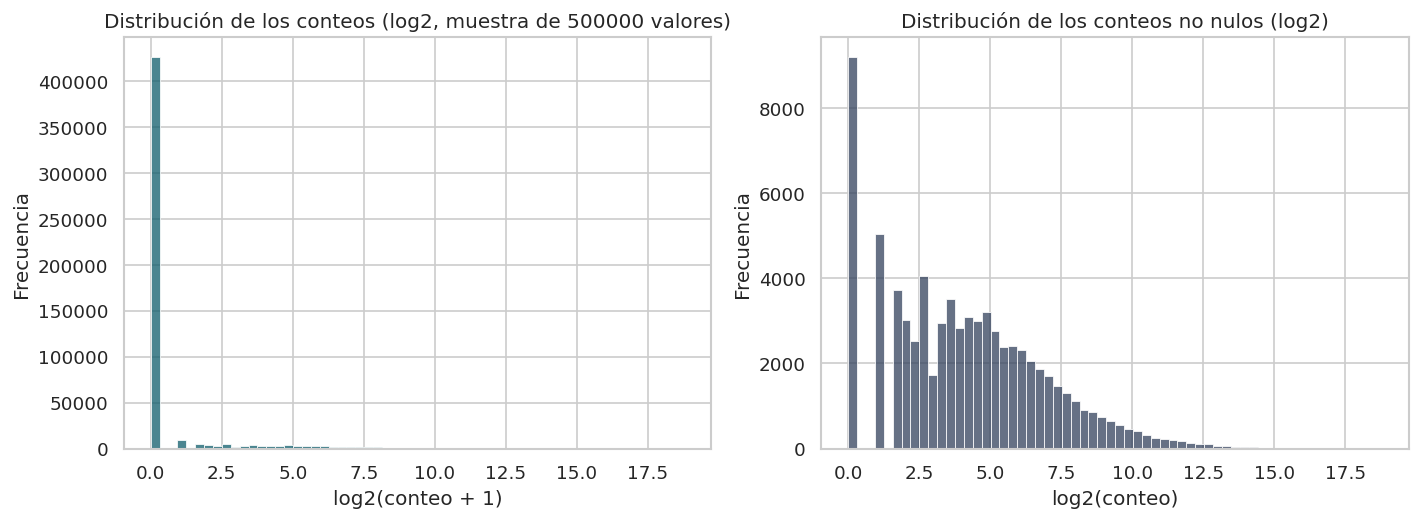

In [ ]:
rng = np.random.default_rng(semilla)

# La matriz contiene más de 16 millones de valores (celdas), así que se toma una muestra aleatoria de 500.000 para representar el histograma
valores = expr.to_numpy().ravel()
muestra_val = rng.choice(valores, size=500_000, replace=False)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

# Los valores se representan en escala logarítmica en base 2 porque los conteos de RNA-seq abarcan un rango muy amplio, con muchísimas celdas nulas o de valor bajo y unos pocos genes que acumulan cantidades enormes de lecturas.
# Sin transformar, casi todos los datos quedarían comprimidos junto al eje y el gráfico no mostraría nada.
# Se usa base 2 y no base 10, ya que cada unidad de esa escala corresponde a duplicar la expresión, lo que permite leer las diferencias directamente como cambios de magnitud.
# La suma de una unidad previa a la transformación evita que los valores nulos, para los que el logaritmo no está definido, queden fuera de la representación.
sns.histplot(np.log2(muestra_val + 1), bins=60, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Distribución de los conteos (log2, muestra de 500000 valores)")
ejes[0].set_xlabel("log2(conteo + 1)"); ejes[0].set_ylabel("Frecuencia")

no_nulos = muestra_val[muestra_val > 0]
sns.histplot(np.log2(no_nulos), bins=60, color=azul_oscuro, ax=ejes[1])
ejes[1].set_title("Distribución de los conteos no nulos (log2)")
ejes[1].set_xlabel("log2(conteo)"); ejes[1].set_ylabel("Frecuencia")

plt.tight_layout(); plt.show()

Las dos gráficas muestran la distribución de los valores de expresión en escala logarítmica en base 2. En la primera se representan todos los valores de la matriz, sumando una unidad antes de transformar para poder incluir los ceros. La barra situada en el extremo izquierdo corresponde justamente a esos ceros, que suponen el 85,21% de la matriz y dominan por completo la distribución. El resto de valores se reparte en una curva que desciende de forma continua a medida que aumenta la expresión.

La segunda gráfica excluye los ceros para poder observar los valores realmente detectados. La distribución sigue siendo claramente asimétrica hacia la derecha, ocurriendo que la mayor parte de los genes presenta conteos bajos y solo una minoría alcanza valores muy altos. El hecho de que esta asimetría se mantenga tras eliminar los ceros indica que no la provocan las ausencias de expresión, sino la propia naturaleza de los datos de secuenciación, en los que unos pocos genes muy activos concentran una gran parte de las lecturas.

Ambas gráficas condicionan el análisis dado que la gran cantidad de ceros justifica el filtrado de los genes que apenas se detectan, ya que no aportan información y solo añaden dimensionalidad. La asimetría, por su parte, justifica la transformación logarítmica, que comprime el rango de valores y evita que los genes más expresados dominen el entrenamiento de los modelos.

Comprobada la distribución de los valores de expresión, es necesario examinar la escala de los conteos desde dos puntos de vista.

- Por muestra, interesa saber cuántas lecturas totales se han obtenido en cada una, ya que ese volumen afecta directamente a la magnitud de sus valores.
- Por gen, interesa conocer en cuántas muestras se detecta expresión, lo que permite estimar qué proporción del transcriptoma aporta información real al análisis.

Lecturas por muestra -> mín 218,517 | mediana 2,015,926 | máx 7,273,295
Genes sin ninguna lectura en todas las muestras: 29,195
Genes con cero en más del 90% de las muestras: 44,291


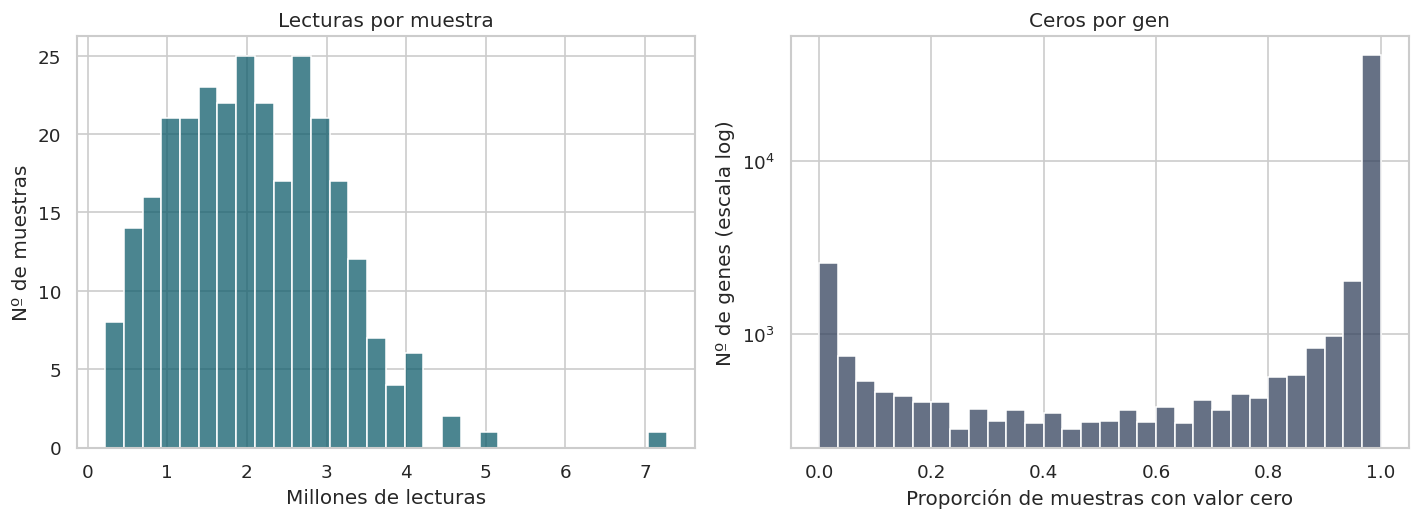

In [ ]:
tam_libreria = expr.sum(axis=0)             # lecturas por muestra
ceros_por_gen = (expr == 0).mean(axis=1)    # fracción de muestras con cero, por gen
genes_todo_cero = int((expr.sum(axis=1) == 0).sum())

print(f"Lecturas por muestra -> mín {tam_libreria.min():,.0f} | "
      f"mediana {tam_libreria.median():,.0f} | máx {tam_libreria.max():,.0f}")
print(f"Genes sin ninguna lectura en todas las muestras: {genes_todo_cero:,}")
print(f"Genes con cero en más del 90% de las muestras: {(ceros_por_gen > 0.9).sum():,}")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(tam_libreria / 1e6, bins=30, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Lecturas por muestra")
ejes[0].set_xlabel("Millones de lecturas"); ejes[0].set_ylabel("Nº de muestras")

sns.histplot(ceros_por_gen, bins=30, color=azul_oscuro, ax=ejes[1])
ejes[1].set_yscale("log")
ejes[1].set_title("Ceros por gen")
ejes[1].set_xlabel("Proporción de muestras con valor cero")
ejes[1].set_ylabel("Nº de genes (escala log)")

plt.tight_layout(); plt.show()

In [ ]:
tramos = {
    "Presentes en todas las muestras (0% de ceros)": (ceros_por_gen == 0).sum(),
    "Ceros en menos del 10% de las muestras":        (ceros_por_gen < 0.1).sum(),
    "Zona intermedia (entre 10% y 90%)":            ((ceros_por_gen >= 0.1) & (ceros_por_gen <= 0.9)).sum(),
    "Ceros en más del 90%":                          (ceros_por_gen > 0.9).sum(),
    "Ceros en el 100% de las muestras":              (ceros_por_gen == 1).sum(),
}
for k, v in tramos.items():
    print(f"{k}: {v:,}")

Presentes en todas las muestras (0% de ceros): 959
Ceros en menos del 10% de las muestras: 3,851
Zona intermedia (entre 10% y 90%): 9,594
Ceros en más del 90%: 44,291
Ceros en el 100% de las muestras: 29,195


La profundidad de secuenciación varía de forma considerable entre muestras. La mediana se sitúa en algo más de 2 millones de lecturas, pero el rango va desde las 218517 hasta los 7273295, más de 30 veces de diferencia. Sin embargo, los conteos en bruto no son comparables entre muestras, ya que un valor elevado puede reflejar tanto una expresión alta como una secuenciación más profunda. Por tanto, para poder comparar los números correctamente, es necesario transformar los datos a conteos por millón antes del modelado.

La segunda gráfica sitúa cada gen según la proporción de muestras en las que su valor es cero. Un gen que nunca se detecta se sitúa en el extremo derecho, en 1,0, mientras que uno presente en todas las muestras aparece en el extremo izquierdo, en 0,0. La altura de cada barra indica cuántos genes caen en ese tramo, y el eje vertical se representa en escala logarítmica porque sino, la barra del extremo derecho ocultaría por completo al resto.

El grupo más numeroso se acumula en el extremo derecho, donde, un total de 29195 genes carecen de lecturas en las 285 muestras, y al ampliar el tramo a los que están a cero en más del 90% de las muestras, la cifra alcanza los 44291 genes, es decir, más o menos tres cuartas partes del total. En el extremo opuesto se sitúan 3851 genes que se detectan en más del 90% de las muestras, de los cuales 959 están presentes en todas ellas sin excepción. Entre ambos extremos queda una zona intermedia de 9594 genes, cuya presencia varía de unas muestras a otras.

Este reparto condiciona la dimensionalidad del problema, dado que la mayor parte de las 57736 variables no contiene información aprovechable para distinguir entre clases y solo aumenta el desajuste entre el número de variables y el de muestras.

La escala logarítmica del gráfico reduce visualmente la importancia de los grupos menos numerosos: la zona intermedia parece inexistente, pero contiene casi 10 mil genes. Su existencia implica que el corte entre lo que se expresa y lo que no resulta gradual, sin una frontera clara, de modo que el umbral de filtrado es una decisión que debe justificarse de forma explícita y no un valor que los datos determinen por sí solos.

Una vez estudiados los valores de expresión, queda por mirar la variable objetivo.

El reparto de las muestras entre clases determina si los modelos tenderán a favorecer a las categorías más frecuentes y, condiciona tanto las métricas de evaluación como las estrategias correctoras que deben aplicarse.

Se analiza en la tarea binaria, que separa a las personas sin cáncer de las que lo padecen, y en la multiclase, que distingue el tipo de tumor.

Distribución multiclase:
tipo_tumor
Lung             60
Sano             55
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14
Name: count, dtype: int64 

Distribución binaria:
tipo_tumor
Cáncer    230
Sano       55
Name: count, dtype: int64 

Razón de desbalance multiclase: 4.3 a 1
Razón de desbalance binaria:    4.2 a 1


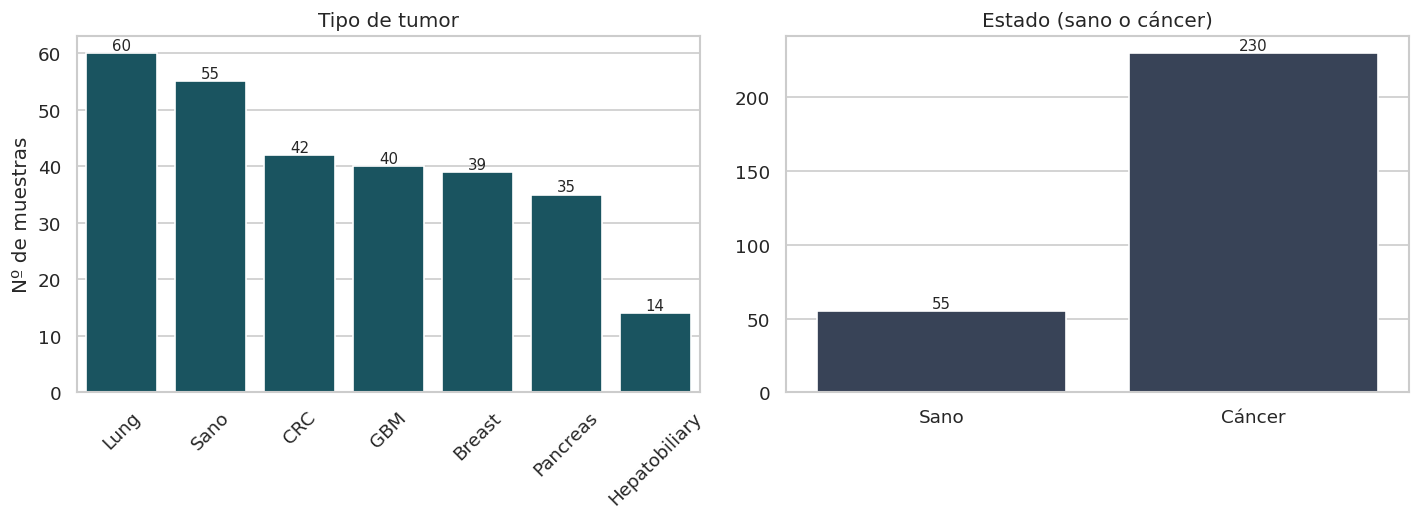

In [ ]:
etiqueta_binaria = etiquetas.apply(lambda x: "Sano" if x == "Sano" else "Cáncer")

print("Distribución multiclase:")
print(etiquetas.value_counts(), "\n")
print("Distribución binaria:")
print(etiqueta_binaria.value_counts(), "\n")

# Razón entre la clase más frecuente y la menos frecuente
conteo = etiquetas.value_counts()
print(f"Razón de desbalance multiclase: {conteo.max() / conteo.min():.1f} a 1")
conteo_bin = etiqueta_binaria.value_counts()
print(f"Razón de desbalance binaria:    {conteo_bin.max() / conteo_bin.min():.1f} a 1")

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x=etiquetas, order=conteo.index, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Tipo de tumor")
ejes[0].set_xlabel(""); ejes[0].set_ylabel("Nº de muestras")
ejes[0].tick_params(axis="x", rotation=45)

sns.countplot(x=etiqueta_binaria, order=["Sano", "Cáncer"], color=azul_oscuro, ax=ejes[1])
ejes[1].set_title("Estado (sano o cáncer)")
ejes[1].set_xlabel(""); ejes[1].set_ylabel("")

for eje in ejes:
    for barra in eje.patches:
        eje.annotate(int(barra.get_height()),
                     (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout(); plt.show()

Ambas tareas presentan un desbalance considerable y de magnitud parecida. En la tarea binaria, las 230 muestras de pacientes con cáncer cuadruplican a las 55 de individuos sanos. En la multiclase, el tipo más representado es el cáncer de pulmón, con 60 muestras, mientras que el hepatobiliar apenas tiene 14, lo que supone una razón de algo más de cuatro a uno entre la clase mayoritaria y la minoritaria.

Esta situación tiene dos consecuencias para el resto del trabajo.
- La primera afecta a la evaluación, ya que la exactitud global resultaría engañosa. Un modelo que clasificase todas las muestras como cáncer alcanzaría un 80% de aciertos sin haber aprendido nada útil, por lo que la comparación se debe apoyar en métricas que ponderan por igual a todas las clases.
- La segunda afecta al entrenamiento, porque los algoritmos tienden a favorecer a las categorías más frecuentes sin importar las minoritarias. Como no existe una estrategia correctora que funcione mejor en todos los casos, y las muestras sintéticas pueden introducir ruido en datos de alta dimensión, se compararán tres alternativas: no aplicar ninguna corrección, ponderar las clases durante el entrenamiento y generar muestras sintéticas mediante SMOTE.

La clase hepatobiliar necesita atención individual, ya que al tener solo 14 muestras, cualquier partición de los datos dejará muy pocos casos disponibles para su evaluación, por lo que las métricas correspondientes a esta categoría estarán sujetas a una variabilidad considerable y deberán analizarse con cuidado.

Antes de pasar a la siguiente fase, es necesario estudiar la existencia de réplicas.

El conjunto incluye al menos una muestra repetida, es decir, un mismo paciente secuenciado en dos ocasiones. Es necesario identificarla porque, si ambas quedasen repartidas entre entrenamiento y prueba, el modelo se evaluaría con información procedente de un individuo ya visto durante el aprendizaje.

In [ ]:
replicas = [c for c in expr.columns if c.endswith("-1") and c[:-2] in expr.columns]
n_individuos = expr.shape[1] - len(replicas)

print("Columnas cuyo nombre acaba en -1:",
      len([c for c in expr.columns if c.endswith("-1")]))
print("De ellas, con la muestra base también presente:", len(replicas))
print("Réplica identificada:", replicas)
print(f"\nMuestras: {expr.shape[1]} | Individuos distintos: {n_individuos}")

Columnas cuyo nombre acaba en -1: 28
De ellas, con la muestra base también presente: 1
Réplica identificada: ['Lung-0020J-1']

Muestras: 285 | Individuos distintos: 284


El criterio se centra en los nombres del depósito de datos, que añade el sufijo -1 al identificador de la muestra repetida, y en la condición adicional de que exista la muestra base correspondiente. Esa segunda condición es la que resulta determinante, ya que en la mayoría de los casos el sufijo forma parte del identificador sin significar repetición, como ocurre en HD-2-1, para la que no existe ninguna muestra HD-2.

Un criterio basado en nombres depende, sin embargo, de la consistencia de quien depositó los datos, por lo que es necesario verificar la réplica a partir de los propios valores de expresión.

In [ ]:
for col in ["Lung-0020J", "Lung-0020J-1"]:
    print(f"{col:15s} lecturas: {expr[col].sum():>12,.0f} | "
          f"ceros: {(expr[col] == 0).mean():.1%} | "
          f"genes detectados: {(expr[col] > 0).sum():,}")

Lung-0020J      lecturas:    5,054,795 | ceros: 82.4% | genes detectados: 10,170
Lung-0020J-1    lecturas:      592,866 | ceros: 87.3% | genes detectados: 7,344


Ambas muestras se diferencian en profundidad de secuenciación, con más de ocho veces de diferencia entre una y otra. La 'muestra repetición' (Lung-0020J-1) se sitúa además entre las muestras con menor número de lecturas de todo el conjunto, lo que condiciona cualquier comparación entre sus perfiles, ya que gran parte de los genes ausentes en la segunda no refleja una diferencia biológica, sino la falta de lecturas suficientes para detectarlos.

Por este motivo, la comparación se plantea partiendo de la muestra de menor profundidad, que es la que pone el límite, y se realiza sobre los genes con expresión detectable y en escala logarítmica, entendiendo por ellos los que alcanzan al menos una lectura por millón en catorce muestras o más.

Un cálculo previo sobre la matriz completa resultó poco concluyente, ya que los más de 40 mil genes con valor nulo en casi todas las muestras introducen ruido, el cual distorsiona el resultado.

In [ ]:
# Filtrado y transformación provisionales solo para esta comprobación
cpm_tmp = expr / expr.sum(axis=0) * 1e6
genes_tmp = (cpm_tmp >= 1).sum(axis=1) >= 14
log_cpm = np.log2(cpm_tmp.loc[genes_tmp] + 1)

print(f"Genes con expresión detectable empleados en la comparación: " f"{genes_tmp.sum():,} de {expr.shape[0]:,}\n")

corr_filt = log_cpm.corr(method="pearson")
np.fill_diagonal(corr_filt.values, np.nan)

print("Correlación de la pareja:", f"{corr_filt.loc['Lung-0020J', 'Lung-0020J-1']:.3f}\n")
print("Cinco muestras más parecidas a Lung-0020J-1:")
print(corr_filt["Lung-0020J-1"].sort_values(ascending=False).head(5).to_string())

Genes con expresión detectable empleados en la comparación: 13,343 de 57,736

Correlación de la pareja: 0.927

Cinco muestras más parecidas a Lung-0020J-1:
Lung-0020J    0.927441
Lung-0040     0.891227
CRC-450       0.880331
Lung-0096     0.877633
Lung-0025J    0.873640


La muestra Lung-0020J es la más parecida a Lung-0020J-1, con una correlación de 0,927 frente al 0,891 de la siguiente muestra candidata, una diferencia que la separa con claridad del resto del conjunto. Las demás muestras próximas corresponden además, en su mayoría, a pacientes con cáncer de pulmón, lo que indica que el cálculo refleja estructura biológica y no ruido técnico.

Lo último que falta por comprobar para poder decir si son el mismo paciente es que los metadatos coincidan.


In [ ]:
filas = metadatos["titulo"].isin(["Blood_Platelets_Lung-20", "Blood_Platelets_Lung-20-1"])
print(pd.concat([metadatos.loc[filas, ["titulo", "gsm"]],
                 caract_df.loc[filas]], axis=1).T.to_string())

                                      189                        190
titulo            Blood_Platelets_Lung-20  Blood_Platelets_Lung-20-1
gsm                            GSM1662723                 GSM1662724
caracteristica_0            tissue: blood              tissue: blood
caracteristica_1  cell type: Thrombocytes    cell type: Thrombocytes
caracteristica_2      patient id: Lung-20      patient id: Lung-20-1
caracteristica_3        cancer type: Lung          cancer type: Lung
caracteristica_4           batch: Batch02             batch: Batch02
caracteristica_5  mutational subclass: wt    mutational subclass: wt


Los metadatos respaldan la conclusión. Ambas muestras comparten tejido, tipo celular, tipo tumoral, subclase mutacional y lote de procesamiento, y sus identificadores en el repositorio son consecutivos. El campo de identificación del paciente las registra con valores distintos, de modo que el depósito no declara de forma explícita que correspondan al mismo individuo, aunque los nombres utilizados y la coincidencia del resto de características apuntan en esa dirección.

Por ello, lo más probable es que las 285 muestras del conjunto correspondan a 284 individuos distintos.

Una vez que se han encontrado las coincidencias entre las muestras, y para llevar a cabo el resto del análisis, se elimina una de las dos muestras para que ningún individuo aparezca repetido. Las dos secuenciaciones se diferencian mucho en calidad: Lung-0020J posee unos 5,05 millones de lecturas, con un 82,4% de ceros y 10170 genes detectados, mientras que Lung-0020J-1 apenas alcanza 0,59 millones de lecturas, con un 87,3% de ceros y 7344 genes detectados. Por tanto, se elimina esta última, con menor profundidad y peor calidad, obteniendo un conjunto de 284 muestras correspondientes a 284 individuos. Esta decisión evita que las dos mitades de un probable mismo paciente puedan separarse entre entrenamiento y validación durante la validación cruzada.

*Nota:* Mientras no exista una confirmación externa del identificador del paciente, se debe hablar de una posible réplica técnica.

In [ ]:
# Se elimina la muestra de menor profundidad de la posible réplica técnica
pareja = ["Lung-0020J", "Lung-0020J-1"]
resumen = pd.DataFrame({
    "lecturas": expr[pareja].sum(axis=0),
    "ceros_%": (expr[pareja] == 0).mean(axis=0) * 100,
    "genes_detectados": (expr[pareja] > 0).sum(axis=0),
})
print("Calidad de las dos secuenciaciones:")
print(resumen.round(1).to_string())

muestra_a_eliminar = resumen["lecturas"].idxmin()
print(f"\nSe elimina la de menor profundidad: {muestra_a_eliminar}")

expr = expr.drop(columns=[muestra_a_eliminar])
etiquetas = etiquetas.drop(index=muestra_a_eliminar)
correspondencia = correspondencia[correspondencia["columna_expr"] != muestra_a_eliminar]

print(f"\nMuestras tras eliminar la réplica: {expr.shape[1]}")
print("Cada muestra corresponde ya a un individuo distinto.")

Calidad de las dos secuenciaciones:
              lecturas  ceros_%  genes_detectados
Lung-0020J     5054795     82.4             10170
Lung-0020J-1    592866     87.3              7344

Se elimina la de menor profundidad: Lung-0020J-1

Muestras tras eliminar la réplica: 284
Cada muestra corresponde ya a un individuo distinto.


## **Fase 2: preparación de los datos**

Objetivo del bloque: convertir la matriz en bruto en un conjunto listo para el modelado, cuidando en cada paso que no se filtre información del conjunto de evaluación. Para ello, se necesitan los siguientes pasos: filtrado de genes poco expresados, reorganización a formato de modelo (transposición de la matriz y separación de variables y objetivo), partición entre entrenamiento y prueba, normalización y estandarización, control de calidad de las muestras y preparación de las estrategias frente al desbalance.

*Nota:* todo cálculo que dependa de los datos, se ajustará únicamente con el conjunto de entrenamiento y se aplicará después al de prueba. Esto incluye el filtrado de genes, que no se realiza aquí sobre la matriz completa, sino que se integra en el flujo de modelado y se recalcula en cada pliegue de la validación cruzada, de modo que las muestras de prueba no intervienen en la elección de los genes.

En esta fase, el filtrado solo se calcula de forma orientativa, para describir cuántos genes superan el criterio y comprobar que ninguna clase queda infrarrepresentada.

### **Filtrado de genes poco expresados**

El análisis exploratorio ha mostrado que la mayor parte de los genes apenas se detecta (44291 de los 57736 presentan valor cero en más del 90% de las muestras). Mantenerlos no aporta capacidad a los modelos, empeora el desajuste entre variables y muestras, y encarece todos los pasos posteriores.

El umbral debe fijarse de forma explícita, ya que la zona intermedia de la distribución impide un corte evidente. Por tanto, el criterio elegido para mantener un gen exigirá el cumplimiento de dos condiciones: que alcance al menos una lectura por millón, y que lo haga en un mínimo de 14 muestras. De esta forma, se descartan tanto los genes que alcanzan valores altos en muy pocas muestras como aquellos que, a pesar de aparecer con frecuencia, lo hacen siempre con niveles mínimos.

El hecho de elegir 14 muestras corresponde al tamaño del grupo menos representado, el hepatobiliar. Se escoge ese valor ya que un gen característico de un único tipo tumoral se expresaría únicamente en las muestras de ese grupo y en ninguna otra, y un umbral mayor lo eliminaría precisamente por ser específico, cuando se trata del tipo de gen que interesa conservar. Por debajo de esa cifra, en cambio, no existe ningún grupo que justifique la presencia del gen, por lo que su aparición se puede asociar al ruido técnico del proceso de secuenciación.

Además, el hecho de comparar en lecturas por millón y no en conteos brutos es que estos últimos dependen de la profundidad de secuenciación. Es decir, una muestra con 7 millones de lecturas presenta valores más elevados en todos sus genes que otra con 200 mil, sin que ello implique mayor expresión. Por esto, al expresar el umbral en proporción al total de cada muestra, la exigencia acaba siendo equivalente para todas.

In [ ]:
# El filtro no se aplica a la matriz completa. Se calcula aquí solo como diagnóstico, para informar de cuántos genes lo superan y comprobar que ninguna clase queda infrarrepresentada.
# El filtrado real se realiza dentro del flujo de modelado, y se recalcula en cada pliegue de la validación cruzada, de modo que las muestras de prueba no intervienen en la elección.
cpm = expr / expr.sum(axis=0) * 1e6

umbral_cpm = 1
min_muestras = 14   # tamaño del grupo tumoral más pequeño del estudio, fijado a priori

genes_diagnostico = (cpm >= umbral_cpm).sum(axis=1) >= min_muestras

print(f"Criterio orientativo: al menos {umbral_cpm} CPM en {min_muestras} muestras o más\n")
print(f"Genes totales:                 {expr.shape[0]:,}")
print(f"Genes que superan el criterio: {int(genes_diagnostico.sum()):,} "
      f"({genes_diagnostico.mean():.1%})")

Criterio orientativo: al menos 1 CPM en 14 muestras o más

Genes totales:                 57,736
Genes que superan el criterio: 13,331 (23.1%)


El criterio orientativo conserva 13331 genes de los 57736 iniciales (23,1%).

Este recuento es solo informativo. La matriz conserva por ahora todos los genes, y el filtrado se aplica más adelante dentro del flujo de modelado, donde se recalcula en cada pliegue de la validación cruzada para que las muestras de prueba no influyan en qué genes se conservan. Al calcularse únicamente sobre las muestras de entrenamiento, el número de genes que superan el criterio dentro del flujo es algo menor que estos 13331, como se muestra en la fase siguiente.

Se debe comprobar si alguna clase ha quedado infrarrepresentada tras esta eliminación orientativa de genes.

In [ ]:
cpm_filtrada = cpm.loc[genes_diagnostico]
print("Genes detectados (CPM >= 1) por clase, mediana entre sus muestras:\n")
for clase in etiquetas.value_counts().index:
    columnas = etiquetas[etiquetas == clase].index
    detectados = (cpm_filtrada[columnas] >= umbral_cpm).sum(axis=0)
    print(f"  {clase:15s} {detectados.median():>7,.0f}")


Genes detectados (CPM >= 1) por clase, mediana entre sus muestras:

  Lung              6,653
  Sano              8,923
  CRC               6,764
  GBM               7,134
  Breast            7,176
  Pancreas          7,154
  Hepatobiliary     7,782


La comprobación por clases descarta que el criterio de selección de genes haya perjudicado a alguna categoría en particular. La mediana de genes detectados se sitúa entre 6653 y 8923 según el grupo, valores del mismo orden en todos los casos.

Se aprecia que el grupo hepatobiliar no queda desfavorecido, con 7782 genes detectados.

El grupo con mayor cantidad de genes detectados es el de los Sanos, ¿puede eso tener que ver con el número de lecturas por muestra?


In [ ]:
print("Mediana de lecturas por muestra, según clase:\n")
for clase in etiquetas.value_counts().index:
    columnas = etiquetas[etiquetas == clase].index
    print(f"  {clase:15s} {expr[columnas].sum(axis=0).median():>12,.0f}")

Mediana de lecturas por muestra, según clase:

  Lung               2,071,482
  Sano               1,037,596
  CRC                2,329,392
  GBM                1,725,766
  Breast             2,394,606
  Pancreas           2,289,569
  Hepatobiliary      1,909,101



Se observa que las muestras de individuos sanos son las que menos lecturas acumulan por muestra, con una mediana de 1037596 frente a los más de 2 millones de algunos grupos tumorales, y sin embargo son las que mayor número de genes detectan.

La diferencia no puede asociarse, por tanto, a una secuenciación más profunda, sino que sugiere un perfil de expresión más repartido entre genes distintos, mientras que en las muestras tumorales una proporción mayor de las lecturas se concentra en un conjunto más reducido. Esto se trata de una observación exploratoria que no forma parte de los objetivos del trabajo y que es coherente con el fenómeno de educación plaquetaria tratado en la literatura del trabajo, según el cual la presencia del tumor altera el perfil transcripcional de la plaqueta.

### **Transposición y separación de variables y objetivo**

Los algoritmos de clasificación esperan que cada fila represente una observación y cada columna una variable. Como la matriz de expresión sigue la dinámica contraria, debe transponerse.

A esa matriz de variables se asocian dos variables objetivo distintas, correspondientes a las dos tareas planteadas. La primera es binaria y separa a los individuos sin cáncer de aquellos que lo padecen. La segunda es multiclase y distingue entre los seis tipos tumorales presentes en el conjunto; en esta segunda tarea las muestras de individuos sanos quedan excluidas, ya que el objetivo es diferenciar el origen del tumor en pacientes que ya han sido identificados como enfermos.

In [ ]:
# Se transpone la matriz
X = expr.T
X.index.name = "muestra"

# Tarea binaria: sano frente a cáncer (las 284 muestras)
y_binaria = etiquetas.apply(lambda x: "Sano" if x == "Sano" else "Cáncer")

# Tarea multiclase: tipo de tumor (solo las muestras de cáncer)
muestras_cancer = etiquetas[etiquetas != "Sano"].index
X_multiclase = X.loc[muestras_cancer]
y_multiclase = etiquetas.loc[muestras_cancer]

print(f"Matriz de variables (X): {X.shape[0]} muestras × {X.shape[1]:,} genes\n")

print("Tarea binaria:")
print(f"  X: {X.shape}")
print(y_binaria.value_counts().to_string(), "\n")

print("Tarea multiclase:")
print(f"  X: {X_multiclase.shape}")
print(y_multiclase.value_counts().to_string())

Matriz de variables (X): 284 muestras × 57,736 genes

Tarea binaria:
  X: (284, 57736)
tipo_tumor
Cáncer    229
Sano       55 

Tarea multiclase:
  X: (229, 57736)
tipo_tumor
Lung             59
CRC              42
GBM              40
Breast           39
Pancreas         35
Hepatobiliary    14


In [ ]:
print("Índices alineados (binaria):   ", X.index.equals(y_binaria.index))
print("Índices alineados (multiclase):", X_multiclase.index.equals(y_multiclase.index))
print("Valores faltantes en X:        ", int(X.isna().sum().sum()))
print("\nPrimeras filas y columnas de X:")
print(X.iloc[:3, :4])

Índices alineados (binaria):    True
Índices alineados (multiclase): True
Valores faltantes en X:         0

Primeras filas y columnas de X:
                     ENSG00000000003  ENSG00000000005  ENSG00000000419  \
muestra                                                                  
3-Breast-Her2-ampl                 0                0               44   
8-Breast-WT                        0                0               14   
10-Breast-Her2-ampl                0                0               16   

                     ENSG00000000457  
muestra                               
3-Breast-Her2-ampl                26  
8-Breast-WT                        1  
10-Breast-Her2-ampl               14  


La matriz queda organizada en 284 filas, una por muestra, y 57736 columnas, una por gen.

La tarea binaria conserva las 284 muestras, con 229 casos de cáncer frente a 55 controles sanos, mientras que la multiclase trabaja solo con las 229 muestras tumorales: 59 de pulmón, 42 colorrectales, 40 glioblastomas, 39 de mama, 35 de páncreas y 14 hepatobiliares.

La ejecución de la segunda celda de código sirve para ver que los índices de la matriz de variables y de las etiquetas coinciden en ambas tareas y no hay valores ausentes.

### **Partición entre entrenamiento y prueba**

La comparación final entre modelos debe realizarse sobre datos que no hayan participado en el entrenamiento ni en el ajuste de hiperparámetros. Se reserva para ello un 20% de las muestras, proporción que deja suficientes casos para entrenar, dado lo reducido que es el conjunto de datos, y conserva un grupo de evaluación con un mínimo de representatividad. En la tarea multiclase esa cifra supone apenas tres muestras del grupo hepatobiliar, límite que se tiene que tener en cuenta al interpretar sus métricas.

La partición se estratifica por clase para que ninguna quede infrarrepresentada por azar.

In [ ]:
# Para la tarea binaria
from sklearn.model_selection import train_test_split

X_ent_bin, X_pru_bin, y_ent_bin, y_pru_bin = train_test_split(
    X, y_binaria, test_size=0.20, stratify=y_binaria, random_state=semilla)

print("Tarea binaria")
print(f"  Entrenamiento: {X_ent_bin.shape[0]} muestras")
print(y_ent_bin.value_counts().to_string())
print(f"\n  Prueba: {X_pru_bin.shape[0]} muestras")
print(y_pru_bin.value_counts().to_string())

Tarea binaria
  Entrenamiento: 227 muestras
tipo_tumor
Cáncer    183
Sano       44

  Prueba: 57 muestras
tipo_tumor
Cáncer    46
Sano      11


In [ ]:
# Para la tarea multiclase
X_ent_multi, X_pru_multi, y_ent_multi, y_pru_multi = train_test_split(
    X_multiclase, y_multiclase, test_size=0.20, stratify=y_multiclase,
    random_state=semilla)

print("Tarea multiclase")
print(f"  Entrenamiento: {X_ent_multi.shape[0]} muestras")
print(y_ent_multi.value_counts().to_string())
print(f"\n  Prueba: {X_pru_multi.shape[0]} muestras")
print(y_pru_multi.value_counts().to_string())

Tarea multiclase
  Entrenamiento: 183 muestras
tipo_tumor
Lung             47
CRC              34
GBM              32
Breast           31
Pancreas         28
Hepatobiliary    11

  Prueba: 46 muestras
tipo_tumor
Lung             12
CRC               8
GBM               8
Breast            8
Pancreas          7
Hepatobiliary     3


Se debe terminar comprobando que ninguna muestra ha quedado tanto en el entrenamiento como en el conjunto de prueba.

In [ ]:
for nombre, ent, pru in [("binaria", X_ent_bin, X_pru_bin),
                         ("multiclase", X_ent_multi, X_pru_multi)]:
    solapamiento = set(ent.index) & set(pru.index)
    print(f"{nombre:12s} muestras compartidas entre conjuntos: {len(solapamiento)}")

binaria      muestras compartidas entre conjuntos: 0
multiclase   muestras compartidas entre conjuntos: 0


La partición guarda 57 muestras para la evaluación de la tarea binaria y 46 para la multiclase, manteniendo en ambos conjuntos proporciones equivalentes a las del conjunto completo.

El reparto realizado es aleatorio, aunque sujeto a la condición de que cada clase conserve su proporción. Sin esa restricción, el azar podría dejar las categorías más pequeñas con poca representación o incluso ausentes del conjunto de evaluación, algo probable con solo 14 muestras hepatobiliares.

Sin embargo, este diseño tiene una limitación que es importante conocer. La comparación final se apoya en una única partición, de forma que los resultados dependen en cierta medida del reparto concreto obtenido. El caso más delicado es el del grupo hepatobiliar, que solo tiene tres muestras en el conjunto de prueba multiclase, por lo que un solo acierto o error modifica su sensibilidad en un tercio. Así, para valorar hasta qué punto las conclusiones dependen del reparto, la evaluación final se repetirá con varias semillas distintas, informando de la media y la dispersión de las métricas obtenidas. Por su parte, la selección de modelos se apoyará en la validación cruzada realizada sobre el conjunto de entrenamiento, donde cada muestra participará en varias evaluaciones.

### **Normalización y estandarización**

Como ya se ha dicho en los apartados anteriores, los conteos en bruto no son comparables entre muestras dado que la profundidad de secuenciación varía en más de 30 veces entre la muestra con menos lecturas y la que más tiene.

La técnica de corrección más habitual consiste en expresar cada valor en lecturas por millón, dividiendo por el total de la muestra. A esa escala se aplica después una transformación logarítmica, que comprime el rango de valores y disminuye el peso de los genes muy expresados, cuya distribución resultaba fuertemente asimétrica. Se suma una unidad antes de transformar para que los ceros no queden indefinidos.

Las dos operaciones anteriores trabajan con cada muestra por separado, usando solo sus valores, así que pueden aplicarse igual al conjunto de entrenamiento y al de prueba sin que haya riesgo de fuga de información.

Con la estandarización pasa lo contrario. Centrar y escalar cada gen exige calcular su media y su desviación típica sobre un conjunto de muestras, de manera que el resultado depende de qué muestras formen parte de ese cálculo. Por eso ambos estadísticos se obtienen únicamente con los datos de entrenamiento y se aplican después, tal cual, a los de prueba. Hacerlo de otra manera contaminaría la evaluación con información que el modelo no debería conocer.

In [ ]:
def normalizar(matriz):
    cpm = matriz.div(matriz.sum(axis=1), axis=0) * 1e6
    return np.log2(cpm + 1)

X_ent_bin_norm = normalizar(X_ent_bin)
X_pru_bin_norm = normalizar(X_pru_bin)
X_ent_multi_norm = normalizar(X_ent_multi)
X_pru_multi_norm = normalizar(X_pru_multi)

print("Antes de normalizar (conteos brutos):")
print(f"  mínimo {X_ent_bin.to_numpy().min():,.0f} | "
      f"máximo {X_ent_bin.to_numpy().max():,.0f}")
print("\nDespués de normalizar (log2 de CPM + 1):")
print(f"  mínimo {X_ent_bin_norm.to_numpy().min():.2f} | "
      f"máximo {X_ent_bin_norm.to_numpy().max():.2f}")

# El total por muestra debe ser el mismo en todas tras pasar a CPM
totales_cpm = (X_ent_bin.div(X_ent_bin.sum(axis=1), axis=0) * 1e6).sum(axis=1)
print(f"\nTotal de CPM por muestra: mínimo {totales_cpm.min():,.0f} | "
      f"máximo {totales_cpm.max():,.0f}")

Antes de normalizar (conteos brutos):
  mínimo 0 | máximo 1,047,567

Después de normalizar (log2 de CPM + 1):
  mínimo 0.00 | máximo 18.22

Total de CPM por muestra: mínimo 1,000,000 | máximo 1,000,000


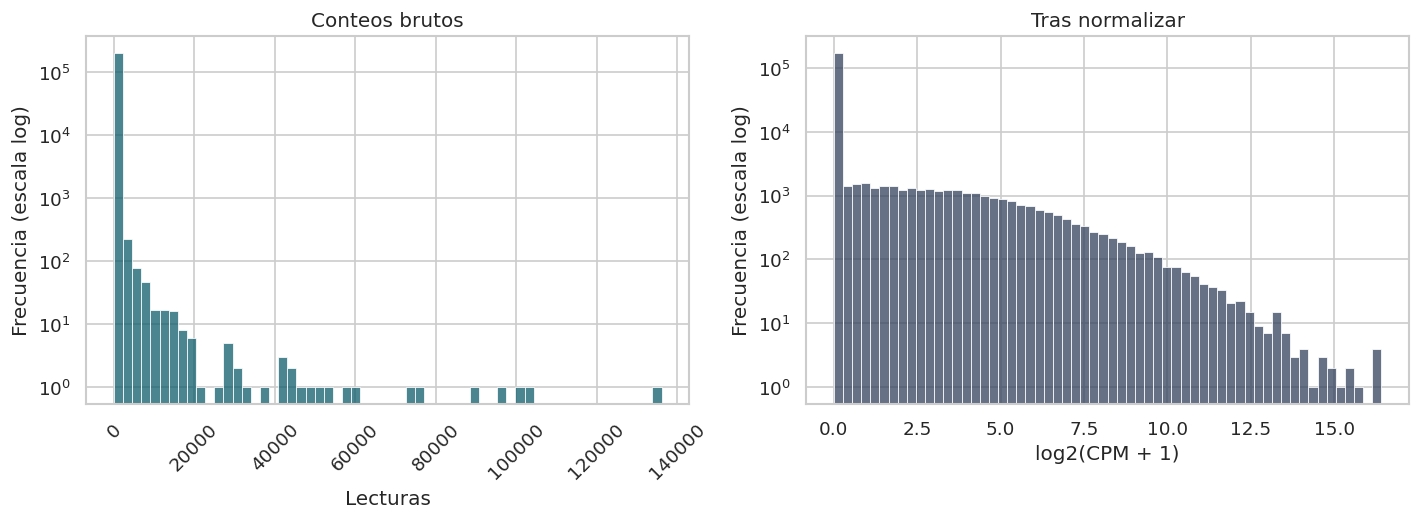

In [ ]:
rng = np.random.default_rng(semilla)
muestra_bruta = rng.choice(X_ent_bin.to_numpy().ravel(), size=200_000, replace=False)
muestra_norm = rng.choice(X_ent_bin_norm.to_numpy().ravel(), size=200_000, replace=False)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(muestra_bruta, bins=60, color=verde_azulado, ax=ejes[0])
ejes[0].set_yscale("log")
ejes[0].set_title("Conteos brutos")
ejes[0].set_xlabel("Lecturas"); ejes[0].set_ylabel("Frecuencia (escala log)")
ejes[0].tick_params(axis='x', rotation=45)

sns.histplot(muestra_norm, bins=60, color=azul_oscuro, ax=ejes[1])
ejes[1].set_yscale("log")
ejes[1].set_title("Tras normalizar")
ejes[1].set_xlabel("log2(CPM + 1)"); ejes[1].set_ylabel("Frecuencia (escala log)")

plt.tight_layout(); plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

def estandarizar(entrenamiento, prueba):
    escalador = StandardScaler()
    ent = pd.DataFrame(escalador.fit_transform(entrenamiento),
                       index=entrenamiento.index, columns=entrenamiento.columns)
    pru = pd.DataFrame(escalador.transform(prueba),
                       index=prueba.index, columns=prueba.columns)
    return ent, pru, escalador

X_ent_bin_esc, X_pru_bin_esc, escalador_bin = estandarizar(
    X_ent_bin_norm, X_pru_bin_norm)
X_ent_multi_esc, X_pru_multi_esc, escalador_multi = estandarizar(
    X_ent_multi_norm, X_pru_multi_norm)

print("Entrenamiento tras estandarizar:")
print(f"  media {X_ent_bin_esc.to_numpy().mean():.3f} | "
      f"desviación {X_ent_bin_esc.to_numpy().std():.3f}")
print("\nPrueba tras aplicar la misma escala:")
print(f"  media {X_pru_bin_esc.to_numpy().mean():.3f} | "
      f"desviación {X_pru_bin_esc.to_numpy().std():.3f}")

Entrenamiento tras estandarizar:
  media 0.000 | desviación 0.690

Prueba tras aplicar la misma escala:
  media 0.010 | desviación 0.789


La normalización deja todas las muestras con un total de 1 millón de lecturas, lo que las hace comparables entre sí independientemente de su profundidad de secuenciación original. Los valores, que en bruto llegaban hasta 1047567 lecturas en una sola celda, pasan a moverse en un rango de 0 a 18,22 en escala logarítmica.

El valor de ese máximo, 18,22, equivale a unas 305000 lecturas por millón, de manera que un único gen concentra cerca del 30% de todas las lecturas de esa muestra. Esto es común en el transcriptoma plaquetario, donde unos pocos genes muy abundantes acaparan gran parte de la señal (sin la transformación logarítmica, esos genes dominarían por completo cualquier cálculo de distancias o de coeficientes).

Las gráficas muestran el cambio conseguido, se aprecia que la distribución de conteos brutos se concentra por completo junto al cero, con una cola tan larga que solo resulta visible representando la frecuencia en escala logarítmica. Tras normalizar, y representando también la frecuencia en escala logarítmica, se aprecia el gran pico de los valores nulos junto a la cola descendente del resto de la señal, que se extiende de forma continua hasta valores en torno a 16-18. Sin la transformación logarítmica del eje, esta cola quedaría completamente aplastada por la barra de los ceros, que concentra alrededor del 85% de los valores.

La estandarización deja cada gen centrado en media cero. La desviación calculada sobre el conjunto de entrenamiento de genes no alcanza exactamente uno, ya que la matriz contiene muchos genes sin expresión detectable que resultan constantes en el entrenamiento y que el estandarizador deja en cero. Estos genes se descartan más adelante dentro del flujo de modelado, de manera que no intervienen en el entrenamiento de los modelos.

*Nota:* La normalización por CPM divide cada muestra por su número total de lecturas, corrigiendo las diferencias de profundidad de secuenciación pero no el sesgo composicional. Cuando unos pocos genes concentran una fracción muy alta de las lecturas, como ocurre aquí, donde el valor máximo normalizado equivale a cerca del 30% de la librería de una muestra, el reparto restante se comprime y la expresión del resto de genes queda subestimada. Métodos como TMM, implementado en edgeR, o los factores de tamaño de DESeq2 abordan ese problema estimando un factor de escala robusto a partir de los genes de comportamiento intermedio, en lugar de asumir que el total de lecturas es comparable entre muestras. En este trabajo se ha mantenido CPM con transformación logarítmica por ser el procedimiento utilizado en el estudio original y por su simplicidad de integración en el flujo de modelado, pero se debe reconocer que una normalización robusta al sesgo composicional podría modificar tanto la selección de genes como los coeficientes obtenidos, y su comparación queda planteada como línea de trabajo futura.

### **Control de calidad de las muestras**

En datos de expresión no tiene sentido buscar valores atípicos gen a gen, porque un valor muy alto suele reflejar actividad biológica real, no un error de medida, y la transformación logarítmica ya ha comprimido el rango. Lo que sí es recomendable detectar son muestras cuyo perfil se aparte del resto, ya que una secuenciación deficiente, un ARN degradado o un problema de procesamiento afectan a la muestra entera y no a valores sueltos.

La forma común de verlo es reducir cada muestra a unas pocas dimensiones mediante análisis de componentes principales (PCA) y observar su posición relativa. De esta forma se podrá comprobar si la principal fuente de variación responde a diferencias biológicas o a factores técnicos.

Este análisis se realiza solo sobre el conjunto de entrenamiento, para no obtener información del conjunto guardado para la evaluación.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10, random_state=semilla)
componentes = pca.fit_transform(X_ent_bin_esc)

varianza = pca.explained_variance_ratio_
print("Varianza explicada por componente:")
for i, v in enumerate(varianza[:5], start=1):
    print(f"  CP{i}: {v:.1%}")
print(f"\nAcumulada en 10 componentes: {varianza.sum():.2%}")

pca_df = pd.DataFrame(componentes[:, :2], index=X_ent_bin_esc.index,
                      columns=["CP1", "CP2"])
pca_df["clase"] = etiquetas.loc[pca_df.index]
pca_df["lecturas"] = X_ent_bin.sum(axis=1)

Varianza explicada por componente:
  CP1: 10.0%
  CP2: 3.0%
  CP3: 2.4%
  CP4: 1.7%
  CP5: 1.5%

Acumulada en 10 componentes: 24.50%


La primera componente recoge el 10% de la variación y la segunda el 3%, de forma que entre ambas explican menos de una quinta parte del total y las diez primeras no alcanzan el 25%. La variación está, por tanto, muy repartida, algo común cuando se trabaja con miles de genes que responden a factores diversos.

Al conservar la matriz completa de 57736 genes, en lugar de un subconjunto filtrado, esta dispersión es aún mayor que la que se obtendría sobre los genes con expresión detectable.

Estas cifras no bastan para descartar la presencia de efectos técnicos, por lo que es necesario examinar la posición de las muestras según su tipo de tumor y su profundidad de secuenciación.

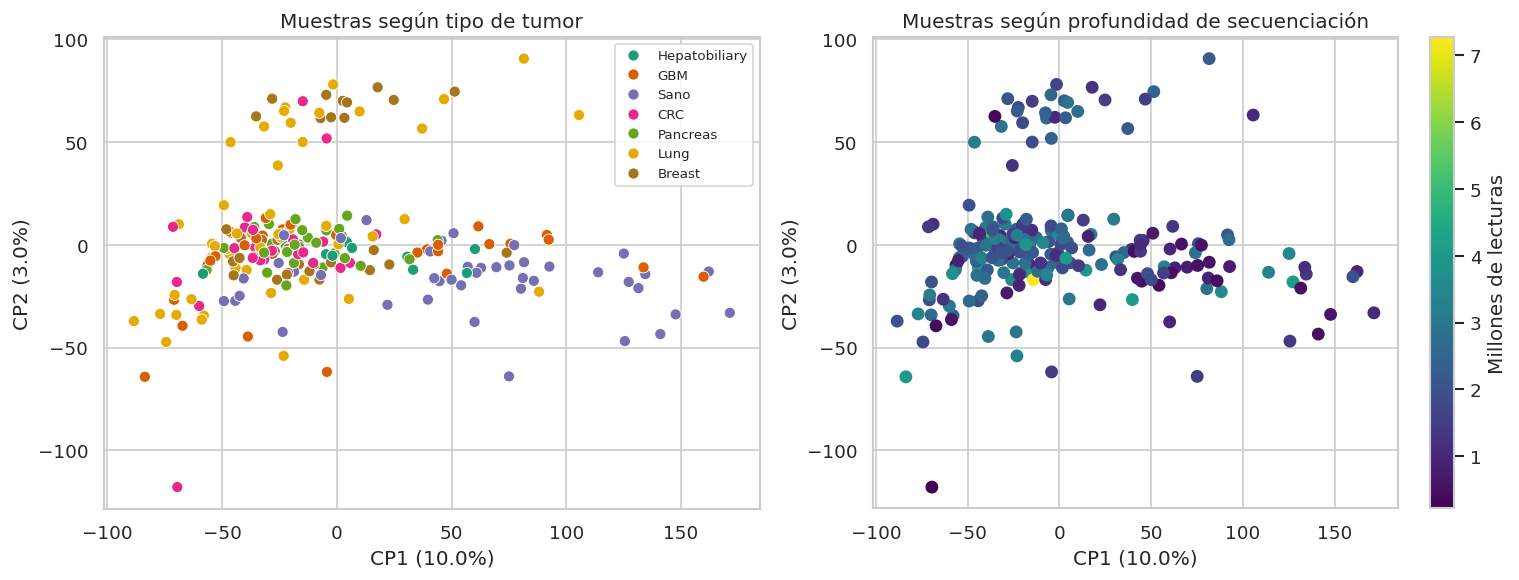

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=pca_df, x="CP1", y="CP2", hue="clase",
                palette="Dark2", s=45, ax=ejes[0])
ejes[0].set_title("Muestras según tipo de tumor")
ejes[0].set_xlabel(f"CP1 ({varianza[0]:.1%})")
ejes[0].set_ylabel(f"CP2 ({varianza[1]:.1%})")
ejes[0].legend(fontsize=8, title=None)

dispersion = ejes[1].scatter(pca_df["CP1"], pca_df["CP2"],
                             c=pca_df["lecturas"] / 1e6, cmap="viridis", s=45)
ejes[1].set_title("Muestras según profundidad de secuenciación")
ejes[1].set_xlabel(f"CP1 ({varianza[0]:.1%})")
ejes[1].set_ylabel(f"CP2 ({varianza[1]:.1%})")
plt.colorbar(dispersion, ax=ejes[1], label="Millones de lecturas")

plt.tight_layout(); plt.show()

La representación por profundidad enseña que muestras con menos de 1 millón de lecturas aparecen mezcladas con otras de más de 4 millones, lo que confirma que la normalización ha cumplido su función.

No obstante, en ambas gráficas aparece un grupo de muestras claramente separado en la parte superior, que no se explica por la profundidad ni corresponde a un único tipo de tumor. Es por esto que se necesita comprobar si esta separación está asociada al lote de procesamiento (es decir, aquellas registradas en la misma tanda del laboratorio).

In [ ]:
lote_meta = caract_df.apply(lambda f: extraer_campo(f, "batch"), axis=1)
print("Lotes registrados en los metadatos:")
print(lote_meta.value_counts(dropna=False).to_string())

Lotes registrados en los metadatos:
Batch03    103
Batch04     87
Batch02     53
Batch06     30
Batch05     10
Batch01      2


In [ ]:
# El lote procede ahora de la tabla de correspondencia, que cubre las 284 muestras
pca_df["lote"] = [lote_por_muestra.get(m) for m in pca_df.index]

grupo_alto = pca_df["CP2"] > 40
print(f"Muestras separadas en la parte superior (CP2 > 40): {grupo_alto.sum()}\n")
print("Lote de esas muestras:")
print(pca_df.loc[grupo_alto, "lote"].value_counts(dropna=False).to_string())
print("\nClase de esas muestras:")
print(pca_df.loc[grupo_alto, "clase"].value_counts().to_string())

Muestras separadas en la parte superior (CP2 > 40): 26

Lote de esas muestras:
lote
Batch06    18
Batch05     8

Clase de esas muestras:
clase
Lung      13
Breast    11
CRC        2


Antes de atribuir la separación al lote de procesamiento hay que descartar una explicación alternativa.

Las muestras no se reparten al azar entre tandas, cada una puede proceder de un centro distinto, con un perfil de pacientes propio, de manera que un lote podría concentrar unos tipos tumorales y no tener otros. Si fuese así, la separación observada respondería a la composición de clases del grupo y no a la variación técnica introducida durante el procesamiento.

Ambas explicaciones se distinguen mirando qué ocurre dentro de una misma clase. Si la separación se debiera a la composición, todas las muestras de un mismo tipo tumoral quedarían del mismo lado. Si responde al lote, aparecerán repartidas entre ambos grupos según la tanda en que se procesaron.

In [ ]:
from scipy.stats import chi2_contingency

tabla_lote_clase = pd.crosstab(pca_df["lote"], pca_df["clase"])
print("Distribución de las clases entre lotes (conjunto de entrenamiento):\n")
print(tabla_lote_clase.to_string())

chi2, p, gl, esperado = chi2_contingency(tabla_lote_clase)
print(f"\nContraste de independencia: chi-cuadrado = {chi2:.1f}, gl = {gl}, p = {p:.3g}")
print("(varias casillas tienen frecuencias esperadas pequeñas, "
      "por lo que el valor p debe tomarse como orientativo)")

Distribución de las clases entre lotes (conjunto de entrenamiento):

clase    Breast  CRC  GBM  Hepatobiliary  Lung  Pancreas  Sano
lote                                                          
Batch01       0    0    2              0     0         0     0
Batch02       0    3    9              1    16         1    14
Batch03      14   15   12              7     7        21    12
Batch04       6   11    8              5    10         6    18
Batch05       4    1    0              0     3         0     0
Batch06       7    2    0              0    12         0     0

Contraste de independencia: chi-cuadrado = 103.0, gl = 30, p = 6.27e-10
(varias casillas tienen frecuencias esperadas pequeñas, por lo que el valor p debe tomarse como orientativo)


In [ ]:
# Prueba para ver si el lote separa los elementos de una clase
for clase in ["Lung", "Breast", "CRC"]:
    sub = pca_df[pca_df["clase"] == clase].copy()
    sub["grupo"] = np.where(sub["CP2"] > 40, "separado", "nube principal")
    print(f"\n{clase} ({len(sub)} muestras en entrenamiento):")
    print(pd.crosstab(sub["lote"].fillna("sin lote"), sub["grupo"]).to_string())


Lung (48 muestras en entrenamiento):
grupo    nube principal  separado
lote                             
Batch02              16         0
Batch03               7         0
Batch04              10         0
Batch05               0         3
Batch06               2        10

Breast (31 muestras en entrenamiento):
grupo    nube principal  separado
lote                             
Batch03              14         0
Batch04               6         0
Batch05               0         4
Batch06               0         7

CRC (32 muestras en entrenamiento):
grupo    nube principal  separado
lote                             
Batch02               3         0
Batch03              15         0
Batch04              11         0
Batch05               0         1
Batch06               1         1


Los nombres de las muestras en la matriz de expresión tienen prefijos que identifican el centro de procedencia, lo que permite comprobar si el lote se corresponde con el hospital que aportó cada muestra.

In [ ]:
def centro(nombre):
    if nombre.startswith("MGH"):
        return "MGH (Boston)"
    if nombre.startswith(("Vumc", "VU")):
        return "VU / Vumc (Ámsterdam)"
    return "sin prefijo de centro"

centros = pd.Series({m: centro(m) for m in pca_df.index}, name="centro")
print("Centro de procedencia frente a lote de procesamiento:\n")
print(pd.crosstab(centros, pca_df["lote"].fillna("sin lote")).to_string())

Centro de procedencia frente a lote de procesamiento:

lote                   Batch01  Batch02  Batch03  Batch04  Batch05  Batch06
centro                                                                     
MGH (Boston)                 0        0        0        0        5       21
VU / Vumc (Ámsterdam)        2       15       12        0        3        0
sin prefijo de centro        0       29       76       64        0        0


Las 26 muestras del grupo separado pertenecen todas a Batch05 o Batch06: las 8 de Batch05 y 18 de las 21 de Batch06. Las únicas excepciones son una muestra de cáncer colorrectal y dos muestras de cáncer de pulmón de Batch06, que se quedan en la nube principal.

La primera comprobación confirma que las clases no están repartidas al azar entre tandas, ya que Batch05 y Batch06 no incluyen ni un solo glioblastoma ni un solo caso de páncreas, mientras que Batch03 acumula 21 de páncreas y 15 colorrectales (la prueba estadística descarta que ese reparto sea aleatorio).

La duda se resuelve mirando qué pasa dentro de un mismo tipo de tumor. Si el grupo se separase por la clase, todas las muestras de pulmón deberían estar juntas, y esto no es lo que ocurre. De las 48 de pulmón, las 33 que se procesaron en Batch02, Batch03 y Batch04 (16, 7 y 10 respectivamente) están en la nube principal, y 13 de las 15 de Batch05 y Batch06 están en el grupo separado. Con el cáncer de mama pasa lo mismo, con sus 20 muestras de Batch03 y Batch04 en la nube y las 11 de Batch05 y Batch06 aparte. Muestras del mismo tumor caen a un lado o a otro según la tanda en que se procesaron, así que lo que las separa es el lote y no la enfermedad.

Queda por saber de dónde viene esa diferencia, y los nombres de las muestras dan la respuesta. Las 26 que llevan el prefijo MGH, del Massachusetts General Hospital, están todas en Batch05 o Batch06, y Batch06 no contiene ninguna otra. El resto de las muestras de estos lotes vienen del hospital de Ámsterdam.

Esos dos lotes recogen, entonces, las muestras que aportó el MGH, aunque Batch05 incluye además tres procedentes de Ámsterdam. Lo que separa a ese grupo son las diferencias de manipulación entre un laboratorio y otro.

Eso explica también por qué el lote da pistas sobre la clase. El centro de Boston envió casos de pulmón, de mama, colorrectales y hepatobiliares, y ningún control sano, ningún glioblastoma y ningún páncreas. Por lo que, saber de qué tanda viene una muestra ya dice bastante sobre qué es, y un modelo podría aprender a reconocer el hospital en lugar del tumor, acertando por el motivo equivocado.

No se corrige el efecto justamente porque los métodos que existen para quitarlo dan por hecho que la tanda no guarda relación con lo que se quiere predecir, y aquí sí la guarda, así que al eliminar la diferencia técnica se llevarían por delante parte de la señal biológica. Se menciona la limitación y más adelante se comprueba si los genes en los que se apoya el modelo son los mismos que separan las tandas.

*Nota*: El lote solo pudo asignarse con seguridad por código en las muestras de cáncer. Los controles sanos se emparejaron por posición, un nivel de confianza suficiente para la tabla de correspondencia pero no para un análisis tan sensible al error individual como este, de manera que se excluyen. Esto es además preferible por otro motivo: al no formar parte de la cohorte de Boston, su lote va ligado a su condición de sanos, y incluirlos podría mezclar la variación técnica con la biológica.

El efecto de lote afecta a un grupo entero de muestras, pero el control de calidad tiene un segundo objetivo, que es detectar casos aislados que se separen del conjunto por algún problema durante su procesamiento.

Se calcula entonces la distancia de cada muestra al centro de la nube, en las diez componentes principales.

In [ ]:
# Distancia de cada muestra al centro de la nube, en las diez componentes
centro = componentes.mean(axis=0)
distancias = pd.Series(np.linalg.norm(componentes - centro, axis=1),
                       index=X_ent_bin_esc.index).sort_values(ascending=False)

umbral = distancias.mean() + 3 * distancias.std()
print(f"Umbral (media + 3 desviaciones típicas): {umbral:.1f}\n")

resumen = pd.DataFrame({
    "distancia": distancias.head(10).round(1),
    "clase": etiquetas.loc[distancias.head(10).index],
    "lecturas": X_ent_bin.sum(axis=1).loc[distancias.head(10).index],
})
print("Diez muestras más alejadas del centro:\n")
print(resumen.to_string())
print(f"\nMuestras por encima del umbral: {(distancias > umbral).sum()}")

Umbral (media + 3 desviaciones típicas): 210.2

Diez muestras más alejadas del centro:

                     distancia clase  lecturas
muestra                                       
HD-51-1                  334.0  Sano    619478
HD-20-1                  319.1  Sano    728987
HD-48-1                  280.8  Sano    448816
VU258-CRC                278.1   CRC    218517
HD-50-1                  247.9  Sano    495136
HD-1                     186.9  Sano   1349386
HD-38-2                  185.7  Sano    991083
GBM-440                  185.6   GBM   1981660
HD-44-2                  179.6  Sano    938704
MGH-NSCLC-L12-TR478      177.4  Lung   1051962

Muestras por encima del umbral: 5


Cinco muestras superan el umbral de tres desviaciones típicas respecto al centro de la nube: 4 controles sanos y 1 CRC.

En el conjunto de las diez más alejadas, 7 son controles sanos y el resto son colorrectal, glioblastoma y pulmón, lo que apunta a una mayor variabilidad interna de estos grupos antes que a fallos técnicos. Tampoco se observa relación con la profundidad de secuenciación, ya que entre las diez hay tanto muestras de apenas 218517 lecturas como otras que se acercan a los dos millones.

Ninguna muestra se elimina porque con 284 muestras disponibles cada caso cuenta, y descartar alguno a partir de una distancia calculada sobre componentes que explican menos de un tercio de la variación, sería una decisión mal tomada.

El control de calidad deja, por tanto, dos conclusiones. La profundidad de secuenciación ya no condiciona la posición de las muestras, señal de que la normalización ha funcionado, y ninguna muestra individual presenta un comportamiento que justifique descartarla. La única fuente de variación técnica identificada es el lote de procesamiento, que se menciona como limitación y se retomará al examinar los genes en los que se apoyan las predicciones.

El análisis anterior se ha realizado sobre el conjunto de entrenamiento de la tarea binaria, que incluye muestras de todos los tipos tumorales además de los controles. Las conclusiones sobre calidad se pueden extender a la tarea multiclase, ya que tanto las muestras anómalas como el efecto de lote son propiedades de las muestras y no dependen de la etiqueta que se les asigne.

Sin embargo, es buena idea repetir la representación empleando únicamente las muestras tumorales, con la finalidad de comprobar si los seis tipos de tumor presentan alguna separación apreciable antes de aplicar ningún método de selección.

Varianza explicada (solo muestras tumorales):
  CP1: 9.0%
  CP2: 4.0%
  CP3: 2.7%


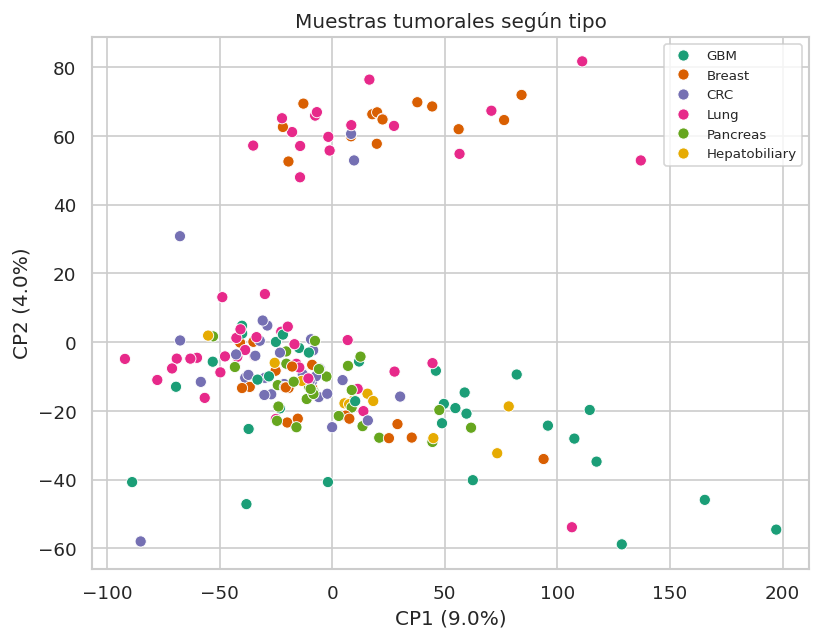

In [ ]:
pca_multi = PCA(n_components=10, random_state=semilla)
comp_multi = pca_multi.fit_transform(X_ent_multi_esc)
var_multi = pca_multi.explained_variance_ratio_

pca_multi_df = pd.DataFrame(comp_multi[:, :2], index=X_ent_multi_esc.index,
                            columns=["CP1", "CP2"])
pca_multi_df["clase"] = y_ent_multi

print("Varianza explicada (solo muestras tumorales):")
for i, v in enumerate(var_multi[:3], start=1):
    print(f"  CP{i}: {v:.1%}")

plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=pca_multi_df, x="CP1", y="CP2", hue="clase",
                palette="Dark2", s=45)
plt.title("Muestras tumorales según tipo")
plt.xlabel(f"CP1 ({var_multi[0]:.1%})"); plt.ylabel(f"CP2 ({var_multi[1]:.1%})")
plt.legend(fontsize=8, title=None)
plt.tight_layout(); plt.show()

Al repetir el análisis solo con las 183 muestras tumorales del conjunto de entrenamiento, el resultado es que los seis tipos de tumor no se separan. En la nube central aparecen mezclados, de modo que dos muestras próximas en el gráfico pueden pertenecer a tumores distintos. Solo se aprecia una leve tendencia de las muestras de pulmón a colocarse hacia la izquierda, que no es suficiente para distinguirlas del resto. Además, vuelve a verse el grupo desplazado hacia arriba, que corresponde de nuevo a los lotes Batch05 y Batch06.

Las dos primeras componentes recogen aquí el 9% y el 4% de la variación, cifras algo menores que en el conjunto completo, lo que resulta lógico al haber excluido a los controles sanos, cuyo perfil era el más diferenciado.

Este resultado no invalida la tarea multiclase, pero muestra que será más difícil que la binaria, ya que las diferencias entre un cáncer de mama y uno de páncreas existen, pero afectan a unos pocos genes y quedan tapadas por la variación del resto. Por ello se necesitan aplicar métodos de selección de características antes del modelado, puesto que, a diferencia del análisis de componentes principales, estos sí utilizan las etiquetas y pueden localizar los genes que separan las clases, aunque su aportación a la variación total sea pequeña.

### **Preparación de las estrategias frente al desbalance de las clases**

Para el desbalance se comparan tres alternativas. La primera consiste en no aplicar ninguna corrección, y sirve de referencia para valorar si las demás aportan algo. La segunda pondera las clases durante el entrenamiento, penalizando más los errores cometidos sobre las categorías minoritarias sin modificar los datos. La tercera genera muestras sintéticas de las clases pequeñas mediante SMOTE, interpolando entre vecinos próximos.

Si el reequilibrado se aplicase antes de dividir los datos, las muestras sintéticas generadas a partir del conjunto de entrenamiento podrían acabar evaluándose como si fueran casos nuevos, y el rendimiento saldría inflado. Para evitarlo se emplea la estructura de flujo de imbalanced-learn, que aplica el remuestreo solo a la parte de entrenamiento de cada pliegue y deja intacta la de evaluación.

In [ ]:
from imblearn.pipeline import Pipeline as PipelineDesbalance
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

estrategias = ["ninguna", "ponderacion", "smote"]

In [ ]:
# SMOTE genera muestras nuevas interpolando entre las vecinas más próximas de cada clase, por lo que una clase necesita al menos tantas muestras como vecinas se le pidan, más una.
# Dentro de la validación cruzada cada pliegue entrena con solo cuatro quintas partes de los datos, así que se comprueba que la clase más pequeña siga teniendo suficientes en ese caso.
n_pliegues = 5
k_vecinos = 5

for nombre, y in [("binaria", y_ent_bin), ("multiclase", y_ent_multi)]:
    minima = y.value_counts().min()
    clase_min = y.value_counts().idxmin()
    en_pliegue = int(minima * (n_pliegues - 1) / n_pliegues)
    print(f"{nombre:11s} clase menor: {clase_min} ({minima} muestras) -> "
          f"~{en_pliegue} al entrenar en cada pliegue "
          f"{'(suficiente)' if en_pliegue > k_vecinos else '(INSUFICIENTE)'}")

binaria     clase menor: Sano (44 muestras) -> ~35 al entrenar en cada pliegue (suficiente)
multiclase  clase menor: Hepatobiliary (11 muestras) -> ~8 al entrenar en cada pliegue (suficiente)


In [ ]:
# Se muestra qué hace SMOTE sobre el conjunto de entrenamiento completo
muestreador = SMOTE(random_state=semilla, k_neighbors=5)

for nombre, X_datos, y in [("Binaria", X_ent_bin, y_ent_bin),
                           ("Multiclase", X_ent_multi, y_ent_multi)]:
    _, y_remuestreado = muestreador.fit_resample(X_datos, y)
    print(f"{nombre}:")
    print("  antes: ", y.value_counts().to_dict())
    print("  después:", pd.Series(y_remuestreado).value_counts().to_dict(), "\n")

Binaria:
  antes:  {'Cáncer': 183, 'Sano': 44}
  después: {'Cáncer': 183, 'Sano': 183} 

Multiclase:
  antes:  {'Lung': 47, 'CRC': 34, 'GBM': 32, 'Breast': 31, 'Pancreas': 28, 'Hepatobiliary': 11}
  después: {'GBM': 47, 'Breast': 47, 'CRC': 47, 'Lung': 47, 'Pancreas': 47, 'Hepatobiliary': 47} 



Las tres estrategias quedan preparadas junto con el escalado, de modo que todas las operaciones que dependen de los datos se recalculen en cada pliegue de la validación cruzada.

La comprobación previa confirma que SMOTE puede aplicarse en ambas tareas, siendo el caso más ajustado es el del grupo hepatobiliar, que con 11 muestras de entrenamiento conserva unas 8 en cada pliegue, suficientes para el método aunque con margen pequeño.

El efecto del remuestreo equipara todas las clases a la más numerosa. En la tarea binaria los 44 controles sanos crecen hasta los 183 casos de cáncer, y en la multiclase todas las categorías alcanzan las 47 muestras de la clase de pulmón. Esto supone que más de tres cuartas partes de las muestras de los pacientes con cáncer hepatobiliar pasarían a ser sintéticas, construidas a partir de 11 casos reales. Se debe decir que la comprobación anterior se realiza sobre la matriz completa, mientras que dentro del flujo el remuestreo se aplica después de la selección de genes, sobre 5000 variables en la tarea binaria y 1000 en la multiclase. Aun así, no puede afirmarse que el método sea beneficioso, ya que interpolar entre tan pocos ejemplos en un espacio de esa dimensión puede añadir más ruido que información.

## **Fase 3: modelado**

Objetivo del bloque: reducir el número de variables mediante selección de características, comparar cinco algoritmos de clasificación cruzados con las tres estrategias frente al desbalance, y afinar los hiperparámetros de las combinaciones con más potencial.

*Nota:* la selección de características utiliza las etiquetas, por lo que se realiza dentro de cada pliegue de la validación cruzada y nunca sobre el conjunto completo.

### **Selección de características**

La matriz de entrada sigue teniendo los 57736 genes, de manera que el desajuste entre dimensiones sigue siendo la principal dificultad. Dentro del flujo, esa cifra se reduce en dos pasos encadenados. El primero es el filtrado por expresión de la fase anterior, que descarta los genes sin señal detectable y no atiende a las etiquetas. El segundo, que se describe a continuación, ordena los genes ya filtrados según su capacidad para separar las clases y conserva solo los mejores.

Esa distinción necesita comparar cada gen con la etiqueta, lo que convierte la selección en un paso supervisado y obliga a realizarla dentro de la validación cruzada. Si se hiciera antes, sobre todo el conjunto de entrenamiento, los genes elegidos se habrían escogido sabiendo cómo se comportan en las muestras que después servirán para evaluar cada pliegue, y el rendimiento resultaría optimista.

El método usado es un filtro univariante que ordena los genes según el estadístico F del análisis de varianza, midiendo hasta qué punto cada uno separa las medias de las clases. Se ha escogido por su bajo coste de cálculo, que es necesario al tener que repetirse en cada pliegue y para cada combinación de la rejilla. El número de genes a conservar no se fija de antemano, sino que se prueban varios valores y se decide con los resultados.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.base import BaseEstimator, TransformerMixin

class FiltroNormalizacion(BaseEstimator, TransformerMixin):
    """Filtra los genes poco expresados y transforma a log2(CPM + 1)."""

    def __init__(self, umbral_cpm=1.0, min_muestras=14):
        self.umbral_cpm = umbral_cpm
        self.min_muestras = min_muestras

    def _cpm(self, X):
        X = np.asarray(X, dtype=float)
        total = X.sum(axis=1, keepdims=True)
        total[total == 0] = 1
        return X / total * 1e6

    def fit(self, X, y=None):
        cpm = self._cpm(X)
        self.mascara_ = (cpm >= self.umbral_cpm).sum(axis=0) >= self.min_muestras
        return self

    def transform(self, X):
        cpm = self._cpm(X)[:, self.mascara_]
        return np.log2(cpm + 1)


def construir_flujo(modelo, estrategia, k_genes):
    "Filtrado y normalización, escalado, selección, reequilibrado y modelo."
    pasos = [("filtrado", FiltroNormalizacion(umbral_cpm=1, min_muestras=14)),
             ("escalado", StandardScaler()),
             ("seleccion", SelectKBest(f_classif, k=k_genes))]
    if estrategia == "smote":
        pasos.append(("remuestreo", SMOTE(random_state=semilla, k_neighbors=5)))
    pasos.append(("modelo", modelo))
    return PipelineDesbalance(pasos)

Para decidir cuántos genes se conservan, se prueban varios valores y se compara el rendimiento obtenido mediante validación cruzada. La exploración se realiza con regresión logística y sin corrección del desbalance, ya que su finalidad es conseguir un rango razonable y no comparar modelos (cruzar el número de genes con las 15 combinaciones de la rejilla multiplicaría el coste sin aportar información útil).

En la tarea binaria se incluye además la opción de conservar todos los genes disponibles, que equivale a no seleccionar y sirve como referencia para saber si la selección aporta algo.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

# En la binaria se llega hasta el total de genes; en la multiclase no es necesario, ya que el rendimiento no crece a partir de unos pocos miles.
exploracion = {
    "binaria":    (X_ent_bin,   y_ent_bin,   [50, 100, 250, 500, 1000, 2000, 5000, 10000, "all"]),
    "multiclase": (X_ent_multi, y_ent_multi, [50, 100, 250, 500, 1000, 2000, 5000]),
}

resultados_k = []
for tarea, (X_datos, y, valores_k) in exploracion.items():
    for k in valores_k:
        flujo = construir_flujo(
            LogisticRegression(max_iter=2000, random_state=semilla),
            estrategia="ninguna", k_genes=k)
        p = cross_val_score(flujo, X_datos, y, cv=cv,
                            scoring="balanced_accuracy", n_jobs=-1)
        resultados_k.append({"tarea": tarea, "k": k,
                             "media": p.mean(), "desviacion": p.std()})

tabla_k = pd.DataFrame(resultados_k)

for tarea in exploracion:
    sub = tabla_k[tabla_k["tarea"] == tarea]
    print(f"{tarea.upper()}")
    print(sub[["k", "media", "desviacion"]].round(3).to_string(index=False), "\n")

BINARIA
    k  media  desviacion
   50  0.772       0.067
  100  0.771       0.092
  250  0.764       0.046
  500  0.781       0.046
 1000  0.799       0.042
 2000  0.836       0.033
 5000  0.850       0.034
10000  0.863       0.045
  all  0.902       0.024 

MULTICLASE
   k  media  desviacion
  50  0.520       0.097
 100  0.592       0.092
 250  0.554       0.076
 500  0.539       0.085
1000  0.556       0.071
2000  0.566       0.050
5000  0.566       0.083 



Las cifras obtenidas presentan una dispersión considerable entre pliegues, de modo que las diferencias pequeñas entre configuraciones cercanas podrían deberse al azar. Para distinguir qué tendencias son reales, la exploración se ha repetido con una partición distinta, y si el orden entre configuraciones se mantiene, la diferencia es consistente, pero si se invierte, se trata de ruido.

In [ ]:
cv_alternativa = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla + 1)

verificacion = {
    "binaria":    (X_ent_bin,   y_ent_bin,   [1000, 5000, "all"]),
    "multiclase": (X_ent_multi, y_ent_multi, [100, 1000, 2000, 5000]),
}

for tarea, (X_datos, y, valores_k) in verificacion.items():
    print(f"{tarea.upper()} (segunda partición)")
    for k in valores_k:
        flujo = construir_flujo(
            LogisticRegression(max_iter=2000, random_state=semilla),
            estrategia="ninguna", k_genes=k)
        p = cross_val_score(flujo, X_datos, y, cv=cv_alternativa,
                            scoring="balanced_accuracy", n_jobs=-1)
        print(f"  k={str(k):>6}  {p.mean():.3f} ± {p.std():.3f}")
    print()

BINARIA (segunda partición)
  k=  1000  0.813 ± 0.091
  k=  5000  0.877 ± 0.066
  k=   all  0.884 ± 0.075

MULTICLASE (segunda partición)
  k=   100  0.546 ± 0.050
  k=  1000  0.587 ± 0.057
  k=  2000  0.581 ± 0.044
  k=  5000  0.568 ± 0.029



Se observan dos comportamientos distintos según la tarea.

- En la binaria, el rendimiento aumenta de forma sostenida a medida que se conservan más genes, desde 0,772 con cincuenta hasta 0,902 conservando todos los genes que superan el filtrado, sin que aparezca ningún máximo intermedio. El orden entre configuraciones se mantiene al repetir la validación cruzada con una partición distinta, de modo que el filtro univariante no localiza ningún subconjunto que supere al total.

- En la multiclase el comportamiento es otro. Salvo con 50 genes, donde el rendimiento es claramente inferior, el resto de valores se mueven en un rango pequeño en torno a 0,55-0,59, sin una tendencia clara al aumentar el número de genes. La prueba con la segunda partición lo confirma: la configuración que parecía mejor en el primer reparto pasa a ser la peor en el segundo, y el orden entre los valores intermedios cambia por completo, de manera que las diferencias responden a la variabilidad y no a una ventaja real de ninguna selección.

Por tanto, se fijan 5000 genes para la tarea binaria y 1000 para la multiclase. La decisión no se apoya en una mejora del rendimiento, que no se produce en ningún caso, sino en dos razones: la primera es práctica, ya que la rejilla de 15 combinaciones debe entrenarse repetidamente y reducir el número de variables abarata el cálculo; la segunda es que para identificar los genes característicos de cada tipo de cáncer se necesita acotar el conjunto a un tamaño interpretable.

La selección cumple entonces una función de prefiltrado, mientras que la reducción a una firma génica se llevará a cabo al final del trabajo.

In [ ]:
# Valores de prefiltrado que se emplearán en la rejilla de la fase siguiente
k_binaria = 5000
k_multiclase = 1000

Conviene detenerse en cómo cambia el número de genes a lo largo del análisis, ya que las cifras que aparecen en las fases siguientes vienen de puntos distintos de ese recorrido.

El filtrado por expresión, primer paso del flujo, deja 12844 genes en la tarea binaria y 11929 en la multiclase. La diferencia respecto a los 13331 del diagnóstico de la fase anterior se debe a que aquel se calculó sobre las 284 muestras y estos solo sobre las de entrenamiento de cada tarea.

La selección univariante parte de esos genes ya filtrados, no de los 57736 iniciales, y conserva los 5000 primeros en la binaria y los 1000 en la multiclase.

Ambos pasos se recalculan en cada pliegue de la validación cruzada, de manera que las cifras anteriores corresponden al ajuste sobre el conjunto de entrenamiento completo y cambian ligeramente entre pliegues.

In [ ]:
# Recorrido de los genes en cada tarea, con las cifras reales de cada paso
filtro_diagnostico = FiltroNormalizacion(umbral_cpm=1, min_muestras=14)

recorrido = []
for nombre, X_datos, k in [("binaria", X_ent_bin, k_binaria),
                           ("multiclase", X_ent_multi, k_multiclase)]:
    filtro_diagnostico.fit(X_datos)
    recorrido.append({
        "tarea": nombre,
        "genes de partida": X_datos.shape[1],
        "tras el filtrado": int(filtro_diagnostico.mascara_.sum()),
        "tras la selección": k,
    })

print(pd.DataFrame(recorrido).to_string(index=False))

     tarea  genes de partida  tras el filtrado  tras la selección
   binaria             57736             12844               5000
multiclase             57736             11929               1000


### **Comparación de la rejilla de combinaciones**

La parte central del trabajo es la comparación de 5 algoritmos cruzados con las 3 estrategias frente al desbalance, lo que da lugar a 15 combinaciones por tarea. Todas se evalúan sobre los mismos datos, con la misma partición de validación cruzada y las mismas métricas, de modo que las diferencias observadas se deban a la combinación y no al procedimiento.

Esta primera comparación usa los hiperparámetros por defecto de cada algoritmo. Su finalidad no es obtener el mejor resultado posible, sino descartar las combinaciones que quedan claramente por detrás antes de afinarlas. El ajuste se realizará solo en aquellas que hayan demostrado ser mejores.

Es importante saber que la ponderación de clases no está disponible de la misma manera en todos los algoritmos. La regresión logística, la máquina de vectores soporte y el bosque aleatorio admiten un parámetro que reequilibra el peso de cada clase durante el entrenamiento. Sin embargo, los k vecinos más próximos no lo tienen, por lo que se usa en su lugar el ponderado por distancia, alternativa que favorece a las muestras cercanas y disminuye en parte el dominio de la clase mayoritaria, aunque no resulta equivalente. Además, el gradient boosting asigna pesos a cada muestra en función de la frecuencia de su clase.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

def crear_modelo(nombre, estrategia):
    """Devuelve el modelo configurado según la estrategia de desbalance."""
    ponderar = (estrategia == "ponderacion")
    if nombre == "regresion_logistica":
        return LogisticRegression(max_iter=2000, random_state=semilla,
                                  class_weight="balanced" if ponderar else None)
    if nombre == "knn":
        # No admite ponderación de clases; se usa el ponderado por distancia
        return KNeighborsClassifier(weights="distance" if ponderar else "uniform")
    if nombre == "svm":
        return SVC(random_state=semilla, probability=True,
                   class_weight="balanced" if ponderar else None)
    if nombre == "random_forest":
        return RandomForestClassifier(random_state=semilla, n_jobs=-1,
                                      class_weight="balanced" if ponderar else None)
    if nombre == "xgboost":
        # La ponderación se aplica por muestra en el momento de entrenar
        return XGBClassifier(random_state=semilla, n_jobs=-1,
                             eval_metric="logloss", verbosity=0)

modelos = ["regresion_logistica", "knn", "svm", "random_forest", "xgboost"]
estrategias = ["ninguna", "ponderacion", "smote"]

Cada combinación se evalúa mediante validación cruzada estratificada de 5 pliegues sobre el conjunto de entrenamiento. Y, se registran varias métricas a la vez: la exactitud balanceada, que da el mismo peso a cada clase y sirve de criterio principal; la puntuación F1 promediada por clase; y el área bajo la curva ROC, que resume la capacidad de separación independientemente del umbral escogido.

In [ ]:
from sklearn.model_selection import cross_validate
import time

def evaluar_rejilla(X_datos, y, k_genes, multiclase):
    codificador = LabelEncoder()
    y_cod = pd.Series(codificador.fit_transform(y), index=y.index)

    metricas = ["balanced_accuracy", "f1_macro",
                "roc_auc_ovr" if multiclase else "roc_auc"]
    filas = []
    for nombre in modelos:
        for estrategia in estrategias:
            inicio = time.time()
            flujo = construir_flujo(crear_modelo(nombre, estrategia),
                                    estrategia, k_genes)
            # XGBoost necesita etiquetas numéricas; el resto acepta ambas
            objetivo = y_cod if nombre == "xgboost" else y
            ajuste = {}
            if nombre == "xgboost" and estrategia == "ponderacion":
                ajuste["modelo__sample_weight"] = compute_sample_weight("balanced", y_cod)

            resultado = cross_validate(flujo, X_datos, objetivo, cv=cv,
                                       scoring=metricas, n_jobs=-1,
                                       params=ajuste if ajuste else None)
            filas.append({
                "modelo": nombre, "estrategia": estrategia,
                "exactitud_balanceada": resultado["test_balanced_accuracy"].mean(),
                "desviacion": resultado["test_balanced_accuracy"].std(),
                "f1_macro": resultado["test_f1_macro"].mean(),
                "auc": resultado[f"test_{metricas[2]}"].mean(),
                "segundos": time.time() - inicio,
            })
            print(f"  {nombre:20s} {estrategia:12s} "
                  f"{filas[-1]['exactitud_balanceada']:.3f} "
                  f"({filas[-1]['segundos']:.0f}s)")
    return pd.DataFrame(filas), codificador

print("TAREA BINARIA")
rejilla_bin, cod_bin = evaluar_rejilla(X_ent_bin, y_ent_bin, k_binaria, False)
print("\nTAREA MULTICLASE")
rejilla_multi, cod_multi = evaluar_rejilla(X_ent_multi, y_ent_multi, k_multiclase, True)

TAREA BINARIA
  regresion_logistica  ninguna      0.850 (2s)
  regresion_logistica  ponderacion  0.869 (2s)
  regresion_logistica  smote        0.869 (4s)
  knn                  ninguna      0.678 (3s)
  knn                  ponderacion  0.678 (2s)
  knn                  smote        0.812 (2s)
  svm                  ninguna      0.778 (3s)
  svm                  ponderacion  0.841 (5s)
  svm                  smote        0.832 (6s)
  random_forest        ninguna      0.792 (4s)
  random_forest        ponderacion  0.792 (6s)
  random_forest        smote        0.832 (6s)
  xgboost              ninguna      0.836 (18s)
  xgboost              ponderacion  0.862 (19s)
  xgboost              smote        0.849 (38s)

TAREA MULTICLASE
  regresion_logistica  ninguna      0.556 (2s)
  regresion_logistica  ponderacion  0.582 (2s)
  regresion_logistica  smote        0.583 (2s)
  knn                  ninguna      0.449 (2s)
  knn                  ponderacion  0.481 (2s)
  knn                  sm

In [ ]:
for nombre, tabla in [("BINARIA", rejilla_bin), ("MULTICLASE", rejilla_multi)]:
    print(f"{nombre} - ordenada por exactitud balanceada y, en caso de empate, por AUC\n")
    print(tabla.sort_values(["exactitud_balanceada", "auc"], ascending=False)
          .round(3).to_string(index=False), "\n")

BINARIA - ordenada por exactitud balanceada y, en caso de empate, por AUC

             modelo  estrategia  exactitud_balanceada  desviacion  f1_macro   auc  segundos
regresion_logistica ponderacion                 0.869       0.058     0.879 0.982     2.411
regresion_logistica       smote                 0.869       0.058     0.879 0.981     3.858
            xgboost ponderacion                 0.862       0.025     0.866 0.974    19.110
regresion_logistica     ninguna                 0.850       0.034     0.874 0.982     2.429
            xgboost       smote                 0.849       0.062     0.858 0.963    38.161
                svm ponderacion                 0.841       0.065     0.837 0.945     4.642
            xgboost     ninguna                 0.836       0.037     0.857 0.970    17.706
      random_forest       smote                 0.832       0.042     0.835 0.933     6.409
                svm       smote                 0.832       0.061     0.849 0.960     6.487
     

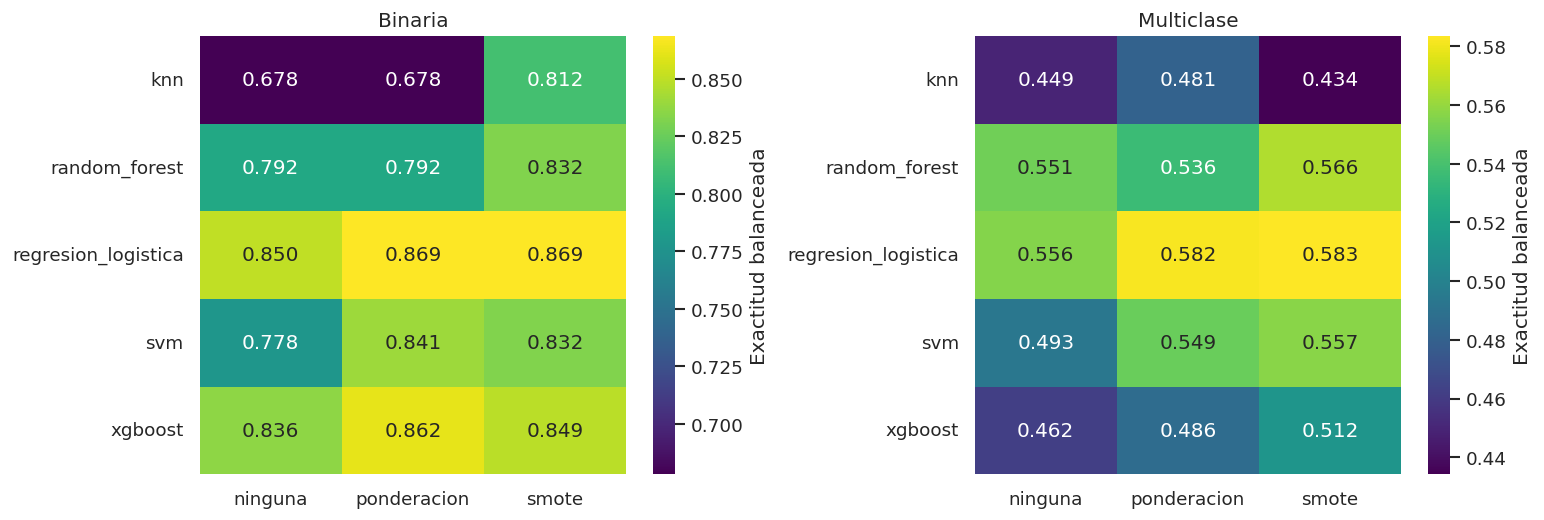

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for eje, (nombre, tabla) in zip(ejes, [("Binaria", rejilla_bin),
                                       ("Multiclase", rejilla_multi)]):
    matriz = tabla.pivot(index="modelo", columns="estrategia",
                         values="exactitud_balanceada")
    sns.heatmap(matriz, annot=True, fmt=".3f", cmap="viridis", ax=eje,
                cbar_kws={"label": "Exactitud balanceada"})
    eje.set_title(nombre); eje.set_xlabel(""); eje.set_ylabel("")
plt.tight_layout(); plt.show()

En la tarea binaria la regresión logística se coloca como ganadora, alcanzando una exactitud balanceada de 0,869 tanto con ponderación de clases como con SMOTE, frente al 0,850 si no se usa ninguna técnica frente al desbalance. Este comportamiento va en la línea de lo observado por Jopek et al. (2024) con datos de la misma naturaleza, donde un modelo lineal sencillo superó a métodos más complejos, aunque no se trata de una comparación directa, ya que los conjuntos de datos y los protocolos de evaluación son diferentes en ambos trabajos.

Las dos variantes de la regresión logística quedan empatadas en la métrica principal y se diferencian en 0,001 de área bajo la curva, que es irrelevante frente a una desviación típica de 0,058 entre pliegues. Por esto, aplicar corrección del desbalance sí aporta algo respecto a no aplicarla, aunque la mejora, de casi 0,02, tampoco resulta concluyente por sí sola.

El método de los k vecinos más próximos queda en último lugar, con una exactitud balanceada de 0,678 sin remuestreo frente al 0,812 que alcanza al aplicar SMOTE. Esto ocurre porque con miles de variables las distancias entre muestras tienden a igualarse y el criterio de proximidad pierde capacidad discriminativa. De hecho, hay que añadir que, en este modelo, la columna de 'ponderación' no aplica una ponderación de clases como en el resto de algoritmos, sino una ponderación de los vecinos por distancia, que es una estrategia distinta y no comparable como técnica frente al desbalance. Por eso su efecto en la tarea binaria es prácticamente nulo, ya que los pesos apenas cambian cuando todas las distancias son parecidas.

La tarea multiclase presenta una situación distinta. Los valores son considerablemente inferiores, con un máximo de 0,583 para la regresión logística con SMOTE, seguida de la regresión logística con ponderación en 0,582 y del random forest con SMOTE en 0,566. Las diferencias entre las tres primeras combinaciones son de milésimas y quedan muy por debajo de sus desviaciones típicas, que varían entre 0,042 y 0,047, de manera que no puede afirmarse que ninguna supere a las demás.

Es importante señalar que la regresión logística presenta una de las menores dispersiones, lo que indica un comportamiento más estable entre particiones.

Por último, destaca que el remuestreo mediante SMOTE resulta beneficioso en la mayoría de combinaciones de la tarea multiclase, mientras que en la binaria su efecto es menor, salvo en los k vecinos más próximos, donde es determinante.

El número de combinaciones que pasan al ajuste de hiperparámetros no se fija a ojo, sino que se escoge en función de la dispersión de los resultados.

Se calcula el error estándar de la mejor combinación, dividiendo su desviación típica entre la raíz del número de pliegues, y se conservan todas aquellas cuya media se sitúe dentro de esa distancia. Esto se basa en que, a menos de un error estándar de diferencia, no se puede afirmar que una combinación sea peor que otra, de manera que descartarla supondría dar por buena una diferencia que los datos no sostienen.

A este criterio se le añade un detalle: tiene que haber un mínimo de 5 combinaciones, para garantizar que la comparación final no quede extremadamente reducida.

In [ ]:
def seleccionar_candidatos(tabla, n_pliegues=5, maximo_por_modelo=3, minimo=5):
    """Combinaciones dentro de un error estándar de la mejor, con tope por
    algoritmo para evitar afinar el mismo modelo repetidamente."""
    tabla = tabla.copy()
    tabla["error_estandar"] = tabla["desviacion"] / np.sqrt(n_pliegues)
    mejor = tabla["exactitud_balanceada"].max()
    umbral = mejor - tabla.loc[tabla["exactitud_balanceada"].idxmax(), "error_estandar"]

    ordenada = tabla.sort_values("exactitud_balanceada", ascending=False)
    dentro = ordenada[ordenada["exactitud_balanceada"] >= umbral]

    # Tope por algoritmo
    elegidas = dentro.groupby("modelo").head(maximo_por_modelo)

    # Si quedan menos del mínimo, se completa con las siguientes mejores
    if len(elegidas) < minimo:
        resto = ordenada.drop(elegidas.index)
        resto = resto.groupby("modelo").head(maximo_por_modelo)
        elegidas = pd.concat([elegidas, resto.head(minimo - len(elegidas))])

    print(f"Mejor: {mejor:.3f} | umbral (un error estándar): {umbral:.3f}")
    print(f"Dentro del umbral: {len(dentro)} | seleccionadas: {len(elegidas)}\n")
    return elegidas.sort_values("exactitud_balanceada", ascending=False)

print("BINARIA")
candidatos_bin = seleccionar_candidatos(rejilla_bin)
print(candidatos_bin[["modelo", "estrategia", "exactitud_balanceada",
                      "desviacion"]].round(3).to_string(index=False))

print("\nMULTICLASE")
candidatos_multi = seleccionar_candidatos(rejilla_multi)
print(candidatos_multi[["modelo", "estrategia", "exactitud_balanceada",
                        "desviacion"]].round(3).to_string(index=False))

BINARIA
Mejor: 0.869 | umbral (un error estándar): 0.843
Dentro del umbral: 5 | seleccionadas: 5

             modelo  estrategia  exactitud_balanceada  desviacion
regresion_logistica ponderacion                 0.869       0.058
regresion_logistica       smote                 0.869       0.058
            xgboost ponderacion                 0.862       0.025
regresion_logistica     ninguna                 0.850       0.034
            xgboost       smote                 0.849       0.062

MULTICLASE
Mejor: 0.583 | umbral (un error estándar): 0.564
Dentro del umbral: 3 | seleccionadas: 5

             modelo  estrategia  exactitud_balanceada  desviacion
regresion_logistica       smote                 0.583       0.044
regresion_logistica ponderacion                 0.582       0.047
      random_forest       smote                 0.566       0.042
                svm       smote                 0.557       0.040
regresion_logistica     ninguna                 0.556       0.071


### **Ajuste de hiperparámetros**

Las combinaciones seleccionadas se han evaluado hasta ahora con los valores por defecto de cada algoritmo. Queda comprobar si un ajuste de sus parámetros modifica el orden o mejora el rendimiento de alguna de ellas.

La búsqueda se realiza mediante validación cruzada sobre el conjunto de entrenamiento, con la misma partición empleada en la comparación anterior, de modo que los resultados sean directamente comparables. Se va a realizar una búsqueda exhaustiva, que prueba todas las combinaciones de la rejilla definida para cada algoritmo; el número de candidatos es reducido y las rejillas se han mantenido acotadas, por lo que el coste computacional se ha reducido.

Las rejillas se limitan a los parámetros que dan complejidad al modelo, que son los que más influyen en el equilibrio entre sesgo y varianza. En la regresión logística se analiza la fuerza de la regularización y su tipo, contrastando la penalización L2, que reduce todos los coeficientes de forma proporcional, con la L1, que anula los correspondientes a las variables menos útiles y realiza así una selección dentro del propio entrenamiento (esta última es interesante ya que produce modelos más sencillos de interpretar); en el XGBoost, el número de árboles, su profundidad y la tasa de aprendizaje; en el bosque aleatorio, el número de árboles, su profundidad y el número de variables consideradas en cada división; y en la máquina de vectores soporte, el margen y la amplitud del núcleo.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Los nombres van prefijados con "modelo__" porque el algoritmo es un paso dentro del flujo que incluye escalado, selección y remuestreo.
rejillas = {
    "regresion_logistica": {"modelo__C": [0.01, 0.1, 1, 10, 100],
                            "modelo__penalty": ["l2", "l1"],
                            "modelo__solver": ["liblinear"]},
    "knn": {"modelo__n_neighbors": [3, 5, 7, 11, 15],
            "modelo__p": [1, 2]},
    "svm": {"modelo__C": [0.1, 1, 10, 100],
            "modelo__gamma": ["scale", 0.001, 0.01]},
    "random_forest": {"modelo__n_estimators": [100, 200, 500],
                      "modelo__max_depth": [None, 10, 20],
                      "modelo__max_features": ["sqrt", 0.1]},
    "xgboost": {"modelo__n_estimators": [100, 300],
                "modelo__max_depth": [3, 6],
                "modelo__learning_rate": [0.05, 0.1, 0.3]},
}

La elección de la mejor configuración se centra en la exactitud balanceada, que es el criterio principal por dar el mismo peso a cada clase. Las demás métricas se calculan sobre esa misma configuración ganadora, y permiten comprobar si el modelo elegido lo es de forma consistente o solo según un indicador concreto.

In [ ]:
def afinar(candidatos, X_datos, y, k_genes, multiclase):
    metricas = {
        "exactitud_balanceada": "balanced_accuracy",
        "f1_macro": "f1_macro",
        "precision": "precision_macro",
        "sensibilidad": "recall_macro",
        "auc": "roc_auc_ovr" if multiclase else "roc_auc",
    }
    # XGBoost necesita etiquetas numéricas; el resto de modelos aceptan ambas
    codificador = LabelEncoder()
    y_cod = pd.Series(codificador.fit_transform(y), index=y.index)

    resultados = []
    for _, fila in candidatos.iterrows():
        modelo, estrategia = fila["modelo"], fila["estrategia"]
        inicio = time.time()

        flujo = construir_flujo(crear_modelo(modelo, estrategia), estrategia, k_genes)
        objetivo = y_cod if modelo == "xgboost" else y
        busqueda = GridSearchCV(flujo, rejillas[modelo], cv=cv,
                                scoring=metricas, refit="exactitud_balanceada",
                                n_jobs=-1)
        busqueda.fit(X_datos, objetivo)

        i = busqueda.best_index_
        registro = {
            "modelo": modelo,
            "estrategia": estrategia,
            "por_defecto": fila["exactitud_balanceada"],
            "mejores_parametros": busqueda.best_params_,
            "segundos": time.time() - inicio,
        }
        for nombre_metrica in metricas:
            registro[nombre_metrica] = busqueda.cv_results_[f"mean_test_{nombre_metrica}"][i]
        registro["desviacion"] = busqueda.cv_results_["std_test_exactitud_balanceada"][i]

        resultados.append(registro)
        print(f"  {modelo:20s} {estrategia:12s} "
              f"{fila['exactitud_balanceada']:.3f} -> "
              f"{registro['exactitud_balanceada']:.3f} "
              f"({registro['segundos']:.0f}s)")
    return pd.DataFrame(resultados)

print("TAREA BINARIA")
afinado_bin = afinar(candidatos_bin, X_ent_bin, y_ent_bin, k_binaria, False)

print("\nTAREA MULTICLASE")
afinado_multi = afinar(candidatos_multi, X_ent_multi, y_ent_multi, k_multiclase, True)

TAREA BINARIA
  regresion_logistica  ponderacion  0.869 -> 0.937 (44s)
  regresion_logistica  smote        0.869 -> 0.937 (32s)
  xgboost              ponderacion  0.862 -> 0.870 (462s)
  regresion_logistica  ninguna      0.850 -> 0.937 (27s)
  xgboost              smote        0.849 -> 0.867 (965s)

TAREA MULTICLASE
  regresion_logistica  smote        0.583 -> 0.599 (27s)
  regresion_logistica  ponderacion  0.582 -> 0.593 (23s)
  random_forest        smote        0.566 -> 0.611 (234s)
  svm                  smote        0.557 -> 0.584 (31s)
  regresion_logistica  ninguna      0.556 -> 0.593 (23s)


In [ ]:
columnas = ["modelo", "estrategia", "exactitud_balanceada", "f1_macro",
            "precision", "sensibilidad", "auc", "desviacion"]
criterio = ["exactitud_balanceada", "f1_macro", "auc", "precision"]

for nombre, tabla in [("BINARIA", afinado_bin), ("MULTICLASE", afinado_multi)]:
    salida = tabla.sort_values(criterio, ascending=False)
    print(f"{nombre} - métricas tras el ajuste\n")
    print(salida[columnas].round(3).to_string(index=False))
    print(f"\n  (mejora sobre los valores por defecto: "
          f"{(salida['exactitud_balanceada'] - salida['por_defecto']).round(3).tolist()})\n")

BINARIA - métricas tras el ajuste

             modelo  estrategia  exactitud_balanceada  f1_macro  precision  sensibilidad   auc  desviacion
regresion_logistica ponderacion                 0.937     0.863      0.830         0.937 0.975       0.013
regresion_logistica       smote                 0.937     0.863      0.830         0.937 0.975       0.013
regresion_logistica     ninguna                 0.937     0.863      0.830         0.937 0.974       0.013
            xgboost ponderacion                 0.870     0.881      0.909         0.870 0.974       0.056
            xgboost       smote                 0.867     0.879      0.894         0.867 0.959       0.053

  (mejora sobre los valores por defecto: [0.069, 0.069, 0.087, 0.008, 0.018])

MULTICLASE - métricas tras el ajuste

             modelo  estrategia  exactitud_balanceada  f1_macro  precision  sensibilidad   auc  desviacion
      random_forest       smote                 0.611     0.598      0.637         0.611 0.863    

La comparación entre el rendimiento por defecto y el obtenido tras el ajuste permite valorar si este último aporta una mejora apreciable o si los valores por defecto ya eran adecuados para estos datos.

In [ ]:
# Valores por defecto de los parámetros que se han explorado en cada rejilla
def parametros_por_defecto(modelo, estrategia):
    instancia = crear_modelo(modelo, estrategia)
    parametros = instancia.get_params()
    claves = [p.replace("modelo__", "") for p in rejillas[modelo]]
    return {f"modelo__{c}": parametros.get(c, "(no definido)") for c in claves}

for nombre, tabla in [("BINARIA", afinado_bin), ("MULTICLASE", afinado_multi)]:
    print(f"{nombre}\n")
    for _, f in tabla.sort_values("exactitud_balanceada", ascending=False).iterrows():
        defecto = parametros_por_defecto(f["modelo"], f["estrategia"])
        print(f"{f['modelo']} - {f['estrategia']}")
        for clave, valor_afinado in f["mejores_parametros"].items():
            valor_defecto = defecto.get(clave)
            marca = "  <-- cambia" if valor_defecto != valor_afinado else ""
            print(f"   {clave.replace('modelo__', ''):15s} "
                  f"{str(valor_defecto):>8s}  ->  {str(valor_afinado):>8s}{marca}")
        print()

BINARIA

regresion_logistica - ponderacion
   C                    1.0  ->         1
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

regresion_logistica - smote
   C                    1.0  ->       0.1  <-- cambia
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

regresion_logistica - ninguna
   C                    1.0  ->       0.1  <-- cambia
   penalty               l2  ->        l2
   solver             lbfgs  ->  liblinear  <-- cambia

xgboost - ponderacion
   learning_rate       None  ->       0.1  <-- cambia
   max_depth           None  ->         3  <-- cambia
   n_estimators        None  ->       100  <-- cambia

xgboost - smote
   learning_rate       None  ->       0.1  <-- cambia
   max_depth           None  ->         6  <-- cambia
   n_estimators        None  ->       100  <-- cambia

MULTICLASE

random_forest - smote
   max_depth           None  ->      None
   max_features

El ajuste mejora todas las combinaciones, aunque con efectos muy distintos según la tarea.

En la binaria, la ganancia de exactitud balanceada va de 0,008 en el XGBoost con ponderación hasta 0,087 en la regresión logística sin corrección. En la multiclase la mayor mejora la consigue el bosque aleatorio con SMOTE, que gana 0,046.

Las tres variantes de la regresión logística consiguen, en la tarea binaria, una exactitud balanceada de 0,937. Y para todas ellas, la búsqueda selecciona la penalización L2 y un valor de regularización moderado, que es C=1 con ponderación de clases, y C=0,1 sin corrección del desbalance y con SMOTE. Este resultado muestra que ajustar la fuerza de la penalización compensa aquello que aportaba la corrección del desbalance, de forma que las tres estrategias acaban describiendo prácticamente el mismo modelo. Este resultado es valioso, ya que permite quedarse con la variante que no aplica corrección, la más simple de las tres, sin renunciar a rendimiento.

En la multiclase, el ajuste modifica el orden que se obtenía con los valores por defecto. El bosque aleatorio con SMOTE pasa a liderar la comparación con una exactitud balanceada de 0,611, seguido de la regresión logística con SMOTE con 0,599 y de sus variantes con ponderación y sin corrección, ambas en 0,593. La distancia entre estas configuraciones es pequeña, y en todos los casos queda por debajo de sus desviaciones típicas, que varían entre 0,038 y 0,064. De hecho, al observar el resto de métricas, se confirma ese equilibrio: el bosque aleatorio obtiene 0,863 de área bajo la curva y 0,598 de F1 macro, frente a 0,850 y 0,585 de la regresión logística con SMOTE, diferencias que se mantienen dentro del mismo margen. No puede afirmarse, por tanto, que ningún modelo supere de forma consistente a los demás.

En esta tarea, la búsqueda también ha seleccionado la penalización L2 en todas las regresiones logísticas ajustadas, sin que la L1 fuese preferible en ningún caso.

Un punto a tener en cuenta es que el coste de cálculo es muy desigual entre algoritmos. Por un lado, el bosque aleatorio con SMOTE necesitó casi 4 minutos y las dos configuraciones de XGBoost superaron los 7 y los 16 minutos, mientras que cada regresión logística se ajustó en torno a 20 o 40 segundos. Con resultados equivalentes, esta diferencia de coste refuerza la elección de un modelo lineal.

A partir de todo lo anterior se escogen los modelos definitivos, y la decisión se toma sobre la validación cruzada del conjunto de entrenamiento, sin intervención del conjunto de prueba.

- En la tarea binaria, las tres variantes de la regresión logística alcanzan métricas prácticamente idénticas, de manera que ninguna puede considerarse superior a las demás. Ante ese empate se selecciona la que no aplica corrección del desbalance, por ser la más simple, y la variante con ponderación se conserva como comprobación, cuyo resultado sobre el conjunto de prueba se informará junto al del modelo principal, aunque la elección queda fijada antes de la evaluación.

- En la tarea multiclase, el bosque aleatorio con SMOTE obtiene la mejor exactitud balanceada, pero solo supera a la regresión logística con SMOTE en 0,012, una diferencia menor que la variabilidad entre pliegues de ambos modelos. Cuando dos modelos son estadísticamente equivalentes, la elección no puede apoyarse en la tercera cifra decimal, sino en criterios de simplicidad, coste e interpretación. Por ese motivo se selecciona la regresión logística con SMOTE, que consigue un rendimiento casi indistinguible del bosque aleatorio, es coherente con el modelo elegido para la tarea binaria, tiene un coste de cálculo mucho menor y, sobre todo, da un coeficiente con signo para cada gen y cada clase, lo que permite construir una firma génica interpretable, algo que la importancia de variables del bosque aleatorio no ofrece de forma equiparable. En esta tarea sí se conserva la corrección del desbalance en el modelo principal, no porque el desequilibrio entre clases sea mayor que en la binaria, que es de magnitud similar, sino porque en la multiclase el remuestreo con SMOTE fue la mejor de las tres variantes de la regresión logística y fue beneficioso en la mayoría de las combinaciones de la comparación. Además, el problema es  más exigente, ya que hay seis clases que separar entre sí y la menor, la hepatobiliar, cuenta con solo 14 muestras que deben distinguirse del resto, de manera que reforzar las clases minoritarias con ejemplos sintéticos tiene aquí más sentido que en la binaria. La variante sin corrección del desbalance se conserva como comprobación, y su resultado sobre el conjunto de prueba se informará junto al del modelo principal.

*Nota:* Se deja constancia de que el bosque aleatorio fue ligeramente superior en la métrica principal, de modo que la elección del modelo lineal es una decisión razonada y no el resultado de ignorar una alternativa mejor.

In [ ]:
# Tarea binaria
mejor_bin = afinado_bin[(afinado_bin["modelo"] == "regresion_logistica") &
                        (afinado_bin["estrategia"] == "ninguna")].iloc[0]
alternativa_bin = afinado_bin[(afinado_bin["modelo"] == "regresion_logistica") &
                              (afinado_bin["estrategia"] == "ponderacion")].iloc[0]

# Tarea multiclase
mejor_multi = afinado_multi[(afinado_multi["modelo"] == "regresion_logistica") &
                            (afinado_multi["estrategia"] == "smote")].iloc[0]
alternativa_multi = afinado_multi[(afinado_multi["modelo"] == "regresion_logistica") &
                                  (afinado_multi["estrategia"] == "ninguna")].iloc[0]

for nombre, fila in [("binaria (principal)", mejor_bin),
                     ("binaria (comprobación)", alternativa_bin),
                     ("multiclase (principal)", mejor_multi),
                     ("multiclase (comprobación)", alternativa_multi)]:
    print(f"{nombre}: {fila['modelo']} - {fila['estrategia']}")
    print(f"  {fila['mejores_parametros']}")
    print(f"  exactitud balanceada (validación cruzada): "
          f"{fila['exactitud_balanceada']:.3f}\n")

binaria (principal): regresion_logistica - ninguna
  {'modelo__C': 0.1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.937

binaria (comprobación): regresion_logistica - ponderacion
  {'modelo__C': 1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.937

multiclase (principal): regresion_logistica - smote
  {'modelo__C': 1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.599

multiclase (comprobación): regresion_logistica - ninguna
  {'modelo__C': 1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  exactitud balanceada (validación cruzada): 0.593



## **Fase 4: evaluación**

Objetivo del bloque: estimar el rendimiento real de los modelos seleccionados sobre el conjunto de prueba, analizar sus errores mediante la matriz de confusión, comprobar la estabilidad de los resultados frente al reparto de los datos y contrastarlos con los estudios de referencia.

Los modelos seleccionados se entrenan ahora con todo el conjunto de entrenamiento, y no por pliegues, usando los hiperparámetros elegidos en la fase anterior. El resultado se aplica a las muestras reservadas, que son 57 en la tarea binaria y 46 en la multiclase.

Las cifras obtenidas aquí son las que estiman el rendimiento real, y previsiblemente serán algo inferiores a las de validación cruzada.

### **Entrenamiento y predicción**

In [ ]:
from sklearn.metrics import (balanced_accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix,
                             classification_report)

def entrenar_y_evaluar(fila, X_ent, y_ent, X_pru, y_pru, k_genes, multiclase):
    """Entrena con todo el conjunto de entrenamiento y evalúa sobre prueba."""
    flujo = construir_flujo(crear_modelo(fila["modelo"], fila["estrategia"]),
                            fila["estrategia"], k_genes)
    flujo.set_params(**fila["mejores_parametros"])
    flujo.fit(X_ent, y_ent)

    prediccion = flujo.predict(X_pru)
    probabilidad = flujo.predict_proba(X_pru)

    if multiclase:
        auc = roc_auc_score(y_pru, probabilidad, multi_class="ovr",
                            average="macro", labels=flujo.classes_)
    else:
        # Se toma "Cáncer" como clase positiva, convirtiendo las etiquetas a 0 y 1
        indice_positiva = list(flujo.classes_).index("Cáncer")
        auc = roc_auc_score((y_pru == "Cáncer").astype(int),
                            probabilidad[:, indice_positiva])

    metricas = {
        "exactitud_balanceada": balanced_accuracy_score(y_pru, prediccion),
        "f1_macro": f1_score(y_pru, prediccion, average="macro"),
        "precision": precision_score(y_pru, prediccion, average="macro",
                                     zero_division=0),
        "sensibilidad": recall_score(y_pru, prediccion, average="macro"),
        "auc": auc,
    }
    return flujo, prediccion, probabilidad, metricas

# Modelo principal de la tarea binaria (regresión logística sin corrección)
flujo_bin, pred_bin, prob_bin, met_bin = entrenar_y_evaluar(
    mejor_bin, X_ent_bin, y_ent_bin, X_pru_bin, y_pru_bin,
    k_binaria, multiclase=False)

# Variante con ponderación de clases, conservada como comprobación de robustez
flujo_alt, pred_alt, prob_alt, met_alt = entrenar_y_evaluar(
    alternativa_bin, X_ent_bin, y_ent_bin, X_pru_bin, y_pru_bin,
    k_binaria, multiclase=False)

# Modelo principal de la tarea multiclase (regresión logística con SMOTE)
flujo_multi, pred_multi, prob_multi, met_multi = entrenar_y_evaluar(
    mejor_multi, X_ent_multi, y_ent_multi, X_pru_multi, y_pru_multi,
    k_multiclase, multiclase=True)

# Variante sin corrección del desbalance, conservada como comprobación
flujo_multialt, pred_multialt, prob_multialt, met_multialt = entrenar_y_evaluar(
    alternativa_multi, X_ent_multi, y_ent_multi, X_pru_multi, y_pru_multi,
    k_multiclase, multiclase=True)

In [ ]:
comparativa = pd.DataFrame([
    {"tarea": "binaria", "modelo": f"{mejor_bin['modelo']} - {mejor_bin['estrategia']}",
     "origen": "validación cruzada", **{k: mejor_bin[k] for k in met_bin}},
    {"tarea": "binaria", "modelo": f"{mejor_bin['modelo']} - {mejor_bin['estrategia']}",
     "origen": "conjunto de prueba", **met_bin},
    {"tarea": "binaria", "modelo": f"{alternativa_bin['modelo']} - {alternativa_bin['estrategia']}",
     "origen": "conjunto de prueba (comprobación)", **met_alt},
    {"tarea": "multiclase", "modelo": f"{mejor_multi['modelo']} - {mejor_multi['estrategia']}",
     "origen": "validación cruzada", **{k: mejor_multi[k] for k in met_multi}},
    {"tarea": "multiclase", "modelo": f"{mejor_multi['modelo']} - {mejor_multi['estrategia']}",
     "origen": "conjunto de prueba", **met_multi},
    {"tarea": "multiclase", "modelo": f"{alternativa_multi['modelo']} - {alternativa_multi['estrategia']}",
     "origen": "conjunto de prueba (comprobación)", **met_multialt},
])

print(comparativa.round(3).to_string(index=False))

     tarea                            modelo                            origen  exactitud_balanceada  f1_macro  precision  sensibilidad   auc
   binaria     regresion_logistica - ninguna                validación cruzada                 0.937     0.863      0.830         0.937 0.974
   binaria     regresion_logistica - ninguna                conjunto de prueba                 0.946     0.879      0.844         0.946 0.984
   binaria regresion_logistica - ponderacion conjunto de prueba (comprobación)                 0.935     0.858      0.824         0.935 0.984
multiclase       regresion_logistica - smote                validación cruzada                 0.599     0.585      0.636         0.599 0.850
multiclase       regresion_logistica - smote                conjunto de prueba                 0.599     0.610      0.632         0.599 0.822
multiclase     regresion_logistica - ninguna conjunto de prueba (comprobación)                 0.641     0.653      0.681         0.641 0.823


In [ ]:
print("TAREA BINARIA - modelo principal (sin corrección)\n")
print(classification_report(y_pru_bin, pred_bin, digits=3, zero_division=0))

print("\nTAREA BINARIA - comprobación (ponderación)\n")
print(classification_report(y_pru_bin, pred_alt, digits=3, zero_division=0))

print("\nTAREA MULTICLASE - modelo principal (SMOTE)\n")
print(classification_report(y_pru_multi, pred_multi, digits=3, zero_division=0))

print("\nTAREA MULTICLASE - comprobación (sin corrección)\n")
print(classification_report(y_pru_multi, pred_multialt, digits=3, zero_division=0))

TAREA BINARIA - modelo principal (sin corrección)

              precision    recall  f1-score   support

      Cáncer      1.000     0.891     0.943        46
        Sano      0.688     1.000     0.815        11

    accuracy                          0.912        57
   macro avg      0.844     0.946     0.879        57
weighted avg      0.940     0.912     0.918        57


TAREA BINARIA - comprobación (ponderación)

              precision    recall  f1-score   support

      Cáncer      1.000     0.870     0.930        46
        Sano      0.647     1.000     0.786        11

    accuracy                          0.895        57
   macro avg      0.824     0.935     0.858        57
weighted avg      0.932     0.895     0.902        57


TAREA MULTICLASE - modelo principal (SMOTE)

               precision    recall  f1-score   support

       Breast      0.714     0.625     0.667         8
          CRC      0.625     0.625     0.625         8
          GBM      0.857     0.750    

Respecto a la tarea binaria:

El modelo seleccionado consigue sobre el conjunto de prueba una exactitud balanceada de 0,946 y un área bajo la curva de 0,984, frente al 0,937 y 0,974 alcanzados por validación cruzada. La variante con ponderación de clases obtiene resultados prácticamente idénticos, con 0,935 de exactitud balanceada y 0,984 de área bajo la curva, lo que confirma que la elección entre ambas era indiferente y refuerza haber elegido la más simple.

La separación por clases es especialmente efectiva en el grupo de control. El modelo acierta los 11 controles sanos sin excepción, de manera que no comete ningún falso positivo, y detecta el 89,1% de los 46 casos de cáncer (5 muestras tumorales que quedan sin identificar correctamente). La precisión al predecir la clase cáncer es del 100%, mientras que la de la clase sana se sitúa en 0,688, ya que las 5 muestras de cáncer no detectadas se suman a los controles verdaderos.

El área bajo la curva de 0,984 confirma que el modelo ordena muy bien las muestras según su probabilidad de corresponder a un paciente con cáncer. Por tanto, la capacidad discriminativa es alta, y el pequeño margen de error se debe a los falsos negativos, es decir, en casos de cáncer con una probabilidad estimada por debajo del umbral por defecto de 0,5. Reducir ese umbral probablemente podría recuperar algún falso negativo sin aumentar necesariamente los falsos positivos. Este ajuste debe realizarse mediante validación cruzada sobre el conjunto de entrenamiento, nunca sobre el de prueba, por lo que se plantea como análisis exploratorio en el apartado siguiente.

Respecto a la tarea multiclase:

El modelo principal, la regresión logística con SMOTE, obtiene sobre el conjunto de prueba una exactitud balanceada de 0,599, que coincide con la estimada por validación cruzada, y un área bajo la curva de 0,822. La variante de comprobación, sin corrección del desbalance, consigue una exactitud balanceada algo mayor, de 0,641, con un F1 macro de 0,653.

El hecho de que la variante de comprobación supere ligeramente a la principal, cuando en validación cruzada ocurría lo contrario por un margen  pequeño, confirma que ambas configuraciones son equivalentes y que las diferencias entre ellas se deben al azar del reparto de muestras, no a una ventaja real de ninguna. La elección del modelo principal se mantiene, ya que se fijó sobre la validación cruzada antes de conocer el conjunto de prueba.

Por último, se observa que el rendimiento por clase es diferente. Por un lado, el glioblastoma se identifica con mayor facilidad, con una sensibilidad de 0,750, y el cáncer de pulmón alcanza 0,833; por otro lado, el de mama y colorrectal se sitúan en 0,625, mientras que el páncreas baja a 0,429 y la clase hepatobiliar a 0,333. El área bajo la curva se mantiene en torno a 0,82, lo que indica que el modelo conserva capacidad de ordenación aunque su asignación de clases sea más limitada que en la tarea binaria.

Una vez conocidos los resultados, se deben analizar las matrices de confusión de los modelos para observar en qué clases se cometen más fallos.

### **Matriz de confusión para analizar los errores**

Las métricas globales resumen el rendimiento en una cifra, pero no indican dónde se equivoca el modelo. La matriz de confusión combina la clase real de cada muestra con la predicha, de modo que permite distinguir si los fallos se reparten de forma uniforme o se concentran en determinadas categorías, y con qué otras se confunden.

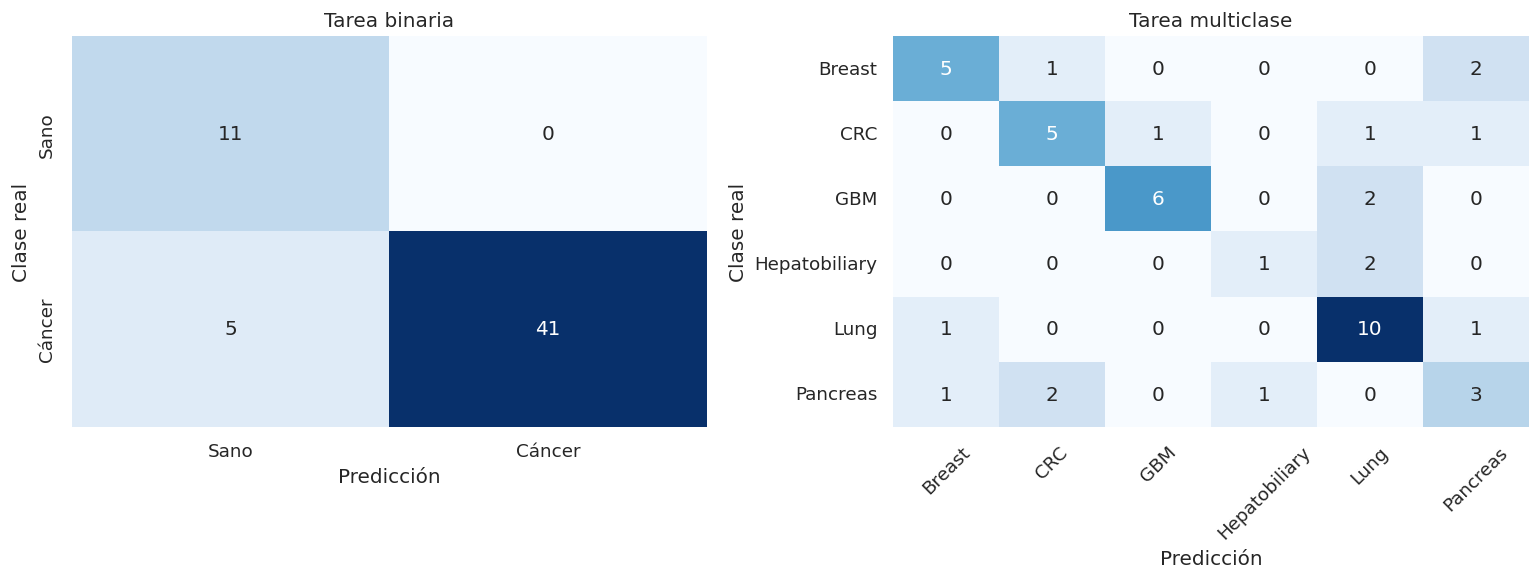

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

# Binaria
orden_bin = ["Sano", "Cáncer"]
matriz_bin = confusion_matrix(y_pru_bin, pred_bin, labels=orden_bin)
sns.heatmap(matriz_bin, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=orden_bin, yticklabels=orden_bin, ax=ejes[0])
ejes[0].set_title("Tarea binaria")
ejes[0].set_xlabel("Predicción"); ejes[0].set_ylabel("Clase real")

# Multiclase
orden_multi = ["Breast", "CRC", "GBM", "Hepatobiliary", "Lung", "Pancreas"]
matriz_multi = confusion_matrix(y_pru_multi, pred_multi, labels=orden_multi)
sns.heatmap(matriz_multi, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=orden_multi, yticklabels=orden_multi, ax=ejes[1])
ejes[1].set_title("Tarea multiclase")
ejes[1].set_xlabel("Predicción"); ejes[1].set_ylabel("Clase real")
ejes[1].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.show()

In [ ]:
reparto = pd.DataFrame({
    "muestras reales": y_pru_multi.value_counts(),
    "veces predicha": pd.Series(pred_multi).value_counts(),
}).reindex(orden_multi).fillna(0).astype(int)
reparto["aciertos"] = [matriz_multi[i, i] for i in range(len(orden_multi))]

print("Reparto de las predicciones en la tarea multiclase:\n")
print(reparto.to_string())

Reparto de las predicciones en la tarea multiclase:

               muestras reales  veces predicha  aciertos
Breast                       8               7         5
CRC                          8               8         5
GBM                          8               7         6
Hepatobiliary                3               2         1
Lung                        12              15        10
Pancreas                     7               7         3


La matriz de la tarea binaria muestra que el modelo elegido es muy preciso en los controles, ya que las 11 muestras de individuos sanos se clasifican todas correctamente, sin ningún falso positivo. Entre las 46 muestras tumorales, 41 se identifican bien y 5 se confunden con la clase sana.

Por tanto, los fallos se concentran en los falsos negativos, que en un contexto médico resultan más graves que los falsos positivos, aunque su número es reducido.

En la tarea multiclase, se aprecia que el cáncer de pulmón es la clase mejor identificada, con 10 aciertos de 12 muestras, seguido del glioblastoma con 6 de 8. Por su parte, los cánceres de mama y colorrectal aciertan 5 de 8 cada uno, mientras que los grupos de páncreas y hepatobiliar quedan por debajo, con 3 de 7 y 1 de 3 respectivamente.

El reparto de las predicciones ayuda a entender por qué el modelo está cometiendo errores. El cáncer de pulmón, además de ser la clase más numerosa, se predice 15 veces cuando solo tiene 12 muestras reales, de manera que causa algunos de los errores, algo habitual cuando una categoría domina el conjunto. En el extremo opuesto, las clases de menor tamaño y señal más débil, como la hepatobiliar, con solo 3 muestras, y el páncreas, con 7, se predicen con dificultad.

Esta relación entre el tamaño de cada clase y su tasa de acierto indica que la limitación principal está en la cantidad de muestras disponibles por tipo tumoral, más que en el comportamiento del modelo clasificador.

Ante estas predicciones, se debería de verificar si el criterio con que se seleccionó el modelo influye en el abandono de las clases minoritarias. La exactitud balanceada promedia las sensibilidades de todas las clases y podría, en principio, permitir que el modelo se concentrase en las clases más fáciles, mientras que la puntuación F1 macro, al combinar precisión y sensibilidad, penaliza más ese comportamiento.

Sin embargo, en la comparación de modelos con hiperparámetros ajustados los dos criterios seleccionaban la misma configuración: el modelo con mayor exactitud balanceada es también el de mayor F1 macro entre todos los algoritmos. Por tanto, cambiar de criterio no llevaría a un modelo distinto, de forma que el reparto de aciertos no se explica por la métrica usada para elegir.

En consecuencia, esta limitación es propia del problema, puesto que distinguir seis tipos de tumores a partir del perfil de ARN plaquetario, con clases que van de las 14 muestras de la hepatobiliar a las 60 del pulmón, es mucho más difícil que separar individuos sanos de enfermos, como ya mostraba el análisis de componentes principales al presentar los tipos mezclados. Es decir, la causa de los errores es muy probablemente la poca información disponible para cada clase, no el criterio de selección ni en el ajuste del clasificador (se comprobará la selección de genes en un apartado posterior para terminar la búsqueda de posibles causas).

### **Búsqueda de correcciones/mejoras en los modelos**

#### **Revisión del umbral de corte en la tarea binaria**

Un clasificador binario no decide directamente la clase, sino que estima la probabilidad de pertenecer a cada una y aplica después un punto de corte, fijado por defecto en 0,5. Ese valor no tiene por qué ser el óptimo.

El área bajo la curva obtenida (0,984) indica que el modelo ordena correctamente las muestras según su probabilidad de corresponder a un paciente con cáncer. Por tanto, la capacidad discriminativa es alta, y el margen de error se concentra en los falsos negativos, es decir, en casos de cáncer con probabilidad estimada por debajo del umbral por defecto.

El umbral se determina mediante validación cruzada sobre el conjunto de entrenamiento, sin usar las muestras reservadas para la evaluación. El criterio elegido es el índice de Youden, que maximiza la suma de sensibilidad y especificidad y localiza así el punto de mayor equilibrio entre ambas. Además, se informa del rendimiento alcanzado al fijar la especificidad en el 95% y en el 99%, no como alternativas al criterio anterior, sino para permitir el contraste con los estudios de referencia, que establecieron un límite máximo de falsos positivos y midieron qué detección era posible en esas condiciones.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

# Probabilidades estimadas sin que ninguna muestra intervenga en su propio modelo, de modo que el umbral se elige sin mirar el conjunto de prueba
flujo_umbral = construir_flujo(crear_modelo(mejor_bin["modelo"],
                                            mejor_bin["estrategia"]),
                               mejor_bin["estrategia"], k_binaria)
flujo_umbral.set_params(**mejor_bin["mejores_parametros"])

prob_cv = cross_val_predict(flujo_umbral, X_ent_bin, y_ent_bin,
                            cv=cv, method="predict_proba", n_jobs=-1)

# Columna correspondiente a la clase positiva
clases = np.unique(y_ent_bin)
columna_cancer = list(clases).index("Cáncer")
prob_cancer_cv = prob_cv[:, columna_cancer]
y_ent_binario = (y_ent_bin == "Cáncer").astype(int)

fpr, tpr, umbrales = roc_curve(y_ent_binario, prob_cancer_cv)
print(f"Puntos de corte evaluados: {len(umbrales)}")
print(f"AUC en validación cruzada: {roc_auc_score(y_ent_binario, prob_cancer_cv):.3f}")

Puntos de corte evaluados: 30
AUC en validación cruzada: 0.971


In [ ]:
especificidad = 1 - fpr
youden = tpr + especificidad - 1

# Criterio principal: máximo equilibrio entre sensibilidad y especificidad
i_youden = int(np.argmax(youden))
umbral_youden = umbrales[i_youden]

# Criterios adicionales: especificidad mínima fijada, como en los estudios de referencia
def umbral_con_especificidad(objetivo):
    validos = np.where(especificidad >= objetivo)[0]
    if len(validos) == 0:
        return None, None, None
    i = validos[np.argmax(tpr[validos])]   # mayor sensibilidad entre los válidos
    return umbrales[i], tpr[i], especificidad[i]

umbral_95, sens_95, esp_95 = umbral_con_especificidad(0.95)
umbral_99, sens_99, esp_99 = umbral_con_especificidad(0.99)

print("Umbrales estimados por validación cruzada sobre entrenamiento:\n")

pred_def_cv = (prob_cancer_cv >= 0.5).astype(int)
sens_def = np.sum((pred_def_cv == 1) & (y_ent_binario == 1)) / np.sum(y_ent_binario == 1)
esp_def = np.sum((pred_def_cv == 0) & (y_ent_binario == 0)) / np.sum(y_ent_binario == 0)
print(f"  Por defecto        0,500 | sensibilidad {sens_def:.3f} "
      f"| especificidad {esp_def:.3f}")
print(f"  Índice de Youden   {umbral_youden:.3f} | sensibilidad {tpr[i_youden]:.3f} "
      f"| especificidad {especificidad[i_youden]:.3f}")
if umbral_95:
    print(f"  Especificidad 95%  {umbral_95:.3f} | sensibilidad {sens_95:.3f} "
          f"| especificidad {esp_95:.3f}")
if umbral_99:
    print(f"  Especificidad 99%  {umbral_99:.3f} | sensibilidad {sens_99:.3f} "
          f"| especificidad {esp_99:.3f}")

Umbrales estimados por validación cruzada sobre entrenamiento:

  Por defecto        0,500 | sensibilidad 0.874 | especificidad 1.000
  Índice de Youden   0.375 | sensibilidad 0.891 | especificidad 1.000
  Especificidad 95%  0.322 | sensibilidad 0.902 | especificidad 0.977
  Especificidad 99%  0.375 | sensibilidad 0.891 | especificidad 1.000


La representación de la curva ROC permite situar visualmente los puntos de corte considerados y observar los errores cometidos.

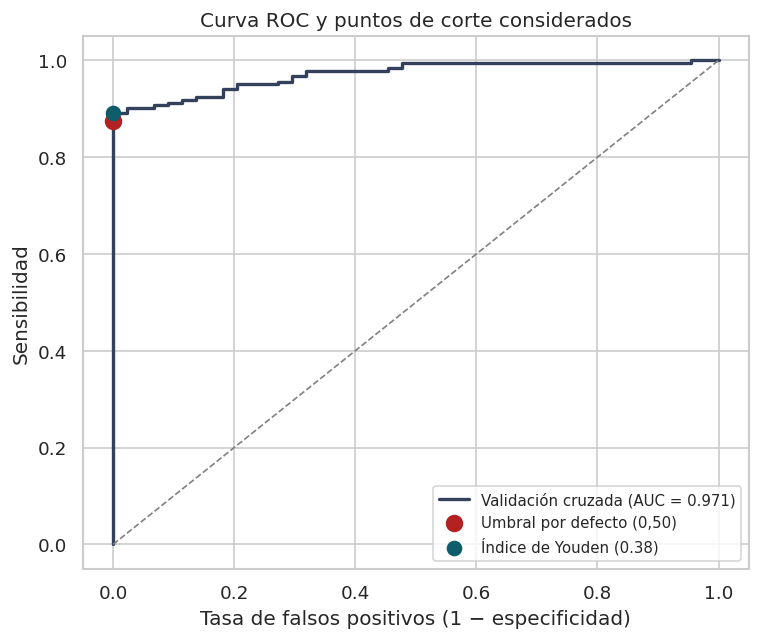

In [ ]:
plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, color=azul_oscuro, lw=2,
         label=f"Validación cruzada (AUC = {roc_auc_score(y_ent_binario, prob_cancer_cv):.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1)

pred_def_cv = (prob_cancer_cv >= 0.5).astype(int)
vn_d = np.sum((pred_def_cv == 0) & (y_ent_binario == 0))
fp_d = np.sum((pred_def_cv == 1) & (y_ent_binario == 0))
vp_d = np.sum((pred_def_cv == 1) & (y_ent_binario == 1))
fn_d = np.sum((pred_def_cv == 0) & (y_ent_binario == 1))
fpr_def = fp_d / (fp_d + vn_d)
tpr_def = vp_d / (vp_d + fn_d)
plt.scatter(fpr_def, tpr_def, color="firebrick", s=90, zorder=4,
            label="Umbral por defecto (0,50)")

plt.scatter(fpr[i_youden], tpr[i_youden], color=verde_azulado, s=70, zorder=5,
            label=f"Índice de Youden ({umbral_youden:.2f})")

plt.xlabel("Tasa de falsos positivos (1 − especificidad)")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC y puntos de corte considerados")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

Determinado el punto de corte sobre el conjunto de entrenamiento, se aplica a las muestras reservadas. Aunque el umbral se ha calculado sin usar el conjunto de prueba, la decisión de revisarlo se tomó después de observar el comportamiento del modelo, de modo que no es una evaluación completamente independiente.

La siguiente tabla guarda el rendimiento obtenido con cada punto de corte. El umbral por defecto de 0,5 aporta el resultado confirmatorio, mientras que el correspondiente al índice de Youden se muestra como análisis exploratorio o post hoc. Los umbrales de especificidad fija se incluyen únicamente como información complementaria, y su interpretación debe hacerse con cuidado, ya que con 11 controles sanos en el conjunto de prueba, cada falso positivo modifica la especificidad considerablemente.

In [ ]:
prob_cancer_pru = prob_bin[:, list(flujo_bin.classes_).index("Cáncer")]
y_pru_binario = (y_pru_bin == "Cáncer").astype(int)

def evaluar_umbral(umbral, nombre):
    prediccion = np.where(prob_cancer_pru >= umbral, "Cáncer", "Sano")
    matriz = confusion_matrix(y_pru_bin, prediccion, labels=["Sano", "Cáncer"])
    vn, fp, fn, vp = matriz.ravel()
    return {
        "criterio": nombre,
        "umbral": umbral,
        "exactitud_balanceada": balanced_accuracy_score(y_pru_bin, prediccion),
        "sensibilidad": vp / (vp + fn),
        "especificidad": vn / (vn + fp),
        "f1_macro": f1_score(y_pru_bin, prediccion, average="macro"),
        "falsos_negativos": int(fn),
        "falsos_positivos": int(fp),
    }

filas = [evaluar_umbral(0.5, "por defecto"),
         evaluar_umbral(umbral_youden, "índice de Youden")]
if umbral_95:
    filas.append(evaluar_umbral(umbral_95, "especificidad 95%"))
if umbral_99:
    filas.append(evaluar_umbral(umbral_99, "especificidad 99%"))

tabla_umbral = pd.DataFrame(filas)
tabla_umbral["papel"] = ["PRINCIPAL (confirmatorio)", "exploratorio"] + \
                        ["contraste"] * (len(filas) - 2)

print("Rendimiento sobre el conjunto de prueba según el umbral:\n")
print(tabla_umbral.round(3).to_string(index=False))

Rendimiento sobre el conjunto de prueba según el umbral:

         criterio  umbral  exactitud_balanceada  sensibilidad  especificidad  f1_macro  falsos_negativos  falsos_positivos                     papel
      por defecto   0.500                 0.946         0.891            1.0     0.879                 5                 0 PRINCIPAL (confirmatorio)
 índice de Youden   0.375                 0.957         0.913            1.0     0.900                 4                 0              exploratorio
especificidad 95%   0.322                 0.957         0.913            1.0     0.900                 4                 0                 contraste
especificidad 99%   0.375                 0.957         0.913            1.0     0.900                 4                 0                 contraste


El área bajo la curva estimada por validación cruzada se queda en 0,971, lo que confirma que el modelo ordena las muestras con mucha precisión según su probabilidad de corresponder a un paciente con cáncer. Sobre esa ordenación, el índice de Youden localiza el umbral de mayor equilibrio entre sensibilidad y especificidad, que se sitúa en 0,375, por debajo del valor por defecto.

El efecto de ese umbral se observa en el entrenamiento, dado que en validación cruzada, bajar el corte de 0,5 a 0,375 aumenta la sensibilidad de 0,874 a 0,891, es decir, recupera 3 casos de cáncer que quedaban por debajo del umbral por defecto, sin que la especificidad deje de ser 1. Por tanto, el hecho de bajar el umbral no genera falsos positivos y solo sirve para poder predecir correctamente más casos de cáncer.

Ese mismo comportamiento aparece sobre el conjunto de prueba; con el umbral de Youden la exactitud balanceada pasa de 0,946 a 0,957 y la puntuación F1 de 0,879 a 0,900, al recuperar uno de los casos de cáncer no detectados con el umbral por defecto, mientras la especificidad se sigue manteniendo en 1.

Como la mejora se mantiene tanto en entrenamiento como en prueba, se puede decir que un umbral más bajo se adapta mejor a estos datos y no es un resultado puntual de un solo conjunto.

Sin embargo, su alcance se debe interpretar con cuidado, puesto que la ganancia en prueba se apoya en una sola muestra, y la decisión de revisar el umbral se tomó después de observar el comportamiento del modelo. Por esa razón, el umbral por defecto de 0,5 se conserva como resultado confirmatorio y el de Youden se presenta como análisis exploratorio que apunta en la misma dirección, no como evaluación independiente.

Los umbrales de especificidad fija, incluidos para el contraste con la literatura, casi no añaden diferencias en este caso, ya que el modelo alcanza una especificidad del 100% incluso con el umbral por defecto. Al exigir una especificidad del 99%, el punto de corte coincide con el de Youden, con una sensibilidad de 0,913. Este comportamiento va en la línea de lo observado por Jopek et al. (2024), que en condiciones de alta especificidad consiguieron una detección cercana al 68%, aunque la comparación debe hacerse con cuidado por el tamaño reducido del conjunto de evaluación y las diferencias entre ambos estudios.

El modelo elegido para la tarea binaria es la regresión logística sin corrección del desbalance, con un parámetro de regularización de 0,1 y penalización L2. Con el umbral por defecto de 0,5 consigue, sobre el conjunto de prueba, una exactitud balanceada de 0,946 y un AUC de 0,984, que se toman como resultado confirmatorio principal por no depender de ninguna decisión posterior a la prueba. Con ese umbral no comete ningún falso positivo y deja sin detectar 5 de los 46 casos de cáncer.

Como análisis exploratorio, el umbral de 0,375 estimado por el índice de Youden sobre el entrenamiento sube la exactitud balanceada a 0,957, al recuperar uno de esos falsos negativos sin introducir ningún falso positivo. Esta revisión, coherente tanto en validación cruzada como en prueba, como ya se ha comentado, se conserva como complemento del análisis para confirmar la solidez del modelo, mientras que la elección definitiva se mantiene en el umbral por defecto, fijado antes de conocer el resultado de la evaluación.

In [ ]:
# Modelo definitivo de la tarea binaria
pred_bin_confirmatorio = pred_bin
umbral_final_bin = umbral_youden
pred_bin_youden = np.where(prob_cancer_pru >= umbral_final_bin, "Cáncer", "Sano")

In [ ]:
from sklearn.metrics import accuracy_score

print("RESULTADO CONFIRMATORIO - tarea binaria (umbral por defecto 0,5)\n")
print(f"Exactitud simple:      {accuracy_score(y_pru_bin, pred_bin_confirmatorio):.3f}")
print(f"Exactitud balanceada:  {balanced_accuracy_score(y_pru_bin, pred_bin_confirmatorio):.3f}")
print(f"AUC:                   {roc_auc_score(y_pru_binario, prob_cancer_pru):.3f}")
print(f"F1 macro:              {f1_score(y_pru_bin, pred_bin_confirmatorio, average='macro'):.3f}\n")

print(classification_report(y_pru_bin, pred_bin_confirmatorio, digits=3, zero_division=0))

matriz_conf = confusion_matrix(y_pru_bin, pred_bin_confirmatorio, labels=["Sano", "Cáncer"])
print("Matriz de confusión (filas: real, columnas: predicho):")
print(pd.DataFrame(matriz_conf, index=["Sano", "Cáncer"],
                   columns=["Sano", "Cáncer"]).to_string())

print("\n" + "="*60)
print("ANÁLISIS EXPLORATORIO POST HOC - umbral de Youden (0,375)\n")
print(f"Exactitud balanceada:  {balanced_accuracy_score(y_pru_bin, pred_bin_youden):.3f}")
print(f"F1 macro:              {f1_score(y_pru_bin, pred_bin_youden, average='macro'):.3f}\n")

matriz_youden = confusion_matrix(y_pru_bin, pred_bin_youden, labels=["Sano", "Cáncer"])
print("Matriz de confusión con el umbral de Youden (filas: real, columnas: predicho):")
print(pd.DataFrame(matriz_youden, index=["Sano", "Cáncer"],
                   columns=["Sano", "Cáncer"]).to_string())

RESULTADO CONFIRMATORIO - tarea binaria (umbral por defecto 0,5)

Exactitud simple:      0.912
Exactitud balanceada:  0.946
AUC:                   0.984
F1 macro:              0.879

              precision    recall  f1-score   support

      Cáncer      1.000     0.891     0.943        46
        Sano      0.688     1.000     0.815        11

    accuracy                          0.912        57
   macro avg      0.844     0.946     0.879        57
weighted avg      0.940     0.912     0.918        57

Matriz de confusión (filas: real, columnas: predicho):
        Sano  Cáncer
Sano      11       0
Cáncer     5      41

ANÁLISIS EXPLORATORIO POST HOC - umbral de Youden (0,375)

Exactitud balanceada:  0.957
F1 macro:              0.900

Matriz de confusión con el umbral de Youden (filas: real, columnas: predicho):
        Sano  Cáncer
Sano      11       0
Cáncer     4      42


#### **Revisión de la selección de genes en la tarea multiclase**

Una vez que se ha descartado que el criterio de selección o el ajuste del modelo expliquen el comportamiento en la tarea multiclase, se debe analizar un elemento anterior del proceso: los genes con los que trabaja el modelo y la información que aportan para distinguir cada tipo de tumor.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class SeleccionPorClase(BaseEstimator, TransformerMixin):
    """Selecciona los mejores genes de cada clase frente al resto y los une.
    Garantiza que toda categoría aporte variables, independientemente de su tamaño."""

    def __init__(self, genes_por_clase=200):
        self.genes_por_clase = genes_por_clase

    def fit(self, X, y):
        X_matriz = np.asarray(X)
        seleccionados = set()
        for clase in np.unique(y):
            binaria = (np.asarray(y) == clase).astype(int)
            puntuaciones, _ = f_classif(X_matriz, binaria)
            puntuaciones = np.nan_to_num(puntuaciones, nan=-np.inf)
            mejores = np.argsort(puntuaciones)[::-1][:self.genes_por_clase]
            seleccionados.update(mejores.tolist())
        self.indices_ = np.array(sorted(seleccionados))
        return self

    def transform(self, X):
        return np.asarray(X)[:, self.indices_]

def construir_flujo_por_clase(modelo, estrategia, genes_por_clase):
    "Igual que el flujo habitual, pero con selección por clase."
    pasos = [("filtrado", FiltroNormalizacion(umbral_cpm=1, min_muestras=14)),
             ("escalado", StandardScaler()),
             ("seleccion", SeleccionPorClase(genes_por_clase))]
    if estrategia == "smote":
        pasos.append(("remuestreo", SMOTE(random_state=semilla, k_neighbors=5)))
    pasos.append(("modelo", modelo))
    return PipelineDesbalance(pasos)

La búsqueda analiza tanto el número de genes que aporta cada clase como el parámetro de regularización, ya que ambos interactúan. Un conjunto de variables más amplio suele requerir una penalización mayor.

Como criterio de selección se utiliza la puntuación F1 macro, que combina precisión y sensibilidad de cada clase y es la más adecuada aquí, donde el objetivo es comprobar si mejora el reconocimiento de las categorías minoritarias.

In [ ]:
metricas_revision = {
    "exactitud_balanceada": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "precision": "precision_macro",
    "sensibilidad": "recall_macro",
    "auc": "roc_auc_ovr",
}

rejilla_por_clase = {
    "seleccion__genes_por_clase": [50, 100, 200, 400],
    "modelo__C": [0.01, 0.1, 1, 10],
    "modelo__penalty": ["l2"],
}

resultados_clase = []
for estrategia in ["ninguna", "smote"]:
    flujo = construir_flujo_por_clase(
        crear_modelo("regresion_logistica", estrategia), estrategia, 200)
    busqueda = GridSearchCV(flujo, rejilla_por_clase, cv=cv,
                            scoring=metricas_revision, refit="f1_macro",
                            n_jobs=-1)
    busqueda.fit(X_ent_multi, y_ent_multi)

    i = busqueda.best_index_
    registro = {"estrategia": estrategia,
                "genes_por_clase": busqueda.best_params_["seleccion__genes_por_clase"],
                "C": busqueda.best_params_["modelo__C"]}
    for m in metricas_revision:
        registro[m] = busqueda.cv_results_[f"mean_test_{m}"][i]
    resultados_clase.append(registro)
    print(f"  {estrategia:10s} genes/clase = {registro['genes_por_clase']:<4} "
          f"C = {registro['C']:<6} F1 macro = {registro['f1_macro']:.3f}")

seleccion_clase = pd.DataFrame(resultados_clase)

  ninguna    genes/clase = 400  C = 10     F1 macro = 0.580
  smote      genes/clase = 200  C = 1      F1 macro = 0.611


Una vez que se tienen las dos selecciones de genes nuevas, se comparan con el modelo obtenido mediante la selección univariante global, para comprobar si la selección por clase aporta alguna mejora en validación cruzada antes de evaluarla sobre el conjunto de prueba.

In [ ]:
comparacion_cv = pd.DataFrame([
    {"selección": "univariante global (1000 genes)",
     "f1_macro": mejor_multi["f1_macro"],
     "exactitud_balanceada": mejor_multi["exactitud_balanceada"],
     "precision": mejor_multi["precision"]},
    *[{"selección": f"por clase ({f['genes_por_clase']}/clase) - {f['estrategia']}",
       "f1_macro": f["f1_macro"],
       "exactitud_balanceada": f["exactitud_balanceada"],
       "precision": f["precision"]}
      for _, f in seleccion_clase.iterrows()],
])
print("Validación cruzada sobre el conjunto de entrenamiento:\n")
print(comparacion_cv.round(3).to_string(index=False))

Validación cruzada sobre el conjunto de entrenamiento:

                      selección  f1_macro  exactitud_balanceada  precision
univariante global (1000 genes)     0.585                 0.599      0.636
por clase (400/clase) - ninguna     0.580                 0.592      0.609
  por clase (200/clase) - smote     0.611                 0.614      0.681


In [ ]:
mejor_clase = seleccion_clase.sort_values("f1_macro", ascending=False).iloc[0]
print(f"Mejor selección por clase: {mejor_clase['estrategia']} "
      f"({int(mejor_clase['genes_por_clase'])} genes/clase, C = {mejor_clase['C']})\n")

flujo_pc = construir_flujo_por_clase(
    crear_modelo("regresion_logistica", mejor_clase["estrategia"]),
    mejor_clase["estrategia"], int(mejor_clase["genes_por_clase"]))
flujo_pc.set_params(modelo__C=mejor_clase["C"], modelo__penalty="l2")
flujo_pc.fit(X_ent_multi, y_ent_multi)

pred_pc = flujo_pc.predict(X_pru_multi)
prob_pc = flujo_pc.predict_proba(X_pru_multi)

met_pc = {
    "exactitud_balanceada": balanced_accuracy_score(y_pru_multi, pred_pc),
    "f1_macro": f1_score(y_pru_multi, pred_pc, average="macro"),
    "precision": precision_score(y_pru_multi, pred_pc, average="macro", zero_division=0),
    "sensibilidad": recall_score(y_pru_multi, pred_pc, average="macro"),
    "auc": roc_auc_score(y_pru_multi, prob_pc, multi_class="ovr",
                         average="macro", labels=flujo_pc.classes_),
}

print("Conjunto de prueba:\n")
print(pd.DataFrame([{"modelo": "selección univariante global", **met_multi},
                    {"modelo": "selección por clase", **met_pc}]
                   ).round(3).to_string(index=False))

print(f"\nGenes seleccionados en total: {len(flujo_pc.named_steps['seleccion'].indices_)}")

Mejor selección por clase: smote (200 genes/clase, C = 1)

Conjunto de prueba:

                      modelo  exactitud_balanceada  f1_macro  precision  sensibilidad   auc
selección univariante global                 0.599     0.610      0.632         0.599 0.822
         selección por clase                 0.544     0.574      0.691         0.544 0.865

Genes seleccionados en total: 1090


La selección por clase mejora los resultados en validación cruzada, donde su mejor configuración, con 200 genes por categoría y remuestreo mediante SMOTE, consigue una puntuación F1 macro de 0,611 frente al 0,585 del modelo con selección univariante global. Sin embargo, esa ventaja no se traslada al conjunto de prueba, donde obtiene una F1 macro de 0,574 y una exactitud balanceada de 0,544 frente a 0,610 y 0,599 del modelo original, de forma que la mejora observada en el entrenamiento no se confirma sobre datos nuevos.

Se aprecia que la búsqueda selecciona el segundo valor más alto de genes por clase de los explorados (200), lo que eleva el total de genes a algo más de 1000, superando el número de la selección global.

Según el criterio escogido, el modelo seleccionado sigue siendo el obtenido con la selección univariante global. Aun así, se estudia la matriz de confusión del nuevo modelo para comprobar cómo redistribuye sus predicciones.

Reparto de las predicciones:

               reales  predicha (global)  aciertos (global)  predicha (por clase)  aciertos (por clase)
Breast              8                  7                  5                     6                     4
CRC                 8                  8                  5                    12                     5
GBM                 8                  7                  6                     5                     5
Hepatobiliary       3                  2                  1                     1                     1
Lung               12                 15                 10                    16                     9
Pancreas            7                  7                  3                     6                     3


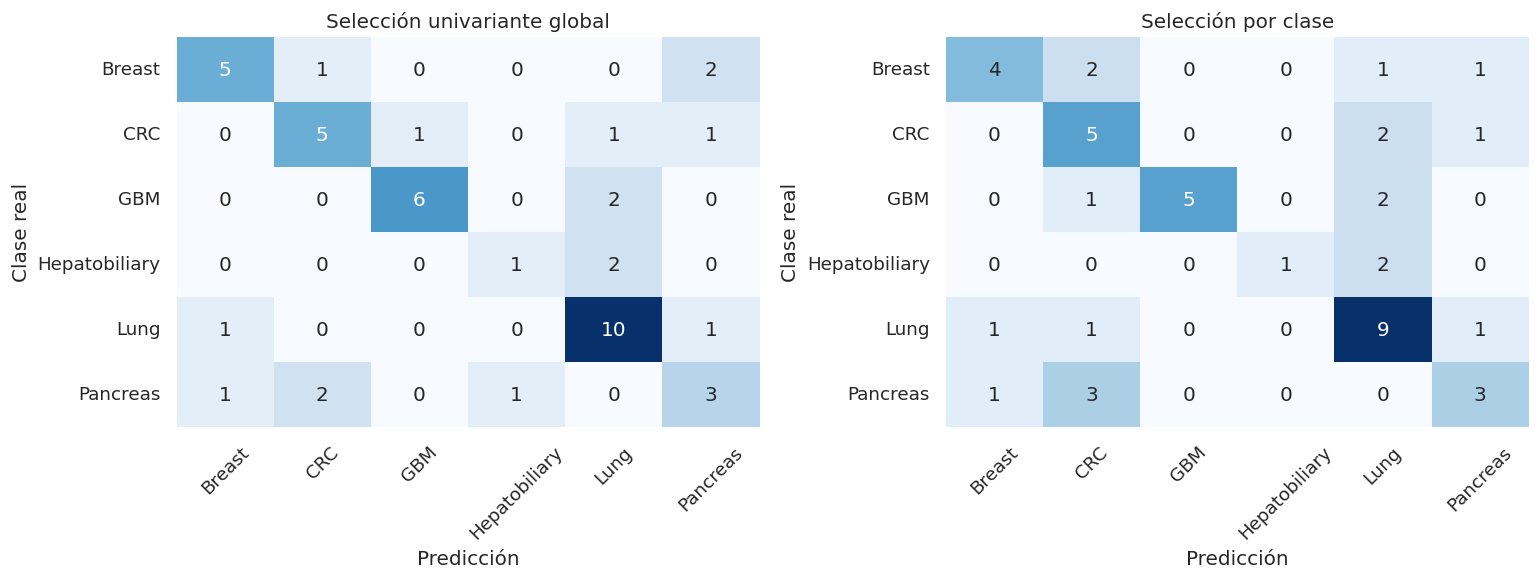


Detalle por clase del modelo con selección por clase:

               precision    recall  f1-score   support

       Breast      0.667     0.500     0.571         8
          CRC      0.417     0.625     0.500         8
          GBM      1.000     0.625     0.769         8
Hepatobiliary      1.000     0.333     0.500         3
         Lung      0.562     0.750     0.643        12
     Pancreas      0.500     0.429     0.462         7

     accuracy                          0.587        46
    macro avg      0.691     0.544     0.574        46
 weighted avg      0.650     0.587     0.591        46



In [ ]:
orden_multi = ["Breast", "CRC", "GBM", "Hepatobiliary", "Lung", "Pancreas"]
matriz_ori = confusion_matrix(y_pru_multi, pred_multi, labels=orden_multi)
matriz_pc = confusion_matrix(y_pru_multi, pred_pc, labels=orden_multi)

reparto = pd.DataFrame({
    "reales": y_pru_multi.value_counts(),
    "predicha (global)": pd.Series(pred_multi).value_counts(),
    "aciertos (global)": pd.Series([matriz_ori[i, i] for i in range(6)], index=orden_multi),
    "predicha (por clase)": pd.Series(pred_pc).value_counts(),
    "aciertos (por clase)": pd.Series([matriz_pc[i, i] for i in range(6)], index=orden_multi),
}).reindex(orden_multi).fillna(0).astype(int)

print("Reparto de las predicciones:\n")
print(reparto.to_string())

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for eje, (titulo, matriz) in zip(ejes, [("Selección univariante global", matriz_ori),
                                        ("Selección por clase", matriz_pc)]):
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=orden_multi, yticklabels=orden_multi, ax=eje)
    eje.set_title(titulo)
    eje.set_xlabel("Predicción"); eje.set_ylabel("Clase real")
    eje.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print("\nDetalle por clase del modelo con selección por clase:\n")
print(classification_report(y_pru_multi, pred_pc, digits=3, zero_division=0))

El comportamiento sobre el conjunto de prueba enseña el cambio. El reparto de las predicciones se vuelve algo más disperso: el cáncer de pulmón pasa de recibir 15 predicciones a 16 y el CRC de 8 a 12, pero esa redistribución no se traduce en nuevos aciertos, ya que el de CRC mantiene sus 5 aciertos y el de pulmón pierde uno.

Por tanto, el cambio se produce a costa de las categorías que antes se resolvían mejor.

Si se aprecia el conjunto entero de datos, el modelo con selección univariante global clasifica correctamente 30 de las 46 muestras y el de selección por clase 27. Esto significa que el modelo de este apartado no aprende a reconocer las clases minoritarias, sino que reparte sus predicciones de forma más homogénea, sin ganar aciertos en las categorías difíciles y perdiéndolos en las que antes resolvía bien. Cualquier variación en la puntuación F1 macro muestra ese reparto más repartido, no una mayor capacidad discriminativa.

Después de haber investigado tanto el criterio de selección del modelo como el procedimiento de elección de genes, puede afirmarse que ninguno de los dos explica el comportamiento observado en la tarea multiclase.

La dificultad entonces se encuentra en que los perfiles de ARN plaquetario disponibles no contienen señal suficiente para separar correctamente el cáncer de páncreas y el carcinoma hepatobiliar del resto de categorías, al menos con 28 y 11 muestras de entrenamiento respectivamente.

Por tanto, el modelo multiclase final queda así:

In [ ]:
print("MODELO MULTICLASE DEFINITIVO (selección univariante global)\n")
print(f"Exactitud simple:      {accuracy_score(y_pru_multi, pred_multi):.3f}")
print(f"Exactitud balanceada:  {balanced_accuracy_score(y_pru_multi, pred_multi):.3f}")
print(f"F1 macro:              {f1_score(y_pru_multi, pred_multi, average='macro'):.3f}")
print(f"AUC (uno contra resto):{roc_auc_score(y_pru_multi, prob_multi, multi_class='ovr', average='macro', labels=flujo_multi.classes_):.3f}\n")

# Cifra orientativa para el contraste con Jopek et al. (2024), que clasifica cinco tipos tumorales.
# La comparación es solo aproximada, ya que los conjuntos de datos, el número de clases y los protocolos difieren entre ambos trabajos.
sin_hepato = y_pru_multi != "Hepatobiliary"
print("Restringido a las cinco clases con mayor representación "
      "(se excluye el grupo hepatobiliar, ausente en el estudio de referencia):")
print(f"  muestras evaluadas: {sin_hepato.sum()}")
print(f"  exactitud simple:   {accuracy_score(y_pru_multi[sin_hepato], pred_multi[sin_hepato]):.3f}")

MODELO MULTICLASE DEFINITIVO (selección univariante global)

Exactitud simple:      0.652
Exactitud balanceada:  0.599
F1 macro:              0.610
AUC (uno contra resto):0.822

Restringido a las cinco clases con mayor representación (se excluye el grupo hepatobiliar, ausente en el estudio de referencia):
  muestras evaluadas: 43
  exactitud simple:   0.674


### **Estabilidad de los resultados frente al reparto**

La evaluación se ha realizado sobre una única división de los datos. Sin embargo, como los tamaños resultantes son reducidos (57 muestras en la tarea binaria y 46 en la multiclase, con categorías que apenas alcanzan las tres), un solo acierto o error modifica las métricas de forma apreciable.

Por tanto, para comprobar la robustez del modelo, es bueno repetir el proceso completo con distintas particiones aleatorias, calculando la media y la dispersión de las métricas resultantes.

La finalidad no es seleccionar la partición más favorable, sino conocer el margen de incertidumbre que acompaña a los valores obtenidos. Los modelos y sus hiperparámetros se mantienen fijos en la configuración ya seleccionada, de modo que la única variación sea el reparto de las muestras.

In [ ]:
def repetir_con_semillas(X_completo, y_completo, fila_modelo, k_genes,
                         multiclase, umbral=None, n_repeticiones=20):
    """Repite partición, entrenamiento y evaluación con distintas semillas.
    El modelo y sus hiperparámetros permanecen fijos; solo cambia el reparto."""
    resultados = []
    for repeticion in range(n_repeticiones):
        semilla_rep = semilla + repeticion

        X_ent, X_pru, y_ent, y_pru = train_test_split(
            X_completo, y_completo, test_size=0.20,
            stratify=y_completo, random_state=semilla_rep)

        flujo = construir_flujo(crear_modelo(fila_modelo["modelo"],
                                             fila_modelo["estrategia"]),
                                fila_modelo["estrategia"], k_genes)
        flujo.set_params(**fila_modelo["mejores_parametros"])
        flujo.fit(X_ent, y_ent)

        probabilidad = flujo.predict_proba(X_pru)
        if multiclase:
            prediccion = flujo.predict(X_pru)
            auc = roc_auc_score(y_pru, probabilidad, multi_class="ovr",
                                average="macro", labels=flujo.classes_)
        else:
            columna = list(flujo.classes_).index("Cáncer")
            corte = umbral if umbral is not None else 0.5
            prediccion = np.where(probabilidad[:, columna] >= corte, "Cáncer", "Sano")
            auc = roc_auc_score((y_pru == "Cáncer").astype(int),
                                probabilidad[:, columna])

        resultados.append({
            "repeticion": repeticion,
            "exactitud": accuracy_score(y_pru, prediccion),
            "exactitud_balanceada": balanced_accuracy_score(y_pru, prediccion),
            "f1_macro": f1_score(y_pru, prediccion, average="macro"),
            "auc": auc,
        })
    return pd.DataFrame(resultados)

# La tarea binaria se evalúa con el umbral por defecto (0,5), que es el resultado confirmatorio; el modelo y sus hiperparámetros se mantienen fijos
estabilidad_bin = repetir_con_semillas(X, y_binaria, mejor_bin, k_binaria,
                                       multiclase=False, umbral=0.5)

estabilidad_multi = repetir_con_semillas(X_multiclase, y_multiclase, mejor_multi,
                                         k_multiclase, multiclase=True)

print("Se han repetido ambas tareas con distintas semillas.")

Se han repetido ambas tareas con distintas semillas.


El resumen recoge, junto a la media y la desviación típica de cada métrica, el rango de valores observado y el resultado correspondiente a la partición empleada en los apartados anteriores, lo que permite situarlo dentro de la distribución.

In [ ]:
def resumir(tabla, valores_originales, nombre):
    metricas = ["exactitud", "exactitud_balanceada", "f1_macro", "auc"]
    resumen = pd.DataFrame({
        "media": tabla[metricas].mean(),
        "desviación": tabla[metricas].std(),
        "mínimo": tabla[metricas].min(),
        "máximo": tabla[metricas].max(),
        "partición original": pd.Series(valores_originales),
    })
    print(f"{nombre} ({len(tabla)} repeticiones)\n")
    print(resumen.round(3).to_string(), "\n")
    return resumen

originales_bin = {
    "exactitud": accuracy_score(y_pru_bin, pred_bin_confirmatorio),
    "exactitud_balanceada": balanced_accuracy_score(y_pru_bin, pred_bin_confirmatorio),
    "f1_macro": f1_score(y_pru_bin, pred_bin_confirmatorio, average="macro"),
    "auc": roc_auc_score(y_pru_binario, prob_cancer_pru),
}
originales_multi = {
    "exactitud": accuracy_score(y_pru_multi, pred_multi),
    "exactitud_balanceada": met_multi["exactitud_balanceada"],
    "f1_macro": met_multi["f1_macro"],
    "auc": met_multi["auc"],
}

resumen_bin = resumir(estabilidad_bin, originales_bin, "TAREA BINARIA")
resumen_multi = resumir(estabilidad_multi, originales_multi, "TAREA MULTICLASE")

TAREA BINARIA (20 repeticiones)

                      media  desviación  mínimo  máximo  partición original
exactitud             0.898       0.060   0.789   0.982               0.912
exactitud_balanceada  0.911       0.065   0.731   0.978               0.946
f1_macro              0.860       0.077   0.701   0.971               0.879
auc                   0.971       0.028   0.893   0.998               0.984 

TAREA MULTICLASE (20 repeticiones)

                      media  desviación  mínimo  máximo  partición original
exactitud             0.605       0.068   0.457   0.717               0.652
exactitud_balanceada  0.577       0.065   0.445   0.676               0.599
f1_macro              0.565       0.076   0.389   0.681               0.610
auc                   0.840       0.037   0.751   0.896               0.822 



La variabilidad entre particiones es considerable en ambas tareas.
- En la binaria, la exactitud balanceada oscila entre 0,731 y 0,978 según el reparto, con una media de 0,911 y una desviación típica de 0,065. El área bajo la curva es más estable, con una media de 0,971 y valores que no bajan de 0,893, lo que indica que la capacidad de ordenación del modelo se mantiene aunque el reparto concreto de aciertos varíe. El resultado de la partición empleada, 0,946 de exactitud balanceada y 0,984 de área bajo la curva, se coloca en la zona alta de la distribución, por encima de la media pero dentro del rango observado, de manera que se trata de un reparto algo favorable.

- En la multiclase, la exactitud balanceada varía entre 0,445 y 0,676, con una media de 0,577 y una desviación típica de 0,065. El resultado de la partición empleada, 0,599, queda muy cerca de esa media, lo que confirma que la evaluación no se apoya en un reparto atípico. La amplitud del rango muestra la dificultad de la tarea con clases tan pequeñas, donde el acierto o error en unas pocas muestras minoritarias modifica notablemente las métricas.

Ningún valor concreto puede considerarse una estimación precisa del rendimiento, sino un punto dentro de una distribución relativamente amplia.

La representación gráfica de la distribución permite apreciar la amplitud de la variación y comprobar como el valor obtenido con la partición original se sitúa en una posición central o extrema.

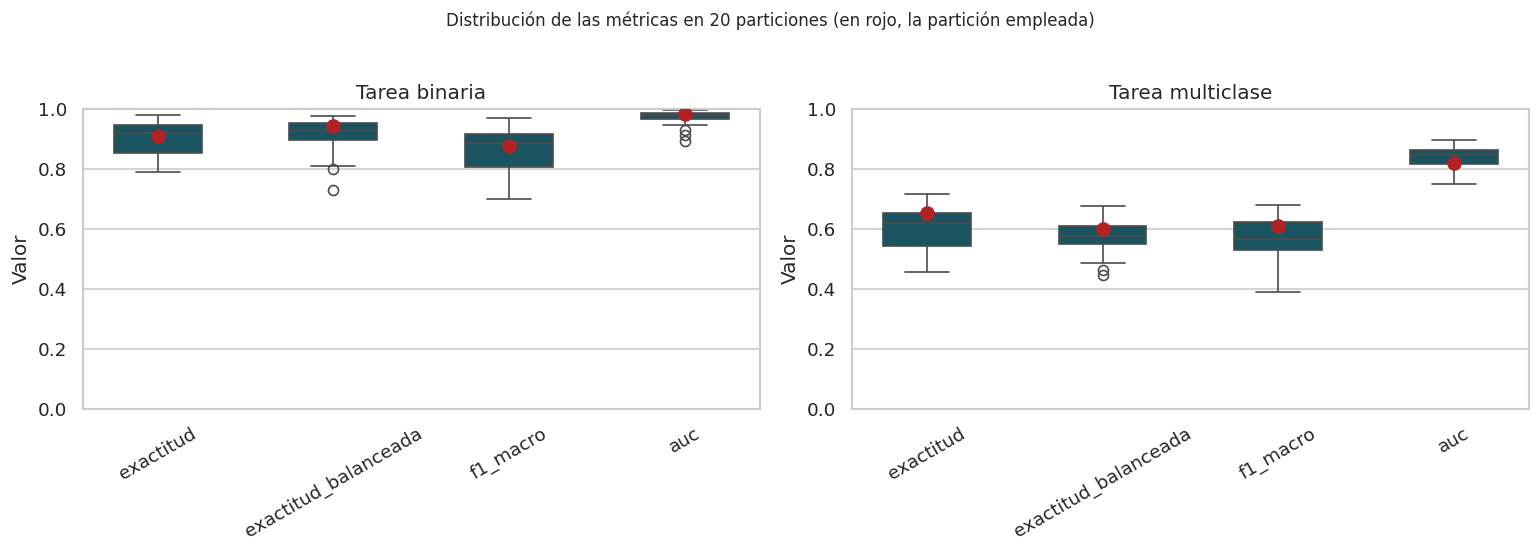

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
metricas = ["exactitud", "exactitud_balanceada", "f1_macro", "auc"]

for eje, (titulo, tabla, originales) in zip(
        ejes, [("Tarea binaria", estabilidad_bin, originales_bin),
               ("Tarea multiclase", estabilidad_multi, originales_multi)]):
    sns.boxplot(data=tabla[metricas], color=verde_azulado, ax=eje, width=0.5)
    for i, m in enumerate(metricas):
        eje.scatter(i, originales[m], color="firebrick", s=60, zorder=5)
    eje.set_title(titulo)
    eje.set_ylabel("Valor")
    eje.set_ylim(0, 1)
    eje.tick_params(axis="x", rotation=30)

plt.suptitle("Distribución de las métricas en 20 particiones "
             "(en rojo, la partición empleada)", y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Con clases de pocas muestras, se debe comprobar cuántas veces quedan sin aciertos
sin_aciertos = {clase: 0 for clase in orden_multi}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")          # evita el aviso de genes constantes en algún pliegue
    for repeticion in range(20):
        semilla_rep = semilla + repeticion
        X_ent, X_pru, y_ent, y_pru = train_test_split(
            X_multiclase, y_multiclase,
            test_size=0.20, stratify=y_multiclase,
            random_state=semilla_rep)

        flujo = construir_flujo(crear_modelo(mejor_multi["modelo"],
                                             mejor_multi["estrategia"]),
                                mejor_multi["estrategia"], k_multiclase)
        flujo.set_params(**mejor_multi["mejores_parametros"])
        flujo.fit(X_ent, y_ent)
        prediccion = flujo.predict(X_pru)

        matriz = confusion_matrix(y_pru, prediccion, labels=orden_multi)
        for i, clase in enumerate(orden_multi):
            if matriz[i].sum() > 0 and matriz[i, i] == 0:
                sin_aciertos[clase] += 1

print("Número de particiones (de 20) en que cada clase no obtiene ningún acierto:\n")
for clase, veces in sin_aciertos.items():
    print(f"  {clase:15s} {veces:2d}")

Número de particiones (de 20) en que cada clase no obtiene ningún acierto:

  Breast           0
  CRC              0
  GBM              0
  Hepatobiliary    7
  Lung             0
  Pancreas         0


La posición de la partición utilizada se comporta de forma distinta en cada tarea. En la binaria se coloca por encima de la media, con una exactitud balanceada de 0,946 frente a una media de 0,911, aunque dentro del rango observado. En la multiclase coincide casi con la media, con 0,599 frente a 0,577, de manera que en ambos casos los resultados comunicados son representativos.

El recuento de aciertos por clase a lo largo de las 20 particiones completa el estudio sobre las categorías difíciles. Aquí, el cáncer de páncreas no se queda sin aciertos en ninguna de las 20 particiones, de manera que, a pesar de sus pocas muestras, el modelo es capaz de reconocer esa categoría. En cambio, el carcinoma hepatobiliar presenta un problema real: se queda sin ningún acierto en 7 de las 20 particiones, más de una tercera parte, lo que resulta coherente ya que únicamente hay 11 muestras de entrenamiento y 3 de evaluación. Por tanto, las métricas de esa categoría carecen de fiabilidad con los datos disponibles, y es la única clase de la que puede afirmarse que la señal es insuficiente.

El área bajo la curva es la métrica más estable en ambas tareas, con desviaciones típicas de 0,028 y 0,037 respectivamente. Su cálculo no depende de un umbral de decisión ni de la asignación concreta de clases, sino de la ordenación de las muestras según su probabilidad estimada, lo que la hace menos sensible al reparto. Es, por ello, la métrica más sólida para valorar la capacidad discriminativa de los modelos.

Los valores obtenidos con la partición original se mantienen como resultado principal del trabajo, ya que fue la fijada antes de cualquier evaluación, y sustituirla por otra comprometería la independencia de la estimación. A esas cifras se añade la información sobre su dispersión: la tarea binaria alcanza una exactitud balanceada de 0,946 en la partición evaluada, dentro de una distribución de media 0,911 y desviación típica 0,065, mientras que la multiclase obtiene 0,599 frente a una media de 0,577 y una desviación de 0,065.

Esta forma de comunicar los resultados es más informativa que una cifra aislada y muestra lo que puede esperarse del procedimiento aplicado a datos nuevos. Además, termina de mostrar la principal limitación debido al tamaño del conjunto: con menos de 300 muestras repartidas entre 7 categorías, cualquier estimación puntual conlleva un margen de incertidumbre apreciable.

Adicionalmente, se ha de completar esto con una mejor formalización.

Las repeticiones anteriores muestran cómo cambian las métricas al cambiar el reparto de las muestras, pero no cuantifican la precisión de cada valor sobre la partición fijada. Para completar esa información se estima, mediante remuestreo con reemplazo del conjunto de prueba, un intervalo de confianza al 95% para las métricas principales de ambas tareas. Este procedimiento, conocido como bootstrap, no reentrena el modelo, sino que remuestrea muchas veces las predicciones ya obtenidas y toma los percentiles de la distribución resultante, reflejando la incertidumbre asociada al tamaño reducido del conjunto de evaluación.

In [ ]:
from sklearn.utils import resample

def intervalo_bootstrap(y_true, y_pred, y_prob=None, metrica="exactitud",
                        positiva="Cáncer", n_boot=2000, confianza=0.95):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n_clases_total = len(np.unique(y_true))
    valores = []
    indices = np.arange(len(y_true))
    for _ in range(n_boot):
        idx = resample(indices, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        if metrica == "exactitud":
            valores.append(accuracy_score(yt, yp))
        elif metrica == "exactitud_balanceada":
            if len(np.unique(yt)) < 2: continue
            valores.append(balanced_accuracy_score(yt, yp))
        elif metrica == "f1_macro":
            valores.append(f1_score(yt, yp, average="macro", zero_division=0))
        elif metrica == "sensibilidad":
            vp = np.sum((yp == positiva) & (yt == positiva))
            fn = np.sum((yp != positiva) & (yt == positiva))
            if vp + fn > 0: valores.append(vp / (vp + fn))
        elif metrica == "especificidad":
            vn = np.sum((yp != positiva) & (yt != positiva))
            fp = np.sum((yp == positiva) & (yt != positiva))
            if vn + fp > 0: valores.append(vn / (vn + fp))
        elif metrica == "auc" and y_prob is not None:
            pb = np.asarray(y_prob)[idx]
            if len(np.unique(yt)) < 2: continue
            valores.append(roc_auc_score((yt == positiva).astype(int), pb))
        elif metrica == "auc_multi" and y_prob is not None:
            pb = np.asarray(y_prob)[idx]
            if len(np.unique(yt)) < n_clases_total: continue
            valores.append(roc_auc_score(yt, pb, multi_class="ovr", average="macro"))
    alfa = (1 - confianza) / 2
    return np.percentile(valores, 100 * alfa), np.percentile(valores, 100 * (1 - alfa))


np.random.seed(semilla)

print("Intervalos de confianza al 95% (bootstrap, 2000 remuestreos)\n")

print("TAREA BINARIA (detección de cáncer)")
for m, nombre in [("exactitud", "exactitud"),
                  ("exactitud_balanceada", "exactitud balanceada"),
                  ("sensibilidad", "sensibilidad"),
                  ("especificidad", "especificidad"),
                  ("auc", "AUC")]:
    yprob = prob_cancer_pru if m == "auc" else None
    lo, hi = intervalo_bootstrap(y_pru_bin, pred_bin_confirmatorio, yprob, m)
    print(f"  {nombre:22s} [{lo:.3f}, {hi:.3f}]")

print("\nTAREA MULTICLASE (tipo de tumor)")
for m, nombre in [("exactitud", "exactitud"),
                  ("exactitud_balanceada", "exactitud balanceada"),
                  ("f1_macro", "F1 macro"),
                  ("auc_multi", "AUC")]:
    yprob = prob_multi if m == "auc_multi" else None
    lo, hi = intervalo_bootstrap(y_pru_multi, pred_multi, yprob, m)
    print(f"  {nombre:22s} [{lo:.3f}, {hi:.3f}]")

print("\nTAREA MULTICLASE - sensibilidad por clase")
y_pru_multi_arr = np.asarray(y_pru_multi)
pred_multi_arr = np.asarray(pred_multi)
indices = np.arange(len(y_pru_multi_arr))
for clase in orden_multi:
    n_clase = int(np.sum(y_pru_multi_arr == clase))
    np.random.seed(semilla)
    valores = []
    for _ in range(2000):
        idx = resample(indices, replace=True)
        yt, yp = y_pru_multi_arr[idx], pred_multi_arr[idx]
        total = np.sum(yt == clase)
        if total > 0:
            valores.append(np.sum((yt == clase) & (yp == clase)) / total)
    lo, hi = np.percentile(valores, 2.5), np.percentile(valores, 97.5)
    print(f"  {clase:15s} (n={n_clase:2d})  [{lo:.3f}, {hi:.3f}]")

Intervalos de confianza al 95% (bootstrap, 2000 remuestreos)

TAREA BINARIA (detección de cáncer)
  exactitud              [0.842, 0.982]
  exactitud balanceada   [0.898, 0.988]
  sensibilidad           [0.795, 0.977]
  especificidad          [1.000, 1.000]
  AUC                    [0.951, 1.000]

TAREA MULTICLASE (tipo de tumor)
  exactitud              [0.522, 0.783]
  exactitud balanceada   [0.441, 0.764]
  F1 macro               [0.433, 0.752]
  AUC                    [0.736, 0.909]

TAREA MULTICLASE - sensibilidad por clase
  Breast          (n= 8)  [0.250, 1.000]
  CRC             (n= 8)  [0.250, 1.000]
  GBM             (n= 8)  [0.375, 1.000]
  Hepatobiliary   (n= 3)  [0.000, 1.000]
  Lung            (n=12)  [0.583, 1.000]
  Pancreas        (n= 7)  [0.000, 0.833]


Los intervalos confirman lo que anticipaba el análisis de particiones.

En la detección de cáncer, la exactitud balanceada y el área bajo la curva presentan intervalos razonablemente estrechos, de [0,898, 0,988] y [0,951, 1], coherentes con la solidez del modelo. La sensibilidad obtiene un intervalo de [0,795, 0,977]. Por su parte, el intervalo de la especificidad solo contiene el valor 1, no porque esté estimada con precisión, sino porque los 11 controles sanos se clasifican todos correctamente y el remuestreo no posee ningún error sobre el que estimar la variabilidad.

Este comportamiento es la prueba de que con tan pocos controles no puede fijarse con fiabilidad un valor de especificidad, y de que cualquier comparación basada en ese parámetro, como la del 99% de especificidad, debe interpretarse con cuidado.

En la tarea multiclase los intervalos son considerablemente más anchos, con la exactitud balanceada entre 0,441 y 0,764 y el área bajo la curva entre 0,736 y 0,909. Al estudiar la sensibilidad por clase, se obtiene que, mientras el cáncer de pulmón, con 12 muestras, alcanza un intervalo acotado en su límite inferior a 0,583, las clases minoritarias muestran intervalos que abarcan casi todo el rango posible, desde [0,000, 1,000] en el grupo hepatobiliar, con solo 3 muestras, hasta [0,000, 0,833] en el de páncreas. Estos intervalos cuantifican de forma directa la poca fiabilidad de las métricas por clase en las categorías pequeñas y refuerzan que su rendimiento no pueda interpretarse con las mismas garantías que el de las clases mayoritarias.

### **Contraste con los estudios de referencia**

Se pretende valorar si el rendimiento obtenido resulta competitivo frente al de los trabajos que abordaron el mismo problema.

Es importante saber que los estudios de referencia no utilizan las mismas métricas ni las mismas condiciones de evaluación, por lo que las cifras no son directamente comparables. Best et al. (2015) comunican una exactitud del 96% en la detección de cáncer, sin fijar ningún límite de especificidad y validando sobre sus propios datos con un procedimiento de dejar una muestra fuera. Jopek et al. (2024) informan de una detección del 68% al 99% de especificidad y de un 79,4% de acierto en la clasificación de cinco tipos tumorales.

Cada cifra responde a un planteamiento distinto, de forma que el contraste debe hacerse métrica a métrica y con precaución, entendiéndolo como una referencia orientativa y no como una comparación en igualdad de condiciones.

In [ ]:
contraste = pd.DataFrame([
    # Detección de cáncer - exactitud
    {"tarea": "detección de cáncer", "métrica": "exactitud",
     "estudio": "Best et al. (2015)", "valor": 0.96,
     "condiciones": "validación dejando una muestra fuera"},
    {"tarea": "detección de cáncer", "métrica": "exactitud",
     "estudio": "Este trabajo", "valor": accuracy_score(y_pru_bin, pred_bin_confirmatorio),
     "condiciones": "conjunto de prueba independiente"},

    # Detección de cáncer - sensibilidad al 99% de especificidad
    {"tarea": "detección de cáncer", "métrica": "sensibilidad al 99% esp.",
     "estudio": "Jopek et al. (2024)", "valor": 0.68,
     "condiciones": "conjunto de prueba independiente"},
    {"tarea": "detección de cáncer", "métrica": "sensibilidad al 99% esp.",
     "estudio": "Este trabajo",
     "valor": tabla_umbral.loc[tabla_umbral["criterio"] == "especificidad 99%",
                               "sensibilidad"].iloc[0],
     "condiciones": "conjunto de prueba independiente"},

    # Tipo de tumor - seis clases
    {"tarea": "tipo de tumor (6 clases)", "métrica": "exactitud",
     "estudio": "Best et al. (2015)", "valor": 0.71,
     "condiciones": "cohorte de validación (n = 108)"},
    {"tarea": "tipo de tumor (6 clases)", "métrica": "exactitud",
     "estudio": "Este trabajo", "valor": accuracy_score(y_pru_multi, pred_multi),
     "condiciones": "conjunto de prueba independiente"},

    # Tipo de tumor - cinco clases
    {"tarea": "tipo de tumor (5 clases)", "métrica": "exactitud",
     "estudio": "Jopek et al. (2024)", "valor": 0.794,
     "condiciones": "conjunto de prueba independiente"},
    {"tarea": "tipo de tumor (5 clases)", "métrica": "exactitud",
     "estudio": "Este trabajo",
     "valor": accuracy_score(y_pru_multi[sin_hepato], pred_multi[sin_hepato]),
     "condiciones": "se excluye el grupo hepatobiliar"},
])

print(contraste.round(3).to_string(index=False))

                   tarea                  métrica             estudio  valor                          condiciones
     detección de cáncer                exactitud  Best et al. (2015)  0.960 validación dejando una muestra fuera
     detección de cáncer                exactitud        Este trabajo  0.912     conjunto de prueba independiente
     detección de cáncer sensibilidad al 99% esp. Jopek et al. (2024)  0.680     conjunto de prueba independiente
     detección de cáncer sensibilidad al 99% esp.        Este trabajo  0.913     conjunto de prueba independiente
tipo de tumor (6 clases)                exactitud  Best et al. (2015)  0.710      cohorte de validación (n = 108)
tipo de tumor (6 clases)                exactitud        Este trabajo  0.652     conjunto de prueba independiente
tipo de tumor (5 clases)                exactitud Jopek et al. (2024)  0.794     conjunto de prueba independiente
tipo de tumor (5 clases)                exactitud        Este trabajo  0.674     se excl

En la detección de cáncer, el modelo alcanza una exactitud del 91,2% sobre la partición evaluada, frente al 96% comunicado por Best et al. (2015). La diferencia es moderada, y las condiciones de evaluación no se pueden equiparar. Ellos validaron su modelo dejando una muestra fuera en cada iteración, un procedimiento que emplea casi todos los datos para entrenar y tiende a generar estimaciones más optimistas que un conjunto de prueba reservado. Utilizaron además la plataforma thromboSeq, con un procedimiento propio de corrección del ruido técnico y una selección de genes mediante optimización por enjambre de partículas, frente al filtro univariante utilizado aquí. Por tanto, se compara un método desarrollado por el grupo que generó los datos con una implementación construida sobre herramientas de uso general.

La comparación con Jopek et al. (2024) es algo más cercana, ya que ambos trabajos usan el mismo conjunto de datos público y utilizan un conjunto de prueba independiente, aunque el número de muestras finalmente analizadas es diferente entre ellos, de modo que tampoco son directamente equiparables. Al fijar la especificidad en el 99%, el modelo detecta el 91,3% de los casos de cáncer, frente al 68% de aquel estudio. Sin embargo, esto no significa necesariamente que un método sea superior al otro. Como mostraron los intervalos de confianza del apartado anterior, la especificidad se estima aquí sobre solo 11 controles sanos, y su intervalo es tan degenerado que no permite fijar con fiabilidad un valor del 99%. La sensibilidad, además, presenta un intervalo amplio, de manera que la aparente ventaja no puede sostenerse.

En la clasificación del tipo tumoral la distancia con ambos estudios es mayor. Best et al. identificaron el órgano de origen entre los mismos 6 tipos con un 71% de exactitud sobre una cohorte de validación de 108 muestras, y Jopek et al. alcanzaron un 79,4% restringiendo el problema a 5 categorías. El modelo obtiene aquí una exactitud del 65,2% sobre 6 clases y del 67,4% al excluir el grupo hepatobiliar para aproximar la comparación con este último trabajo. El análisis de estabilidad sitúa esta partición en la media de las veinte repeticiones, de modo que estas cifras representan el comportamiento típico del procedimiento y no un reparto desfavorable.

Frente al 19% de exactitud que Best et al. atribuyen a un clasificador aleatorio sobre este problema, los resultados lo triplican, lo que confirma que el modelo extrae información real de los perfiles de expresión, incluso cuando quede por debajo de las referencias.

El área bajo la curva ofrece la comparación más estable, por no depender del umbral ni de la asignación concreta de clases. Los valores obtenidos, de 0,984 en la detección de cáncer y 0,822 en la clasificación del tipo tumoral, con intervalos de confianza de [0,951, 1,000] y [0,736, 0,909] respectivamente, indican que la capacidad discriminativa se mantiene en niveles altos aun cuando las métricas basadas en la predicción son menores.

In [ ]:
print("Resultados de este trabajo, con la variabilidad estimada en 20 particiones:\n")
for nombre, resumen in [("Detección de cáncer", resumen_bin),
                        ("Tipo de tumor", resumen_multi)]:
    print(nombre)
    for metrica in ["exactitud", "exactitud_balanceada", "auc"]:
        fila = resumen.loc[metrica]
        print(f"  {metrica:22s} {fila['partición original']:.3f} "
              f"(media {fila['media']:.3f} ± {fila['desviación']:.3f}, "
              f"rango {fila['mínimo']:.3f}–{fila['máximo']:.3f})")
    print()

Resultados de este trabajo, con la variabilidad estimada en 20 particiones:

Detección de cáncer
  exactitud              0.912 (media 0.898 ± 0.060, rango 0.789–0.982)
  exactitud_balanceada   0.946 (media 0.911 ± 0.065, rango 0.731–0.978)
  auc                    0.984 (media 0.971 ± 0.028, rango 0.893–0.998)

Tipo de tumor
  exactitud              0.652 (media 0.605 ± 0.068, rango 0.457–0.717)
  exactitud_balanceada   0.599 (media 0.577 ± 0.065, rango 0.445–0.676)
  auc                    0.822 (media 0.840 ± 0.037, rango 0.751–0.896)



In [ ]:
print("MODELOS SELECCIONADOS\n")

print("Tarea binaria (detección de cáncer)")
print(f"  regresión logística, sin corrección del desbalance")
print(f"  {mejor_bin['mejores_parametros']}")
print(f"  prefiltrado: {k_binaria} genes | umbral de decisión: 0,5 (confirmatorio)")
print(f"  exactitud {accuracy_score(y_pru_bin, pred_bin_confirmatorio):.3f} | "
      f"exactitud balanceada {balanced_accuracy_score(y_pru_bin, pred_bin_confirmatorio):.3f} | "
      f"AUC {roc_auc_score(y_pru_binario, prob_cancer_pru):.3f}\n")

print("Tarea multiclase (tipo de tumor)")
print(f"  regresión logística, {mejor_multi['estrategia']}")
print(f"  {mejor_multi['mejores_parametros']}")
print(f"  prefiltrado: {k_multiclase} genes")
print(f"  exactitud {accuracy_score(y_pru_multi, pred_multi):.3f} | "
      f"exactitud balanceada {met_multi['exactitud_balanceada']:.3f} | "
      f"AUC {met_multi['auc']:.3f}")

MODELOS SELECCIONADOS

Tarea binaria (detección de cáncer)
  regresión logística, sin corrección del desbalance
  {'modelo__C': 0.1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  prefiltrado: 5000 genes | umbral de decisión: 0,5 (confirmatorio)
  exactitud 0.912 | exactitud balanceada 0.946 | AUC 0.984

Tarea multiclase (tipo de tumor)
  regresión logística, smote
  {'modelo__C': 1, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
  prefiltrado: 1000 genes
  exactitud 0.652 | exactitud balanceada 0.599 | AUC 0.822


El rendimiento en la detección de cáncer puede considerarse razonable dentro de las limitaciones del trabajo. En la única métrica directamente comparable con Jopek et al. se sitúa en un nivel similar, y queda por debajo del comunicado por Best et al., diferencia atribuible en parte a un procedimiento de validación más exigente y a la ausencia de las técnicas específicas de preprocesado que aquel grupo desarrolló para estos datos.

La clasificación del tipo tumoral se coloca por detrás de ambos estudios. Esto se debe principalmente a tres factores:
- El efecto de lote encontrado en la preparación de los datos no se corrigió. Esta decisión estaba justificada por estar parcialmente confundido con la clase, pero introduce variación técnica en el modelado.
- La selección de genes se apoya en un filtro univariante, más simple que los procedimientos de optimización de los trabajos de referencia.
- El tamaño reducido de las categorías minoritarias, con 11 muestras de entrenamiento en el grupo hepatobiliar, impide que el modelo aprenda a reconocerlas de forma fiable.

Estas limitaciones no invalidan el planteamiento comparativo del trabajo, ya que se evalúan 5 algoritmos en las mismas condiciones para ambas tareas, con la regresión logística como modelo de mejor comportamiento en las dos. Ese resultado va en la línea de lo observado por Jopek et al. (2024), quienes encontraron que un modelo lineal sencillo funcionaba bien sobre datos de ARN plaquetario, aunque la coincidencia debe entenderse como orientativa debido a las diferencias entre ambos trabajos.

En conjunto, los resultados muestran que la detección de cáncer frente a controles sanos es abordable con herramientas de uso general y un rendimiento apreciable, mientras que la distinción del tipo tumoral queda como un problema abierto con los datos disponibles.

Además, se debe añadir que se trata de un análisis sobre un conjunto de datos público y reducido, cuyos resultados no son extrapolables a un uso clínico real, que necesitaría cohortes mucho mayores, validación externa y controles adicionales.

## **Fase 5: identificación de los genes característicos**

Objetivo: extraer del modelo seleccionado los genes en los que se basan sus predicciones, comprobar su estabilidad frente a distintas particiones, interpretarlos biológicamente y descartar que se correspondan con variación de origen técnico.

### **Extracción de la firma génica**

La regresión logística asigna a cada gen un coeficiente que indica en qué dirección y con qué intensidad contribuye a la decisión. Un coeficiente positivo desplaza la predicción hacia una clase y uno negativo hacia la contraria, y su magnitud refleja el peso de esa contribución. Como los datos se estandarizaron antes del modelado, todos los genes comparten escala y los coeficientes son directamente comparables entre sí.

El ajuste de hiperparámetros seleccionó la penalización L2 en ambas tareas, que reduce la magnitud de los coeficientes sin llegar a anularlos. La firma no se puede obtener, por tanto, de forma automática, sino ordenando los genes por el valor absoluto de su coeficiente y conservando los de mayor peso. El número de genes seleccionados es una decisión que debe comentarse: se fija en 50 para la tarea binaria, cifra suficiente para permitir una lectura interpretable sin reducir la firma a unos pocos genes cuya selección resultaría más sensible al azar; y en 15 para cada clase de la tarea multiclase.

En la tarea multiclase el modelo estima un conjunto de coeficientes por cada categoría, lo que permite identificar los genes característicos de cada tipo tumoral por separado, que es precisamente uno de los objetivos planteados.


In [ ]:
def extraer_coeficientes(flujo, columnas_originales):
    """
    Recupera los coeficientes del modelo asociándolos a su gen.
    """
    genes = np.array(columnas_originales)
    # Primer paso: el filtrado por expresión
    genes = genes[flujo.named_steps["filtrado"].mascara_]
    # Segundo paso: la selección univariante
    genes = genes[flujo.named_steps["seleccion"].get_support()]

    coeficientes = flujo.named_steps["modelo"].coef_
    clases = flujo.classes_
    if coeficientes.shape[0] == 1:          # tarea binaria
        return pd.DataFrame({"gen": genes, "coeficiente": coeficientes[0]})
    return pd.DataFrame(coeficientes.T, index=genes, columns=clases)

coef_bin = extraer_coeficientes(flujo_bin, X.columns)
coef_multi = extraer_coeficientes(flujo_multi, X_multiclase.columns)

print(f"Genes con coeficiente asignado - binaria: {len(coef_bin):,}")
print(f"Genes con coeficiente asignado - multiclase: {len(coef_multi):,}")
print(f"\nClases del modelo multiclase: {list(coef_multi.columns)}")

# Comprobación del recorrido de los genes dentro de cada flujo
print("\nRecorrido de los genes dentro del flujo\n")
for nombre, flujo, columnas in [("binaria", flujo_bin, X.columns),
                                ("multiclase", flujo_multi, X_multiclase.columns)]:
    print(f"  Tarea {nombre}")
    print(f"    entrada al flujo:                            {len(columnas):,}")
    print(f"    tras el paso de filtrado por expresión:      {flujo.named_steps['filtrado'].mascara_.sum():,}")
    print(f"    tras la selección univariante:               {flujo.named_steps['seleccion'].get_support().sum():,}\n")

Genes con coeficiente asignado - binaria: 5,000
Genes con coeficiente asignado - multiclase: 1,000

Clases del modelo multiclase: ['Breast', 'CRC', 'GBM', 'Hepatobiliary', 'Lung', 'Pancreas']

Recorrido de los genes dentro del flujo

  Tarea binaria
    entrada al flujo:                            57,736
    tras el paso de filtrado por expresión:      12,844
    tras la selección univariante:               5,000

  Tarea multiclase
    entrada al flujo:                            57,736
    tras el paso de filtrado por expresión:      11,929
    tras la selección univariante:               1,000



El modelo binario asigna coeficientes a los 5000 genes que conserva la selección univariante, y el multiclase a los 1000 correspondientes, con un conjunto distinto por cada tipo de tumor.

La firma de la tarea binaria recoge los genes que más contribuyen a distinguir a los individuos con cáncer de los controles sanos. El signo del coeficiente indica el sentido de esa contribución: los valores positivos corresponden a genes cuya mayor expresión desplaza la predicción hacia la ausencia de tumor (se ve en la salida siguiente).

No se deben confundir estas cifras con el tamaño de la firma. Los 5000 y los 1000 genes son las variables que el modelo utiliza para predecir, mientras que la firma contiene únicamente los de mayor peso y se obtiene leyendo los coeficientes del modelo ya entrenado, sin modificar el modelo en absoluto.

In [ ]:
n_firma = 50
clase_positiva = flujo_bin.classes_[1]          # clase a la que se refieren los coeficientes

coef_bin["magnitud"] = coef_bin["coeficiente"].abs()
firma_bin = coef_bin.sort_values("magnitud", ascending=False).head(n_firma).copy()
firma_bin["sentido"] = np.where(firma_bin["coeficiente"] > 0,
                                clase_positiva, flujo_bin.classes_[0])

print(f"Los coeficientes se refieren a la clase: {clase_positiva}")
print("Un coeficiente positivo desplaza la predicción hacia esa clase.\n")
print(firma_bin["sentido"].value_counts().to_string(), "\n")
print("Veinte genes de mayor peso:\n")
print(firma_bin[["gen", "coeficiente", "sentido"]].head(20).round(4).to_string(index=False))

Los coeficientes se refieren a la clase: Sano
Un coeficiente positivo desplaza la predicción hacia esa clase.

sentido
Sano      48
Cáncer     2 

Veinte genes de mayor peso:

            gen  coeficiente sentido
ENSG00000184206       0.0750    Sano
ENSG00000128040       0.0689    Sano
ENSG00000196581       0.0672    Sano
ENSG00000211706       0.0641    Sano
ENSG00000183378       0.0615    Sano
ENSG00000129646       0.0604    Sano
ENSG00000114739       0.0589    Sano
ENSG00000228302       0.0572    Sano
ENSG00000247092      -0.0569  Cáncer
ENSG00000267364       0.0560    Sano
ENSG00000265975       0.0560    Sano
ENSG00000211710       0.0557    Sano
ENSG00000226179       0.0553    Sano
ENSG00000264290       0.0542    Sano
ENSG00000112394       0.0541    Sano
ENSG00000163528       0.0540    Sano
ENSG00000267373       0.0539    Sano
ENSG00000197830       0.0537    Sano
ENSG00000117318       0.0534    Sano
ENSG00000198106       0.0534    Sano


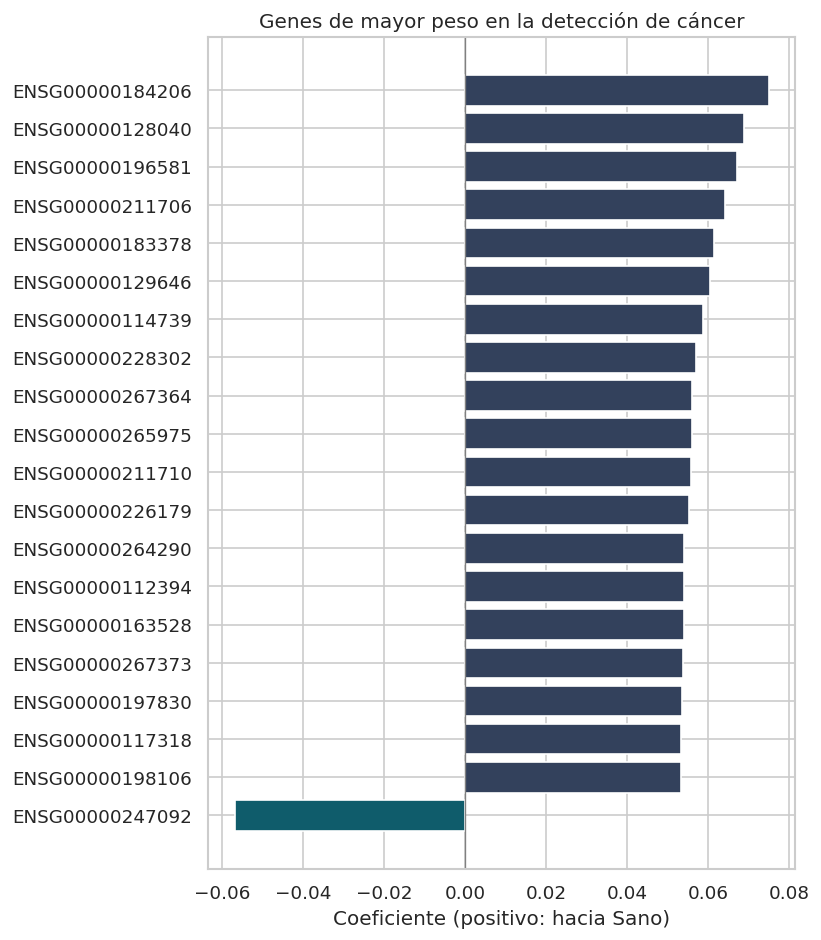

In [ ]:
grafico = firma_bin.head(20).sort_values("coeficiente")

# Coeficiente positivo: desplaza hacia la clase positiva del modelo (Sano)
colores = [azul_oscuro if c > 0 else verde_azulado for c in grafico["coeficiente"]]

plt.figure(figsize=(7, 8))
plt.barh(grafico["gen"], grafico["coeficiente"], color=colores)
plt.axvline(0, color="gray", lw=0.8)
plt.xlabel(f"Coeficiente (positivo: hacia {clase_positiva})")
plt.title("Genes de mayor peso en la detección de cáncer")
plt.tight_layout(); plt.show()

Las magnitudes obtenidas son pequeñas y muy parecidas entre sí. El coeficiente de mayor valor absoluto es 0,075 y los 50 primeros se reparten en un intervalo estrecho, sin que ninguno destaque sobre el resto. Este comportamiento es consecuencia de la penalización L2 seleccionada durante el ajuste, que reduce todos los coeficientes de forma proporcional en lugar de concentrar el peso en unas pocas variables. Por tanto, la predicción no se apoya en un número reducido de genes determinantes, sino en la contribución conjunta de muchos genes con aportaciones individuales pequeñas.

El reparto por sentido es desigual, ya que de los 50 genes de mayor peso 48 presentan coeficiente positivo, de forma que una expresión elevada de esos genes desplaza la predicción hacia el perfil de los individuos sanos, mientras que solo 2 apuntan en sentido contrario.

Se debe distinguir aquí entre importancia predictiva e interpretación biológica. Los coeficientes describen cómo el modelo combina las variables para clasificar, pero no constituyen una prueba de expresión diferencial ni permiten afirmar que exista una pérdida de expresión en las muestras tumorales. Sostener esa lectura exigiría un análisis específico de expresión diferencial, con estimación de tamaños de efecto y corrección por comparaciones múltiples, que queda fuera del alcance de este trabajo.

Como ya se ha comentado, en la tarea multiclase, cada tipo tumoral posee su propio conjunto de coeficientes. Los genes con mayor valor positivo para una categoría son aquellos cuya expresión elevada favorece su predicción, y forman la firma característica de ese tumor.

In [ ]:
n_por_clase = 15
firmas_por_clase = {}

for clase in coef_multi.columns:
    ordenados = coef_multi[clase].sort_values(ascending=False)
    firmas_por_clase[clase] = ordenados.head(n_por_clase)

print(f"Genes característicos de cada tipo tumoral "
      f"(los {n_por_clase} de mayor coeficiente positivo):\n")
for clase, genes in firmas_por_clase.items():
    print(f"{clase}")
    print("  " + ", ".join(genes.index))
    print(f"  coeficiente máximo: {genes.iloc[0]:.4f}\n")

Genes característicos de cada tipo tumoral (los 15 de mayor coeficiente positivo):

Breast
  ENSG00000188549, ENSG00000197989, ENSG00000105376, ENSG00000140386, ENSG00000132386, ENSG00000146834, ENSG00000239961, ENSG00000134109, ENSG00000171155, ENSG00000149930, ENSG00000161570, ENSG00000131379, ENSG00000067191, ENSG00000174946, ENSG00000106665
  coeficiente máximo: 0.3221

CRC
  ENSG00000104763, ENSG00000198625, ENSG00000136003, ENSG00000164180, ENSG00000188536, ENSG00000125898, ENSG00000270055, ENSG00000066777, ENSG00000169733, ENSG00000211964, ENSG00000002016, ENSG00000233355, ENSG00000086200, ENSG00000020577, ENSG00000167548
  coeficiente máximo: 0.2634

GBM
  ENSG00000196935, ENSG00000079215, ENSG00000145331, ENSG00000198585, ENSG00000188092, ENSG00000235770, ENSG00000146122, ENSG00000105255, ENSG00000138658, ENSG00000002016, ENSG00000247708, ENSG00000172469, ENSG00000198799, ENSG00000196634, ENSG00000066923
  coeficiente máximo: 0.3036

Hepatobiliary
  ENSG00000101104, ENSG000001

Genes compartidos entre las firmas de cada par de tipos tumorales:

               Breast  CRC  GBM  Hepatobiliary  Lung  Pancreas
Breast             15    0    0              0     0         1
CRC                 0   15    1              0     0         0
GBM                 0    1   15              0     0         0
Hepatobiliary       0    0    0             15     0         0
Lung                0    0    0              0    15         0
Pancreas            1    0    0              0     0        15


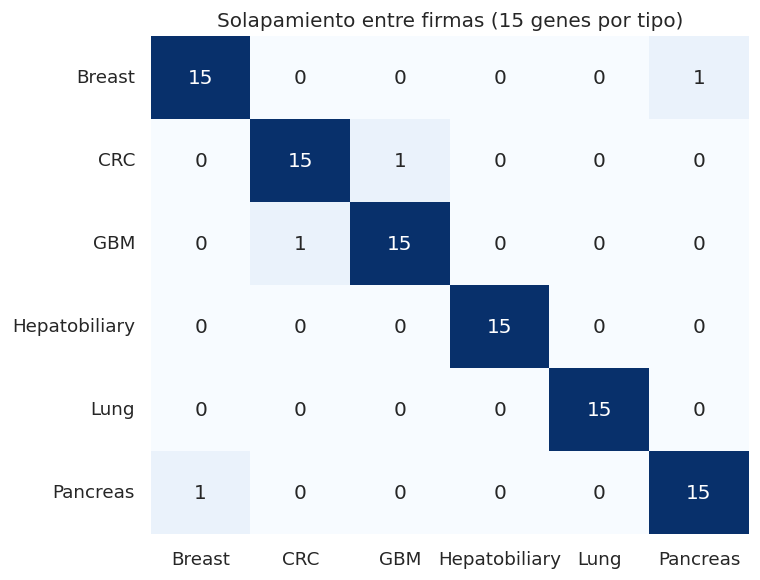

In [ ]:
conjuntos = {c: set(g.index) for c, g in firmas_por_clase.items()}
clases = list(conjuntos)
solape = pd.DataFrame(0, index=clases, columns=clases)
for a in clases:
    for b in clases:
        solape.loc[a, b] = len(conjuntos[a] & conjuntos[b])

print("Genes compartidos entre las firmas de cada par de tipos tumorales:\n")
print(solape.to_string())

plt.figure(figsize=(6.5, 5))
sns.heatmap(solape, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Solapamiento entre firmas ({n_por_clase} genes por tipo)")
plt.tight_layout(); plt.show()

El solapamiento entre firmas da información sobre la especificidad de los genes seleccionados. Un valor reducido fuera de la diagonal indica que cada tipo tumoral se apoya en genes propios, mientras que muchas coincidencias mostrarían que el modelo usa un mismo conjunto de variables para distinguir categorías distintas, lo que produciría pérdida de especificidad biológica.

Los coeficientes máximos varían según la categoría, desde 0,2257 en el carcinoma hepatobiliar hasta 0,3234 en el cáncer de páncreas. Estos valores son notablemente mayores que los de la firma binaria, cuyo máximo no alcanzaba 0,08, lo que indica que las firmas por tipo tumoral concentran más peso en genes concretos que la firma general de cáncer. Sin embargo, un mayor peso relativo no se traduce necesariamente en un mejor rendimiento predictivo, como muestra el grupo hepatobiliar, que a pesar de contar con coeficientes elevados apenas obtiene aciertos en la evaluación.

Las firmas de los 6 tipos tumorales casi no comparten genes entre sí. Solo se observan dos coincidencias, un gen común entre las firmas de mama y páncreas y otro entre las de colorrectal y glioblastoma, mientras que el resto de pares no comparte ninguno. Esto debe interpretarse con cuidado, ya que al seleccionar 15 genes de un conjunto de mil, la coincidencia esperable por azar entre dos categorías es menor a un gen, de manera que la escasez de solapamiento no es por sí sola una prueba de especificidad biológica.

Por ello, la ausencia casi total de genes compartidos indica que el modelo no recurre a un mismo grupo de variables para diferenciar las categorías, sino que cada tipo tumoral se apoya en un conjunto de genes propio.

### **Estabilidad de la firma**

Las firmas génicas obtenidas a partir de datos de expresión sufren un problema, que consiste en que pequeñas variaciones en las muestras de entrenamiento producen listas de genes muy distintas, aunque el rendimiento predictivo apenas cambie (Abeel et al., 2010). Esa inestabilidad compromete la interpretación biológica, que constituye uno de los objetivos de este trabajo.

La comprobación consiste en repetir la extracción con distintas particiones de los datos (las usadas en apartados anteriores) y contar con qué frecuencia aparece cada gen. Los que se seleccionan en bastantes particiones merecen mayor confianza que los que solo aparecen en repartos concretos.

In [ ]:
def firma_repetida_binaria(X_completo, y_completo, fila_modelo, k_genes,
                           n_genes=50, n_repeticiones=20):
    """Cuenta cuántas veces aparece cada gen entre los de mayor coeficiente de la firma binaria."""
    apariciones = {}
    for repeticion in range(n_repeticiones):
        semilla_rep = semilla + repeticion
        X_ent, _, y_ent, _ = train_test_split(
            X_completo, y_completo, test_size=0.20,
            stratify=y_completo, random_state=semilla_rep)

        flujo = construir_flujo(crear_modelo(fila_modelo["modelo"],
                                             fila_modelo["estrategia"]),
                                fila_modelo["estrategia"], k_genes)
        flujo.set_params(**fila_modelo["mejores_parametros"])
        flujo.fit(X_ent, y_ent)

        genes = np.array(X_completo.columns)[flujo.named_steps["filtrado"].mascara_]
        genes = genes[flujo.named_steps["seleccion"].get_support()]
        coef = flujo.named_steps["modelo"].coef_[0]
        # misma definición que la firma comunicada: los de mayor coeficiente
        mejores = genes[np.argsort(coef)[::-1][:n_genes]]
        for g in mejores:
            apariciones[g] = apariciones.get(g, 0) + 1

    return (pd.Series(apariciones, name="apariciones")
            .sort_values(ascending=False) / n_repeticiones)


def firma_repetida_multiclase(X_completo, y_completo, fila_modelo, k_genes,
                              n_por_clase=15, n_repeticiones=20):
    """Para cada tipo tumoral, cuenta cuántas veces aparece cada gen entre los de mayor coeficiente positivo de esa clase."""
    apariciones = {clase: {} for clase in coef_multi.columns}
    for repeticion in range(n_repeticiones):
        semilla_rep = semilla + repeticion
        X_ent, _, y_ent, _ = train_test_split(
            X_completo, y_completo, test_size=0.20,
            stratify=y_completo, random_state=semilla_rep)

        flujo = construir_flujo(crear_modelo(fila_modelo["modelo"],
                                             fila_modelo["estrategia"]),
                                fila_modelo["estrategia"], k_genes)
        flujo.set_params(**fila_modelo["mejores_parametros"])
        flujo.fit(X_ent, y_ent)

        genes = np.array(X_completo.columns)[flujo.named_steps["filtrado"].mascara_]
        genes = genes[flujo.named_steps["seleccion"].get_support()]
        coef = flujo.named_steps["modelo"].coef_
        for indice, clase in enumerate(flujo.classes_):
            mejores = genes[np.argsort(coef[indice])[::-1][:n_por_clase]]
            for g in mejores:
                apariciones[clase][g] = apariciones[clase].get(g, 0) + 1

    return {clase: (pd.Series(cuenta, name="apariciones")
                    .sort_values(ascending=False) / n_repeticiones)
            for clase, cuenta in apariciones.items()}


estabilidad_firma_bin = firma_repetida_binaria(X, y_binaria, mejor_bin, k_binaria)
estabilidad_firma_multi = firma_repetida_multiclase(X_multiclase, y_multiclase,
                                                    mejor_multi, k_multiclase)
print("Se ha comprobado la estabilidad de las firmas.")

Se ha comprobado la estabilidad de las firmas.


In [ ]:
# Tarea binaria
print("BINARIA")
print(f"  genes distintos seleccionados en alguna partición: {len(estabilidad_firma_bin)}")
print(f"  presentes en todas las particiones:        {(estabilidad_firma_bin == 1).sum()}")
print(f"  presentes en más del 80% de ellas:        {(estabilidad_firma_bin >= 0.8).sum()}")
print(f"  presentes en una sola partición:           {(estabilidad_firma_bin <= 0.05).sum()}")
estables_bin = [g for g in firma_bin["gen"] if estabilidad_firma_bin.get(g, 0) >= 0.8]
print(f"  de la firma comunicada, estables (≥80%):  {len(estables_bin)} de {len(firma_bin)}\n")

# Tarea multiclase, por clase
print("MULTICLASE (estabilidad por tipo tumoral)")
for clase in estabilidad_firma_multi:
    est = estabilidad_firma_multi[clase]
    firma_clase = set(firmas_por_clase[clase].index)
    estables = (est >= 0.8).sum()
    coincidentes = [g for g in firma_clase if est.get(g, 0) >= 0.8]
    print(f"  {clase:15s} genes distintos: {len(est):3d} | "
          f"estables (≥80%): {estables:2d} | "
          f"de la firma comunicada estables: {len(coincidentes):2d} de {len(firma_clase)}")

BINARIA
  genes distintos seleccionados en alguna partición: 201
  presentes en todas las particiones:        4
  presentes en más del 80% de ellas:        15
  presentes en una sola partición:           74
  de la firma comunicada, estables (≥80%):  13 de 50

MULTICLASE (estabilidad por tipo tumoral)
  Breast          genes distintos: 120 | estables (≥80%):  1 | de la firma comunicada estables:  1 de 15
  CRC             genes distintos: 127 | estables (≥80%):  2 | de la firma comunicada estables:  2 de 15
  GBM             genes distintos:  91 | estables (≥80%):  1 | de la firma comunicada estables:  1 de 15
  Hepatobiliary   genes distintos: 130 | estables (≥80%):  1 | de la firma comunicada estables:  1 de 15
  Lung            genes distintos: 105 | estables (≥80%):  0 | de la firma comunicada estables:  0 de 15
  Pancreas        genes distintos: 119 | estables (≥80%):  1 | de la firma comunicada estables:  1 de 15


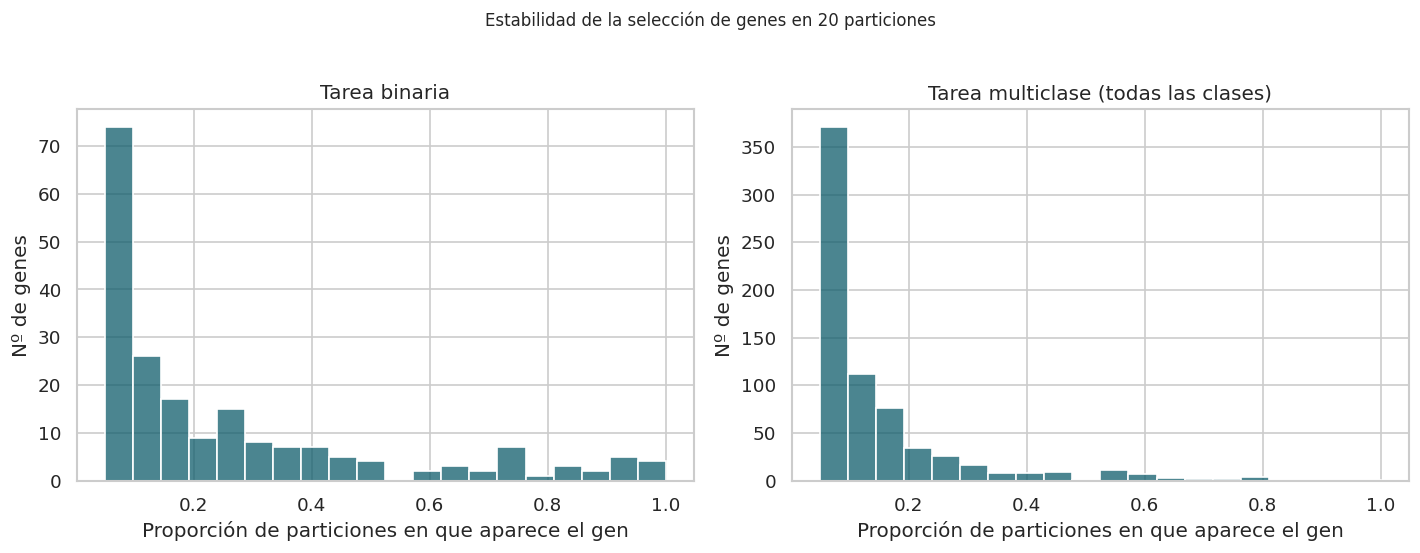

In [ ]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(estabilidad_firma_bin.values, bins=20, color=verde_azulado, ax=ejes[0])
ejes[0].set_title("Tarea binaria")
ejes[0].set_xlabel("Proporción de particiones en que aparece el gen")
ejes[0].set_ylabel("Nº de genes")

# En multiclase se agrupan las estabilidades de todas las clases
todas_multi = pd.concat(list(estabilidad_firma_multi.values()))
sns.histplot(todas_multi.values, bins=20, color=verde_azulado, ax=ejes[1])
ejes[1].set_title("Tarea multiclase (todas las clases)")
ejes[1].set_xlabel("Proporción de particiones en que aparece el gen")
ejes[1].set_ylabel("Nº de genes")

plt.suptitle("Estabilidad de la selección de genes en 20 particiones",
             y=1.02, fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
# Firma binaria restringida a los genes de selección reproducible
firma_estable_bin = estabilidad_firma_bin[estabilidad_firma_bin >= 0.8]
print(f"Firma estable - binaria: {len(firma_estable_bin)} genes")
print((firma_estable_bin * 100).round(0).astype(int).to_string(header=False))

# Firma multiclase estable, por tipo tumoral
print("\nFirma estable - multiclase (por tipo tumoral):")
for clase in estabilidad_firma_multi:
    est = estabilidad_firma_multi[clase]
    estable = est[est >= 0.8]
    print(f"\n  {clase}: {len(estable)} genes estables")
    if len(estable) > 0:
        print("   " + (estable * 100).round(0).astype(int).to_string(header=False).replace("\n", "\n   "))

Firma estable - binaria: 15 genes
ENSG00000184206    100
ENSG00000114739    100
ENSG00000226179    100
ENSG00000213160    100
ENSG00000183378     95
ENSG00000211710     95
ENSG00000112394     95
ENSG00000128596     95
ENSG00000117318     95
ENSG00000232021     90
ENSG00000267364     90
ENSG00000229807     85
ENSG00000197830     85
ENSG00000225113     85
ENSG00000106123     80

Firma estable - multiclase (por tipo tumoral):

  Breast: 1 genes estables
   ENSG00000146834    100

  CRC: 2 genes estables
   ENSG00000104763    80
   ENSG00000125898    80

  GBM: 1 genes estables
   ENSG00000146122    80

  Hepatobiliary: 1 genes estables
   ENSG00000183019    90

  Lung: 0 genes estables

  Pancreas: 1 genes estables
   ENSG00000169908    80


La selección de genes es considerablemente inestable en ambas tareas.

A lo largo de 20 particiones, la firma binaria selecciona un total de 201 genes distintos, pero su consistencia es baja. Solo 4 genes aparecen en todas las particiones, mientras que 74, casi el 40%, se seleccionan una única vez y no vuelven a salir.

De los 50 genes de la firma comunicada, apenas 13 alcanzan el umbral del 80% de apariciones. Los genes verdaderamente reproducibles son 15 en total, dos más de los que recoge esa firma, de manera que un par de ellos, a pesar de seleccionarse de forma fiable, no llegaron a aparecer en la partición original. Esa pequeña diferencia es una muestra más de la inestabilidad, porque ni siquiera la firma comunicada es capaz de contener a todos los genes que el modelo elige de manera consistente.

En la tarea multiclase, la estabilidad se ha medido con la misma definición con la que se comunica la firma, contando para cada tipo tumoral cuántas veces aparece cada gen entre los 15 de mayor coeficiente positivo de esa clase. El resultado confirma la fragilidad de las firmas por tumor: de los 15 genes comunicados por clase, apenas uno o dos superan el 80% de apariciones. El cáncer de mama conserva un gen estable, el colorrectal dos, el glioblastoma uno, el carcinoma hepatobiliar uno y el páncreas uno, mientras que el cáncer de pulmón no conserva ninguno.

El histograma refleja esa dispersión con claridad. La distribución se agrupa en el extremo izquierdo, de manera que la mayoría de los genes aparecen en menos de una quinta parte de las particiones, mientras que la zona de alta frecuencia queda casi vacía. Por tanto, la lista concreta de genes depende en gran medida del reparto de las muestras.

Aquí hay algo que puede llamar la atención, y es que el cáncer de pulmón, que es la clase con mejor rendimiento en la evaluación, no conserva ningún gen estable, mientras que clases con peor rendimiento sí retienen alguno. Esto muestra que la estabilidad de la firma y la capacidad predictiva son propiedades independientes, y que un buen rendimiento no garantiza una firma reproducible.

Este resultado obtenido coincide con lo descrito por Abeel et al. (2010), según el cual las firmas génicas obtenidas de datos de expresión varían notablemente ante pequeños cambios en las muestras de entrenamiento, sin que el rendimiento predictivo se vea afectado en la misma medida. La explicación está en la estructura de los datos: con miles de genes correlacionados entre sí y menos de 300 muestras, existen muchos subconjuntos capaces de conseguir predicciones equivalentes, de forma que el que se selecciona depende de detalles del conjunto de entrenamiento.

La consecuencia de esto es que la interpretación biológica debe limitarse a los genes de selección reproducible. En la tarea binaria, 15 genes superan el 80% de apariciones, liderados por ENSG00000184206, ENSG00000114739, ENSG00000226179 y ENSG00000213160, presentes en las 20 particiones. En la multiclase, el conjunto reproducible se reduce a un gen por tipo tumoral en casi todas las clases: ENSG00000146834 en el cáncer de mama, presente en las 20 particiones; ENSG00000104763 y ENSG00000125898 en el colorrectal; ENSG00000146122 en el glioblastoma; ENSG00000183019 en el carcinoma hepatobiliar; y ENSG00000169908 en el páncreas. Solo estos genes, por mantenerse a lo largo de particiones distintas, ofrecen una base mínimamente fiable para una lectura biológica.

### **Interpretación biológica de los genes estables**

In [ ]:
# Signo del coeficiente de los 15 genes estables de la firma binaria
genes_estables_bin = estabilidad_firma_bin[estabilidad_firma_bin >= 0.8].index

signo_estables = coef_bin[coef_bin["gen"].isin(genes_estables_bin)].copy()
signo_estables["sentido"] = np.where(signo_estables["coeficiente"] > 0,
                                     "positivo (hacia Sano)",
                                     "negativo (hacia Cáncer)")
signo_estables = signo_estables.sort_values("coeficiente", ascending=False)

print(f"Genes estables de la firma binaria: {len(signo_estables)}")
print(f"  con coeficiente positivo (hacia Sano):  {(signo_estables['coeficiente'] > 0).sum()}")
print(f"  con coeficiente negativo (hacia Cáncer): {(signo_estables['coeficiente'] < 0).sum()}\n")
print(signo_estables.to_string(index=False))

Genes estables de la firma binaria: 15
  con coeficiente positivo (hacia Sano):  15
  con coeficiente negativo (hacia Cáncer): 0

            gen  coeficiente  magnitud               sentido
ENSG00000184206     0.074979  0.074979 positivo (hacia Sano)
ENSG00000183378     0.061528  0.061528 positivo (hacia Sano)
ENSG00000114739     0.058875  0.058875 positivo (hacia Sano)
ENSG00000267364     0.056002  0.056002 positivo (hacia Sano)
ENSG00000211710     0.055731  0.055731 positivo (hacia Sano)
ENSG00000226179     0.055281  0.055281 positivo (hacia Sano)
ENSG00000112394     0.054075  0.054075 positivo (hacia Sano)
ENSG00000197830     0.053688  0.053688 positivo (hacia Sano)
ENSG00000117318     0.053425  0.053425 positivo (hacia Sano)
ENSG00000213160     0.051964  0.051964 positivo (hacia Sano)
ENSG00000232021     0.051047  0.051047 positivo (hacia Sano)
ENSG00000229807     0.048827  0.048827 positivo (hacia Sano)
ENSG00000128596     0.048816  0.048816 positivo (hacia Sano)
ENSG00000225113 

La identificación de los genes seleccionados de forma reproducible permite una lectura biológica, siempre con precaución debido el tamaño reducido de la muestra.

En la tarea binaria, los genes estables corresponden a coeficientes positivos, es decir, a genes cuya expresión elevada desplaza la predicción hacia la ausencia de tumor, sin que ello constituya una prueba de expresión diferencial. Los cuatro presentes en las 20 particiones son GOLGA6L4 (una proteína del aparato de Golgi), ACVR2B (un receptor de la activina), LINC00685 (un ARN largo no codificante de proteínas) y KLHL23 (un adaptador del sistema de degradación de proteínas). Ninguno de ellos es un marcador oncológico clásico, lo que muestra que la reproducibilidad estadística no implica por sí sola relevancia biológica directa.

En las firmas por tipo tumoral, donde los genes seleccionados corresponden a coeficientes positivos de cada clase y representan por tanto genes cuya expresión aumenta en ese tumor, los resultados cambian más (algunos cuentan con respaldo en la literatura oncológica).
- En el cáncer de páncreas, el gen reproducible es TM4SF1, una tetraspanina de superficie celular implicada en la proliferación, la invasión y la metástasis, descrita en varios tipos tumorales (Tang et al., 2020; Huang et al., 2016).
- En el cáncer colorrectal aparecen ASAH1, una ceramidasa ácida sobreexpresada en múltiples cánceres y asociada a la progresión tumoral, y FAM110A, un factor implicado en la organización del huso mitótico durante la división celular.
- En el glioblastoma, el gen estable es DAAM2, un activador de la morfogénesis, con un papel razonable aunque menos directo.

Otros genes estables no presentan una conexión oncológica clara. En el cáncer de mama es MEPCE, un regulador de la transcripción, y en el carcinoma hepatobiliar es MCEMP1, una proteína ligada a los mastocitos y a la respuesta inmunitaria, sin señal tumoral establecida.

Esto resume el alcance y los límites de la interpretación biológica de las firmas.

Que algunos genes reproducibles coincidan con marcadores implicados en el cáncer, como TM4SF1 o ASAH1, sugiere que el modelo capta parte de una señal biológica real. Sin embargo, la presencia de genes sin relación oncológica clara entre los más estables, junto con la escasez general de genes reproducibles observada en el apartado anterior, obliga a tratar estas firmas como hipótesis exploratorias y no como conjuntos de biomarcadores validados. Una confirmación precisa necesitaría cohortes independientes y validación experimental, fuera del alcance de este trabajo.

Esto se puede resumir en la siguiente tabla:

In [ ]:
info_genes = [
    {"gen": "ENSG00000184206", "símbolo": "GOLGA6L4", "tarea": "Binaria",
     "función": "Proteína del aparato de Golgi",
     "vínculo con el cáncer": "Sin evidencia conocida"},
    {"gen": "ENSG00000114739", "símbolo": "ACVR2B", "tarea": "Binaria",
     "función": "Receptor de la vía activina/TGF-β",
     "vínculo con el cáncer": "Pertenece a una vía implicada en cáncer, sin ser marcador tumoral establecido"},
    {"gen": "ENSG00000226179", "símbolo": "LINC00685", "tarea": "Binaria",
     "función": "ARN largo no codificante",
     "vínculo con el cáncer": "Sin evidencia conocida"},
    {"gen": "ENSG00000213160", "símbolo": "KLHL23", "tarea": "Binaria",
     "función": "Adaptador de ubiquitina ligasa Cul3",
     "vínculo con el cáncer": "Sin evidencia conocida"},
    {"gen": "ENSG00000146834", "símbolo": "MEPCE", "tarea": "Mama",
     "función": "Regulador de la transcripción (7SK RNP)",
     "vínculo con el cáncer": "Sin evidencia conocida"},
    {"gen": "ENSG00000104763", "símbolo": "ASAH1", "tarea": "Colorrectal",
     "función": "Ceramidasa ácida",
     "vínculo con el cáncer": "Directo: sobreexpresado en varios tumores y asociado a la progresión"},
    {"gen": "ENSG00000125898", "símbolo": "FAM110A", "tarea": "Colorrectal",
     "función": "Organización del huso mitótico",
     "vínculo con el cáncer": "Participa en la división celular, sin ser marcador tumoral establecido"},
    {"gen": "ENSG00000146122", "símbolo": "DAAM2", "tarea": "Glioblastoma",
     "función": "Activador de morfogénesis (vía Wnt)",
     "vínculo con el cáncer": "Pertenece a una vía implicada en cáncer, sin ser marcador tumoral establecido"},
    {"gen": "ENSG00000183019", "símbolo": "MCEMP1", "tarea": "Hepatobiliar",
     "función": "Proteína de mastocitos (respuesta inmune)",
     "vínculo con el cáncer": "Sin evidencia conocida"},
    {"gen": "ENSG00000169908", "símbolo": "TM4SF1", "tarea": "Páncreas",
     "función": "Tetraspanina de superficie celular",
     "vínculo con el cáncer": "Directo: promueve proliferación, invasión y metástasis (vía Wnt/β-catenina)"},
]

tabla_genes = pd.DataFrame(info_genes)

# Biotipo según Ensembl (todos codifican proteína salvo LINC00685)
biotipos = {"ENSG00000226179": "lncRNA"}
tabla_genes["biotipo"] = tabla_genes["gen"].map(biotipos).fillna("protein_coding")

# Frecuencia de selección a lo largo de las 20 particiones
equivalencia = {"Mama": "Breast", "Colorrectal": "CRC", "Glioblastoma": "GBM",
                "Hepatobiliar": "Hepatobiliary", "Páncreas": "Pancreas"}

def buscar_estabilidad(fila):
    if fila["tarea"] == "Binaria":
        return estabilidad_firma_bin.get(fila["gen"], np.nan)
    return estabilidad_firma_multi[equivalencia[fila["tarea"]]].get(fila["gen"], np.nan)

tabla_genes["apariciones (%)"] = (tabla_genes.apply(buscar_estabilidad, axis=1) * 100).round(0)

# Coeficiente y dirección, tomados del modelo correspondiente
def coef_y_sentido(fila):
    if fila["tarea"] == "Binaria":
        valores = coef_bin.loc[coef_bin["gen"] == fila["gen"], "coeficiente"]
        valor = valores.iloc[0] if len(valores) else np.nan
        sentido = "hacia Sano" if valor > 0 else "hacia Cáncer"
    else:
        clase = equivalencia[fila["tarea"]]
        valor = (coef_multi.loc[fila["gen"], clase]
                 if fila["gen"] in coef_multi.index else np.nan)
        sentido = f"hacia {clase}" if valor > 0 else f"en contra de {clase}"
    return pd.Series({"coeficiente": round(valor, 4), "dirección": sentido})

tabla_genes[["coeficiente", "dirección"]] = tabla_genes.apply(coef_y_sentido, axis=1)

tabla_genes = tabla_genes[["símbolo", "gen", "biotipo", "tarea", "función",
                           "coeficiente", "dirección", "vínculo con el cáncer",
                           "apariciones (%)"]]
print(tabla_genes.to_string(index=False))

  símbolo             gen        biotipo        tarea                                   función  coeficiente           dirección                                                         vínculo con el cáncer  apariciones (%)
 GOLGA6L4 ENSG00000184206 protein_coding      Binaria             Proteína del aparato de Golgi       0.0750          hacia Sano                                                        Sin evidencia conocida            100.0
   ACVR2B ENSG00000114739 protein_coding      Binaria         Receptor de la vía activina/TGF-β       0.0589          hacia Sano Pertenece a una vía implicada en cáncer, sin ser marcador tumoral establecido            100.0
LINC00685 ENSG00000226179         lncRNA      Binaria                  ARN largo no codificante       0.0553          hacia Sano                                                        Sin evidencia conocida            100.0
   KLHL23 ENSG00000213160 protein_coding      Binaria       Adaptador de ubiquitina ligasa Cul3       0.

### **Contraste con la variación de origen técnico**

En la preparación de los datos apareció un efecto de lote. Las muestras de Batch05 y Batch06 se separaban con claridad del resto, y se comprobó que corresponden a la cohorte aportada por el Massachusetts General Hospital, mientras que las demás proceden del centro de Ámsterdam. Ese grupo, compuesto sobre todo por casos de pulmón y de mama, no incluye ningún control sano, ni glioblastomas, ni casos de páncreas, de modo que saber de qué lote viene una muestra ya informa sobre qué es.

El modelo podría, por tanto, estar reconociendo el hospital de procedencia en lugar del perfil biológico, y acertando por el motivo equivocado.

La forma de comprobarlo es contrastar dos listas de genes. Por un lado, los que producen las predicciones del modelo, que son los de la firma. Por otro lado, los que mejor separan unas tandas de otras, que recogen la variación técnica. Si ambas listas se solapan, la sospecha sería cierta. Si los genes de la firma están entre los que menos distinguen las tandas, se puede afirmar que el modelo se apoya en biología.

In [ ]:
lote_por_columna = dict(zip(correspondencia["columna_expr"], correspondencia["lote"]))

# Se reconstruye la matriz normalizada tal como la ve el modelo binario, aplicando el filtrado y la normalización del propio flujo
X_filtrada = flujo_bin.named_steps["filtrado"].transform(X_ent_bin.values)
X_norm_modelo = flujo_bin.named_steps["escalado"].transform(X_filtrada)
genes_filtrados = np.array(X_ent_bin.columns)[flujo_bin.named_steps["filtrado"].mascara_]
X_norm_modelo = pd.DataFrame(X_norm_modelo, index=X_ent_bin.index,
                             columns=genes_filtrados)

# Lote de cada muestra de entrenamiento
lotes_ent = pd.Series({m: lote_por_columna.get(m) for m in X_ent_bin.index}).dropna()

# Solo se conservan las muestras de cáncer: los controles sanos no pueden emparejarse de forma fiable entre los dos archivos, y además su procedencia va ligada a la enfermedad, lo que mezclaría lo técnico con lo biológico
muestras_cancer = [m for m in lotes_ent.index if y_ent_bin.loc[m] != "Sano"]
lotes_cancer = lotes_ent.loc[muestras_cancer]

print(f"Muestras de entrenamiento con lote identificado (solo cáncer): "
      f"{len(lotes_cancer)} de {len(X_ent_bin)}")
print(lotes_cancer.value_counts().to_string(), "\n")

# Genes que mejor separan los lotes entre sí
X_lote = X_norm_modelo.loc[lotes_cancer.index]
puntuaciones, _ = f_classif(X_lote.values, lotes_cancer.values)
puntuaciones = np.nan_to_num(puntuaciones, nan=0.0)

genes_lote = pd.Series(puntuaciones, index=X_lote.columns).sort_values(ascending=False)
top_lote = set(genes_lote.head(500).index)
print("Genes más asociados al lote de procesamiento: se retienen los 500 primeros")

Muestras de entrenamiento con lote identificado (solo cáncer): 183 de 227
Batch03    76
Batch04    46
Batch02    30
Batch06    21
Batch05     8
Batch01     2 

Genes más asociados al lote de procesamiento: se retienen los 500 primeros


Con los genes ordenados según cuánto distinguen unas tandas de otras, se toman los 500 primeros y se mira cuántos de ellos aparecen en cada firma.

In [ ]:
firma_binaria_genes = set(firma_bin["gen"])
firma_multi_genes = set().union(*[set(g.index) for g in firmas_por_clase.values()])

for nombre, firma in [("binaria", firma_binaria_genes),
                      ("multiclase", firma_multi_genes)]:
    comunes = firma & top_lote
    esperado = len(firma) * len(top_lote) / len(genes_lote)
    print(f"Firma {nombre}: {len(firma)} genes")
    print(f"  coincidentes con los 500 más asociados al lote: {len(comunes)}")
    print(f"  coincidencias esperables por azar: {esperado:.1f}")
    if comunes:
        print(f"  genes coincidentes: {sorted(comunes)}")
    print()

Firma binaria: 50 genes
  coincidentes con los 500 más asociados al lote: 0
  coincidencias esperables por azar: 1.9

Firma multiclase: 88 genes
  coincidentes con los 500 más asociados al lote: 6
  coincidencias esperables por azar: 3.4
  genes coincidentes: ['ENSG00000100614', 'ENSG00000103249', 'ENSG00000106665', 'ENSG00000109062', 'ENSG00000149930', 'ENSG00000169733']



Ninguno de los 50 genes de la firma binaria coincide con los 500 más asociados al lote (se esperaban 1,9 coincidencias por azar). En la firma multiclase aparecen 6 de sus 88 genes, algo por encima de las 3,4 esperables. Sin embargo, este primer recuento solo mira la cabecera de la lista, por lo que, resulta más informativo comprobar en qué posición del ranking completo se sitúan los genes de cada firma, ya que eso muestra si, además de evitar los más contaminados, tienen alguna preferencia por los que menos distinguen unas tandas de otras.

In [ ]:
rango_lote = pd.Series(range(1, len(genes_lote) + 1), index=genes_lote.index)
total = len(rango_lote)

# Genes estables de la multiclase: unión de los estables de cada clase
genes_estables_multi = set()
for clase in estabilidad_firma_multi:
    est = estabilidad_firma_multi[clase]
    genes_estables_multi |= set(est[est >= 0.8].index)

print(f"Posición de los genes de cada firma en el ranking de asociación con el lote")
print(f"(la posición 1 corresponde al gen más asociado, de {total:,} (este valor es el número de genes seleccionado final con expresión detectable))\n")

for nombre, firma in [("Firma binaria", firma_binaria_genes),
                      ("Firma multiclase", firma_multi_genes),
                      ("Firma estable binaria", set(firma_estable_bin.index)),
                      ("Firma estable multiclase", genes_estables_multi)]:
    posiciones = [rango_lote[g] for g in firma if g in rango_lote.index]
    if not posiciones:
        print(f"{nombre}: ningún gen con posición conocida\n")
        continue
    en_primera_mitad = sum(1 for p in posiciones if p <= total / 2)
    print(f"{nombre}")
    print(f"  genes con posición conocida: {len(posiciones)} de {len(firma)}")
    print(f"  mediana: {np.median(posiciones):,.0f}")
    print(f"  rango:   {min(posiciones):,.0f} – {max(posiciones):,.0f}")
    print(f"  en la primera mitad del ranking: {en_primera_mitad} de {len(posiciones)} "
          f"(unos {len(posiciones)//2} si se repartiesen al azar)\n")

Posición de los genes de cada firma en el ranking de asociación con el lote
(la posición 1 corresponde al gen más asociado, de 12,844 (este valor es el número de genes seleccionado final con expresión detectable))

Firma binaria
  genes con posición conocida: 50 de 50
  mediana: 10,474
  rango:   2,430 – 12,815
  en la primera mitad del ranking: 4 de 50 (unos 25 si se repartiesen al azar)

Firma multiclase
  genes con posición conocida: 88 de 88
  mediana: 6,460
  rango:   163 – 12,830
  en la primera mitad del ranking: 44 de 88 (unos 44 si se repartiesen al azar)

Firma estable binaria
  genes con posición conocida: 15 de 15
  mediana: 10,437
  rango:   6,591 – 12,223
  en la primera mitad del ranking: 0 de 15 (unos 7 si se repartiesen al azar)

Firma estable multiclase
  genes con posición conocida: 6 de 6
  mediana: 6,056
  rango:   734 – 10,261
  en la primera mitad del ranking: 3 de 6 (unos 3 si se repartiesen al azar)



Los resultados son muy diferentes según la tarea, por lo que conviene analizarlos por separado.

En la detección de cáncer, los genes del modelo evitan los más relacionados con el lote y se agrupan en la cola de la lista, entre los que menos distinguen unas tandas de otras. El gen que ocupa la posición central de la firma es el 10474 de 12844, y solo 4 de los 50 caen en la mitad más relacionada, cuando el azar situaría allí a unos 25. Incluso el más asociado al lote de toda la firma ocupa la posición 2430, lejos de la cabecera. Los 15 genes que el modelo selecciona de forma reproducible refuerzan esta conclusión, con una posición central de 10437 y ninguno en la mitad más afectada, frente a los 7 u 8 esperables por azar. Por tanto, son los genes que menos tienen que ver con el hospital de procedencia.

En la clasificación del tipo de tumor ocurre lo contrario. La posición central de sus genes es la 6460, prácticamente el medio de la lista, y 44 de sus 88 caen en la mitad más relacionada, exactamente los que daría el azar. Es decir, la firma multiclase se reparte como cualquier conjunto de genes elegido sin criterio respecto al lote. Solo evita los casos más extremos, con 6 coincidencias entre los 500 primeros frente a las 3,4 esperables, pero sin mostrar ninguna preferencia por los genes limpios. Los 6 genes estables son demasiado pocos para extraer conclusiones de su reparto, con una posición central intermedia.

La conclusión depende, por tanto, de la tarea. En la detección de cáncer no se encontró evidencia de una asociación fuerte entre los genes principales del modelo y el lote conocido, lo que es positivo, aunque no permite descartar por completo la existencia de confusión técnica: el lote solo pudo identificarse de forma completamente fiable en una parte de las muestras tumorales de entrenamiento y los controles sanos quedaron fuera de la comprobación. En la clasificación del tipo de tumor ni siquiera se obtiene ese indicio favorable. Este comportamiento encaja con que la cohorte de Boston aportó sobre todo casos de pulmón y de mama, de manera que la procedencia coincide con la enfermedad justo en la tarea que trata de distinguir unos tumores de otros, y no puede descartarse que parte del acierto provenga de reconocer el origen de la muestra. Así se recoge entre las limitaciones del trabajo.

*Nota:* Vale la pena aclarar qué muestras se usaron para esta comprobación. El lote solo pudo identificarse en 183 de las 227 muestras de entrenamiento (todas de pacientes con cáncer), ya que los controles sanos no coinciden de forma fiable entre ambos archivos. Excluirlos es la mejor opción, ya que como el origen de la muestra está vinculado a la enfermedad, incluir los controles al buscar los genes del lote mezclaría los factores técnicos con los biológicos, quitándole precisión a la comparación.

Una comprobación más exigente habría consistido en entrenar con las muestras de un centro y evaluar en las del otro. Ese diseño no resulta viable aquí, ya que la cohorte de Boston no incluye ningún control sano, lo que impide plantear la tarea binaria, ni ningún caso de glioblastoma o de páncreas, lo que reduciría la tarea multiclase a cuatro categorías con muy pocas muestras. Solo el cáncer de pulmón y el de mama están representados en ambos centros con un número considerable de casos, insuficiente para sostener una evaluación separada. Esta imposibilidad se debe a una limitación del conjunto de datos y refuerza la necesidad de cohortes multicéntricas equilibradas.

In [ ]:
transcurrido = time.time() - inicio_ejecucion
horas, resto = divmod(int(transcurrido), 3600)
minutos, segundos = divmod(resto, 60)
print(f"Tiempo total de ejecución: {horas} h {minutos} min {segundos} s")

Tiempo total de ejecución: 0 h 41 min 2 s
